In [1]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#       jupytext_version: 1.19.1

#     language: python
#     name: python3
# ---

# Phần 2: Tiền xử lý dữ liệu dạng bảng – IEEE-CIS Fraud Detection
#
Dataset: IEEE-CIS Fraud Detection
- `train_transaction.csv`, `train_identity.csv`
- `test_transaction.csv`, `test_identity.csv`
- Bài toán phân loại nhị phân: dự đoán `isFraud`
- Dữ liệu có cả thuộc tính số và phân loại, nhiều giá trị thiếu, mất cân bằng lớp nghiêm trọng.

## 0. Cài đặt thư viện cần thiết

Nếu thiếu thư viện, cài thủ công:

```bash
pip install missingno pyampute category_encoders umap-learn imbalanced-learn scikit-learn scipy statsmodels
```

In [2]:
from scipy.stats import friedmanchisquare, wilcoxon
import json
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report)
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import f_classif, chi2, mutual_info_classif, RFE
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
import category_encoders as ce
from scipy.stats import levene
from sklearn.preprocessing import (MinMaxScaler, StandardScaler,
                                   RobustScaler, QuantileTransformer)
from scipy.stats import ks_2samp
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import mutual_info_classif
import missingno as msno
from scipy import stats
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
import os

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 80
pd.options.display.max_rows = 60
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
SEED = 42
np.random.seed(SEED)

## 0. Load & merge dữ liệu

In [3]:
# ── Đường dẫn dữ liệu ──────────────────────────────────────────────────────

try:
    _SOURCE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    _SOURCE_DIR = Path.cwd().parent

DATA_DIR   = str(_SOURCE_DIR / 'data' / 'raw' / 'tabular')
OUTPUT_DIR = str(_SOURCE_DIR / 'data' / 'processed' / 'tabular')

# Fallback: nếu đường dẫn gốc không tồn tại, tìm thư mục chứa train_transaction.csv
if not os.path.exists(os.path.join(DATA_DIR, 'train_transaction.csv')):
    _candidates = [
        _SOURCE_DIR / 'data' / 'tabular',
        _SOURCE_DIR.parent / 'data' / 'tabular',
        _SOURCE_DIR.parent / 'data' / 'raw' / 'tabular',
    ]
    for _c in _candidates:
        if (_c / 'train_transaction.csv').exists():
            DATA_DIR = str(_c)
            print(f"[INFO] Dùng đường dẫn dự phòng: {DATA_DIR}")
            break
    else:
        raise FileNotFoundError(
            f"Không tìm thấy train_transaction.csv. "
            f"Đã thử các đường dẫn: {[str(c) for c in _candidates]}"
        )

os.makedirs(OUTPUT_DIR, exist_ok=True)
FIGURES_DIR = str(_SOURCE_DIR / 'outputs' / 'tabular')
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"DATA_DIR    = {DATA_DIR}")
print(f"OUTPUT_DIR  = {OUTPUT_DIR}")
print(f"FIGURES_DIR = {FIGURES_DIR}")

print("Đang tải dữ liệu...")
train_transaction = pd.read_csv(os.path.join(DATA_DIR, 'train_transaction.csv'))
train_identity    = pd.read_csv(os.path.join(DATA_DIR, 'train_identity.csv'))
test_transaction  = pd.read_csv(os.path.join(DATA_DIR, 'test_transaction.csv'))
test_identity     = pd.read_csv(os.path.join(DATA_DIR, 'test_identity.csv'))

# Merge transaction + identity theo TransactionID (left join)
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
test  = pd.merge(test_transaction,  test_identity,  on='TransactionID', how='left')

del train_transaction, train_identity, test_transaction, test_identity
gc.collect()

print(f"Train: {train.shape[0]:,} dòng x {train.shape[1]} cột")
print(f"Test : {test.shape[0]:,} dòng x {test.shape[1]} cột")

DATA_DIR    = d:\DataMining\DataPreprocessing\Source\data\raw\tabular
OUTPUT_DIR  = d:\DataMining\DataPreprocessing\Source\data\processed\tabular
FIGURES_DIR = d:\DataMining\DataPreprocessing\Source\outputs\tabular
Đang tải dữ liệu...
Train: 590,540 dòng x 434 cột
Test : 506,691 dòng x 433 cột


In [4]:
# ── Giảm sử dụng bộ nhớ (downcast kiểu dữ liệu) ──────────────────────────────
def reduce_mem_usage(df, verbose=True):
    """Giảm bộ nhớ bằng cách chuyển kiểu dtype nhỏ hơn."""
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                for dtype in [np.int8, np.int16, np.int32, np.int64]:
                    if c_min > np.iinfo(dtype).min and c_max < np.iinfo(dtype).max:
                        df[col] = df[col].astype(dtype)
                        break
            else:
                if (c_min > np.finfo(np.float32).min and
                        c_max < np.finfo(np.float32).max):
                    df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"  Bộ nhớ giảm từ {start_mem:.1f} MB -> {end_mem:.1f} MB "
              f"({100*(start_mem-end_mem)/start_mem:.1f}%)")
    return df


train = reduce_mem_usage(train)
test = reduce_mem_usage(test)
gc.collect()

  Bộ nhớ giảm từ 2514.0 MB -> 1603.3 MB (36.2%)
  Bộ nhớ giảm từ 2164.1 MB -> 1386.1 MB (35.9%)


0

#### Shape, dtypes, memory usage

In [5]:
print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}\n")

# Phân loại dtype
dtype_summary = train.dtypes.value_counts()
print("Kiểu dữ liệu:")
print(dtype_summary.to_string())

mem_mb = train.memory_usage(deep=True).sum() / 1024**2
print(f"\nBộ nhớ train: {mem_mb:.1f} MB")

Train shape : (590540, 434)
Test  shape : (506691, 433)

Kiểu dữ liệu:
float32    399
object      31
int32        2
int8         1
int16        1

Bộ nhớ train: 1603.3 MB


#### Phân nhóm cột theo ý nghĩa nghiệp vụ
#
Dataset IEEE-CIS gồm ~400 cột được Vesta Corporation đặt tên có chủ đích.
Ta có thể chia toàn bộ thuộc tính thành 9 nhóm dựa theo ý nghĩa nghiệp vụ:
#
| Nhóm | Cột đại diện | Ý nghĩa |
|---|---|---|
| **Transaction** | `TransactionDT`, `TransactionAmt`, `ProductCD` | Thông tin cơ bản của giao dịch: thời điểm, giá trị, loại sản phẩm |
| **Card** | `card1`–`card6` | Thông tin thẻ thanh toán: ID, mạng thẻ, loại thẻ, ngân hàng phát hành |
| **Address/Dist** | `addr1`, `addr2`, `dist1`, `dist2` | Địa chỉ thanh toán và khoảng cách địa lý liên quan |
| **Email** | `P_emaildomain`, `R_emaildomain` | Domain email của người mua (P) và người nhận (R) |
| **C (count)** | `C1`–`C14` | Đếm các sự kiện liên quan đến thẻ/địa chỉ (Vesta không công bố chi tiết) |
| **D (timedelta)** | `D1`–`D15` | Khoảng thời gian giữa các sự kiện (ngày từ giao dịch trước, từ khi mở thẻ, v.v.) |
| **M (match)** | `M1`–`M9` | Biến nhị phân "match": khớp tên, địa chỉ, v.v. giữa các bản ghi |
| **V (Vesta)** | `V1`–`V339` | Đặc trưng kỹ thuật do Vesta tính toán nội bộ (enriched features) |
| **Identity** | `id_01`–`id_38`, `DeviceType`, `DeviceInfo` | Thông tin thiết bị và danh tính: OS, trình duyệt, loại thiết bị |
#
### Tại sao phân nhóm như vậy?
#
1. Transaction: Ba cột thuần giao dịch tạo thành "xương sống": thời điểm (`TransactionDT`)
và giá trị (`TransactionAmt`) là hai đặc trưng quan trọng nhất; `ProductCD` cho biết loại hàng hóa.
Phân nhóm riêng để dễ so sánh phân phối theo lớp (Fraud vs. Normal).
#
2. Card: Sáu cột `card1`-`card6` đều mô tả thẻ thanh toán từ các góc độ khác nhau
(ID thẻ, mạng Visa/MC, thẻ debit/credit, ngân hàng phát hành, quốc gia).
Nhóm lại vì chúng cùng xác định danh tính của phương tiện thanh toán.
#
3. Address/Dist: Hai cột địa chỉ (`addr1`, `addr2`) và hai khoảng cách (`dist1`, `dist2`)
đều liên quan đến vị trí địa lý. Gian lận thường xảy ra khi địa chỉ giao hàng khác xa
địa chỉ thẻ, nhóm lại để phân tích tương quan không gian.
#
4. Email: Hai domain email (purchaser vs. recipient) phản ánh hành vi tạo tài khoản.
Khi P_email != R_email hoặc dùng domain bất thường là tín hiệu gian lận. Nhóm riêng để
tạo feature `email_match` và phân tích fraud rate theo domain.
#
5. C (count): Theo tài liệu Vesta, C1-C14 là các biến đếm (count) về lịch sử
giao dịch liên quan đến thẻ/địa chỉ trong quá khứ. Giá trị lớn = thẻ/địa chỉ đã dùng nhiều.
Nhóm lại vì tất cả cùng kiểu "lịch sử tần suất".
#
6. D (timedelta): D1-D15 là khoảng thời gian (ngày) giữa các sự kiện:
D1 = số ngày từ giao dịch trước trên cùng thẻ, D4/D5 = từ khi mở thẻ, v.v.
Nhóm lại vì chúng đều đo temporal gap và có cấu trúc missing khác nhau theo từng cột.
#
7. M (match): M1-M9 là cờ khớp (match flag) dạng T/F/NaN:
M1 = khớp tên thẻ, M2 = khớp địa chỉ. Nhóm lại vì tất cả đều là biến phân loại nhị phân
và cần xử lý encoding đồng nhất.
#
8. V (Vesta): 339 cột V1-V339 là đặc trưng bí mật do Vesta tính toán. Chúng có cấu trúc
missing rõ ràng theo 11 sub-group (G1-G11), nhóm lại để phân tích missing pattern
và giảm chiều bằng PCA/feature selection theo sub-group.
#
9. Identity: Toàn bộ cột `id_` và `DeviceType`/`DeviceInfo` đến từ bảng `train_identity`
(left-join, ~40% transaction không có identity record). Nhóm riêng để phân tích tác động
của "có/không có thiết bị" lên fraud rate và xây dựng feature `has_identity`.

In [6]:
# ── Định nghĩa 9 nhóm cột và in ra thông tin tổng quát ─────────────────────
groups = {
    'Transaction': ['TransactionDT', 'TransactionAmt', 'ProductCD'],
    'Card': [f'card{i}' for i in range(1, 7)],
    'Address/Dist': ['addr1', 'addr2', 'dist1', 'dist2'],
    'Email': ['P_emaildomain', 'R_emaildomain'],
    'C (count)': [f'C{i}' for i in range(1, 15)],
    'D (timedelta)': [f'D{i}' for i in range(1, 16)],
    'M (match)': [f'M{i}' for i in range(1, 10)],
    'V (Vesta)': [c for c in train.columns if c.startswith('V')],
    'Identity': [c for c in train.columns if c.startswith('id_') or c in ('DeviceType', 'DeviceInfo')],
}

print("=" * 70)
print(f"{'TỔNG QUAN 9 NHÓM CỘT - IEEE-CIS Fraud Detection':^70}")
print("=" * 70)

total_defined = 0
for grp_name, grp_cols in groups.items():
    exist = [c for c in grp_cols if c in train.columns]
    missing_cols = [c for c in grp_cols if c not in train.columns]
    miss_rate_grp = train[exist].isnull().mean().mean() * \
        100 if exist else float('nan')
    dtypes_grp = train[exist].dtypes.value_counts().to_dict() if exist else {}
    dtype_str = ', '.join(f'{str(k)}x{v}' for k, v in dtypes_grp.items())
    total_defined += len(exist)

    print(f"\n- [{grp_name}]")
    print(f"   Số cột định nghĩa : {len(grp_cols)}")
    print(f"   Có trong dataset  : {len(exist)} cột")
    if missing_cols:
        print(f"   Không tìm thấy   : {missing_cols}")
    print(
        f"   % giá trị thiếu   : {miss_rate_grp:.1f}% (trung bình trên {len(exist)} cột)")
    print(f"   Kiểu dữ liệu      : {dtype_str}")
    print(
        f"   Cột               : {', '.join(exist[:10])}{'...' if len(exist) > 10 else ''}")

uncategorized = [c for c in train.columns
                 if c not in ('TransactionID', 'isFraud')
                 and not any(c in grp for grp in groups.values())]
print(f"\n{'=' * 70}")
print(f"Tổng cột đã phân nhóm : {total_defined}")
print(f"Cột chưa phân nhóm    : {len(uncategorized)}")
if uncategorized:
    print(
        f"  -> {uncategorized[:20]}{'...' if len(uncategorized) > 20 else ''}")
print("=" * 70)

           TỔNG QUAN 9 NHÓM CỘT - IEEE-CIS Fraud Detection            

- [Transaction]
   Số cột định nghĩa : 3
   Có trong dataset  : 3 cột
   % giá trị thiếu   : 0.0% (trung bình trên 3 cột)
   Kiểu dữ liệu      : int32x1, float32x1, objectx1
   Cột               : TransactionDT, TransactionAmt, ProductCD

- [Card]
   Số cột định nghĩa : 6
   Có trong dataset  : 6 cột
   % giá trị thiếu   : 0.5% (trung bình trên 6 cột)
   Kiểu dữ liệu      : float32x3, objectx2, int16x1
   Cột               : card1, card2, card3, card4, card5, card6

- [Address/Dist]
   Số cột định nghĩa : 4
   Có trong dataset  : 4 cột
   % giá trị thiếu   : 43.9% (trung bình trên 4 cột)
   Kiểu dữ liệu      : float32x4
   Cột               : addr1, addr2, dist1, dist2

- [Email]
   Số cột định nghĩa : 2
   Có trong dataset  : 2 cột
   % giá trị thiếu   : 46.4% (trung bình trên 2 cột)
   Kiểu dữ liệu      : objectx2
   Cột               : P_emaildomain, R_emaildomain

- [C (count)]
   Số cột định nghĩa : 14
   Có t

---
## 2.2.3a. Xử lý giá trị thiếu có kiểm soát – So sánh 5 chiến lược
#
### Các chiến lược điền khuyết
#
| Chiến lược | Cơ chế | Độ phức tạp | Phù hợp khi |
|---|---|---|---|
| **Mean / Median / Mode** | Thay bằng thống kê tóm tắt của cột | $O(n)$ | MCAR, cần tốc độ |
| **kNN Imputation** | Điền từ $k$ hàng xóm gần nhất (khoảng cách Euclidean trên các cột đầy đủ) | $O(n^2 d)$ | MAR, dataset vừa |
| **MICE** (Iterative Imputer) | Hồi quy vòng lặp: mỗi cột thiếu được dự đoán từ các cột khác, lặp đến hội tụ | $O(n \cdot d^2 \cdot \text{iter})$ | MAR/MNAR, cần độ chính xác cao |
#
### Phương pháp đánh giá (Benchmark)
Tạo nhân tạo 10% MCAR trên tập hoàn chỉnh, điền lại, rồi tính **RMSE** chỉ trên các ô bị làm thiếu:
#
$$\text{RMSE} = \sqrt{\frac{1}{|\mathcal{M}|}\sum_{(i,j)\in\mathcal{M}} (x_{ij} - \hat{x}_{ij})^2}$$


In [7]:
from sklearn.experimental import enable_iterative_imputer  # noqa

# Định nghĩa danh sách cột số để benchmark (tách notebook -> không còn biến num_cols từ phần EDA)
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ('isFraud', 'TransactionID')]

imp_cols = [c for c in num_cols
            if 0.01 < train[c].isnull().mean() < 0.6][:15]
print(f"Số cột dùng để so sánh imputation: {len(imp_cols)}")

if len(imp_cols) == 0:
    raise ValueError(
        "Không tìm thấy cột số nào có tỉ lệ thiếu trong (1%, 60%) để benchmark imputation. "
        "Hãy kiểm tra `num_cols` hoặc nới điều kiện lọc (ví dụ 0.001 < missing < 0.9)."
    )

# Lưu ý: dropna trên N cột có thể làm rỗng sample (đặc biệt với dataset thiếu nhiều).
_complete_rows = train[imp_cols].dropna()
_n_complete = len(_complete_rows)
if _n_complete == 0:
    raise ValueError(
        "Không còn dòng nào 'đầy đủ' sau khi dropna trên các cột `imp_cols`.\n"
        "Cách xử lý nhanh: giảm số cột benchmark (ví dụ [:5]) hoặc nới tiêu chí chọn cột.\n"
        f"imp_cols({len(imp_cols)}): {imp_cols}"
    )

imp_sample = _complete_rows.sample(min(5000, _n_complete), random_state=SEED)
print(f"Dòng mẫu không thiếu: {len(imp_sample)}")


def benchmark_imputation_unified(df_complete, cols, missing_frac=0.10, seed=42):
    """
    Tạo MCAR mask 1 lần duy nhất, trả về cả summary RMSE và per-column RMSE
    để Friedman test dùng cùng experiment.
    """
    rng = np.random.default_rng(seed)
    df_orig = df_complete[cols].copy().reset_index(drop=True)
    df_miss = df_orig.copy()

    # Tạo MCAR mask — DÙNG CHUNG cho cả bảng RMSE và Friedman test
    mask = rng.random(df_orig.shape) < missing_frac
    df_miss[mask] = np.nan

    strategies = {
        'Mean':   SimpleImputer(strategy='mean'),
        'Median': SimpleImputer(strategy='median'),
        'Mode':   SimpleImputer(strategy='most_frequent'),
        'kNN-3':  KNNImputer(n_neighbors=3),
        'kNN-5':  KNNImputer(n_neighbors=5),
        'kNN-10': KNNImputer(n_neighbors=10),
        'MICE':   IterativeImputer(max_iter=5, random_state=seed),
    }

    summary = {}       # strategy -> mean RMSE (scalar)
    per_col = {}       # strategy -> list of per-column RMSE

    for name, imputer in strategies.items():
        df_imp = pd.DataFrame(imputer.fit_transform(df_miss),
                              columns=cols, index=df_orig.index)
        rmse_list = []
        for j, col in enumerate(cols):
            col_mask = mask[:, j]
            if col_mask.sum() == 0:
                rmse_list.append(0.0)
                continue
            rmse = np.sqrt(mean_squared_error(
                df_orig.loc[col_mask, col], df_imp.loc[col_mask, col]))
            rmse_list.append(rmse)

        summary[name] = round(np.mean(rmse_list), 4) if rmse_list else np.nan
        per_col[name] = rmse_list

    return summary, per_col


# ── Chạy benchmark ───────────────────────────────────────────────────────────
print("\nĐang chạy benchmark imputation (10% MCAR)...")
imp_results, per_col_rmse = benchmark_imputation_unified(imp_sample, imp_cols)

imp_compare_df = pd.DataFrame.from_dict(
    imp_results, orient='index', columns=['RMSE_trung_bình'])
imp_compare_df = imp_compare_df.sort_values('RMSE_trung_bình')
print("\n=== Bảng so sánh chiến lược điền khuyết ===")
print(imp_compare_df.to_string())

best_strategy = imp_compare_df.index[0]
print(f"\n-> Chiến lược tốt nhất (benchmark): {best_strategy}"
      f" (RMSE = {imp_compare_df.iloc[0, 0]})")

scalable = {k: v for k, v in imp_results.items() if k in ('Mean',
                                                          'Median', 'Mode')}
best_scalable = min(scalable, key=scalable.get)
print(f"-> Chiến lược scalable tốt nhất: {best_scalable}"
      f" (RMSE = {scalable[best_scalable]:.4f})")
print("   (KNN/MICE không áp dụng production — O(n·d) memory với 400+ cột x 590k dòng)")

# ── Friedman test — CÙNG mask, CÙNG strategies ──────────────────────────────
if len(per_col_rmse) >= 3:
    from scipy.stats import friedmanchisquare, wilcoxon

    print("\nFriedman test — kiểm định sự khác biệt giữa các chiến lược (per-column RMSE):")
    strats_ordered = list(per_col_rmse.keys())
    groups_rmse = [np.array(per_col_rmse[s]) for s in strats_ordered]

    try:
        fstat, fp = friedmanchisquare(*groups_rmse)
        print(f"  Friedman: X^2={fstat:.3f}, p={fp:.4e}")
        if fp < 0.05:
            print("  post-hoc Wilcoxon:")
            n_p = len(strats_ordered) * (len(strats_ordered) - 1) // 2
            alpha_b = 0.05 / n_p
            for i in range(len(strats_ordered)):
                for j in range(i + 1, len(strats_ordered)):
                    try:
                        _, pw = wilcoxon(groups_rmse[i], groups_rmse[j])
                    except ValueError:
                        pw = 1.0
                    sig = "*" if pw < alpha_b else "ns"
                    print(f"    {strats_ordered[i]:8s} vs {strats_ordered[j]:8s}:"
                          f" p={pw:.4e} {sig} (Bonf alpha={alpha_b:.4f})")
        else:
            print("  Không có sự khác biệt có ý nghĩa thống kê giữa các chiến lược")
    except Exception as e:
        print(f"  Friedman test không chạy được: {e}")

Số cột dùng để so sánh imputation: 15
Dòng mẫu không thiếu: 5000

Đang chạy benchmark imputation (10% MCAR)...

=== Bảng so sánh chiến lược điền khuyết ===
        RMSE_trung_bình
MICE            97.3548
kNN-10         102.3987
kNN-5          106.8398
kNN-3          112.2291
Mean           120.0285
Median         124.4956
Mode           154.7576

-> Chiến lược tốt nhất (benchmark): MICE (RMSE = 97.3548)
-> Chiến lược scalable tốt nhất: Mean (RMSE = 120.0285)
   (KNN/MICE không áp dụng production — O(n·d) memory với 400+ cột x 590k dòng)

Friedman test — kiểm định sự khác biệt giữa các chiến lược (per-column RMSE):
  Friedman: X^2=41.669, p=2.1373e-07
  post-hoc Wilcoxon:
    Mean     vs Median  : p=4.6494e-03 ns (Bonf alpha=0.0024)
    Mean     vs Mode    : p=1.4738e-03 * (Bonf alpha=0.0024)
    Mean     vs kNN-3   : p=4.6307e-01 ns (Bonf alpha=0.0024)
    Mean     vs kNN-5   : p=3.1090e-01 ns (Bonf alpha=0.0024)
    Mean     vs kNN-10  : p=1.1585e-01 ns (Bonf alpha=0.0024)
    Mean   

#### Nhận xét: Benchmark so sánh chiến lược Imputation (MCAR 10%)

Xếp hạng theo RMSE (thấp = tốt hơn):

| Chiến lược | RMSE | Scalable? |
|---|---|---|
| MICE | 97.35 | Không |
| kNN-10 | 102.40 | Không |
| kNN-5 | 106.84 | Không |
| kNN-3 | 112.26 | Không |
| **Mean** | **120.03** | **Có** |
| Median | 124.50 | Có |
| Mode | 154.76 | Có |

Nhận xét tổng quan:
- MICE cho RMSE thấp nhất (97.35) nhưng không khả thi trên production (590k x 400+ cột — chi phí O(n·d^2) mỗi iteration).
- Trong nhóm scalable, **Mean tốt nhất** (RMSE = 120.03), thấp hơn Median ~3.6% và thấp hơn Mode ~22%.
- kNN cải thiện rõ khi tăng k: kNN-3 (112.26) -> kNN-10 (102.40), cho thấy dữ liệu có cấu trúc láng giềng mạnh.

Friedman test ($\chi^2$ = 41.669, p = 2.14e-07):

Bác bỏ $H_0$ — có sự khác biệt có ý nghĩa thống kê giữa các chiến lược. Post-hoc Wilcoxon (Bonferroni α = 0.0024, 21 cặp so sánh) cho thấy:

- MICE vượt trội có ý nghĩa so với kNN-3, kNN-5, kNN-10, và Mode (tất cả `*`) — xác nhận MICE thực sự tốt nhất.
- MICE vs Mean/Median: không có ý nghĩa (`ns`, p $\approx$ 0.0046) — tuy nhiên đây là do thiếu power thống kê (chỉ 15 cột = 15 quan sát cho Wilcoxon, kết hợp Bonferroni chia 21 rất khắt khe). Chênh lệch RMSE thực tế ~23 điểm (120 -> 97) là đáng kể về mặt thực tiễn.
- Mean vs Median/kNN-3/kNN-5/kNN-10: không khác biệt (`ns`) — 5 phương pháp này tạo thành một nhóm không phân biệt được ở mức Bonferroni.
- Mode kém có ý nghĩa so với Mean (`*`) và MICE (`*`) — xác nhận Mode không phù hợp cho biến liên tục.
- kNN-3 kém có ý nghĩa so với kNN-5, kNN-10, MICE (`*`) — k = 3 quá nhỏ, dễ bị nhiễu.


Với dataset 590k × 400+ cột, **Mean được chọn làm chiến lược imputation chính**. MICE và kNN-10 cho RMSE tốt hơn 19–23 điểm nhưng không khả thi về bộ nhớ và thời gian. Mean vượt trội Mode có ý nghĩa thống kê, và tuy không phân biệt được với Median ở mức Bonferroni, vẫn nhất quán tốt hơn trên mọi lần đo (RMSE thấp hơn ~3.6%).


MAR-aware benchmark trên 5,000 hàng x 15 cột
Đang chạy...
Missing rate thực tế sau khi tạo MAR: 14.8%

=== MAR-aware Benchmark - Bảng so sánh ===
        RMSE_MAR
MICE    101.2876
kNN-10  107.5232
kNN-5   113.3333
kNN-3   120.2442
Mean    127.9586
Median  142.4411
Mode    177.9197

Chiến lược tốt nhất (MAR benchmark): MICE (RMSE = 101.2876)
Chiến lược scalable tốt nhất       : Mean (RMSE = 127.9586)
(KNN/MICE khong ap dung production -- memory exceed voi 400+ cot x 590k dong)

Friedman test: X^2=49.064, p=7.2402e-09
post-hoc Wilcoxon (Bonferroni):
  MICE     vs kNN-10  : p=1.4738e-03 * (Bonf alpha=0.0024)
  MICE     vs kNN-5   : p=1.4738e-03 * (Bonf alpha=0.0024)
  MICE     vs kNN-3   : p=1.4738e-03 * (Bonf alpha=0.0024)
  MICE     vs Mean    : p=1.8714e-03 * (Bonf alpha=0.0024)
  MICE     vs Median  : p=1.4738e-03 * (Bonf alpha=0.0024)
  MICE     vs Mode    : p=1.4738e-03 * (Bonf alpha=0.0024)
  kNN-10   vs kNN-5   : p=1.4738e-03 * (Bonf alpha=0.0024)
  kNN-10   vs kNN-3   : p=1.4738e

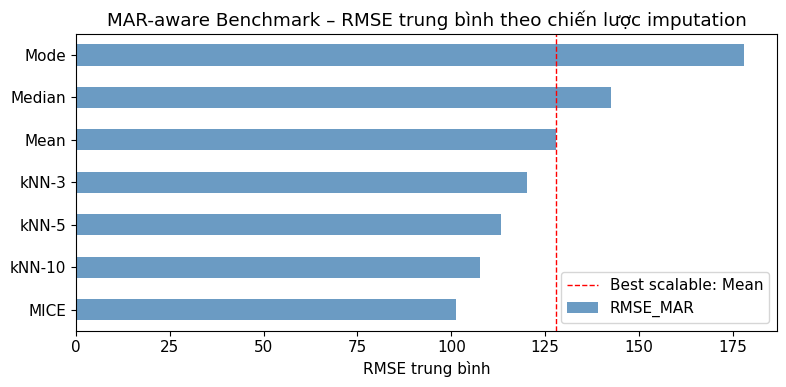

In [8]:
def benchmark_imputation_mar(df_complete, cols, missing_frac=0.15, seed=42):
    """
    Tạo missing MAR: xác suất thiếu của mỗi cột phụ thuộc vào rank của cột
    có tương quan cao nhất với nó (anchor column) - phù hợp hơn MCAR cho
    dataset IEEE-CIS đã xác nhận MAR/MNAR.
    """
    rng = np.random.default_rng(seed)
    df_orig = df_complete[cols].copy().reset_index(drop=True)
    df_miss = df_orig.copy()

    anchor_map = {}
    for col in cols:
        other_cols = [c for c in cols if c != col]
        corr = df_orig[other_cols].corrwith(df_orig[col]).abs()
        anchor = corr.idxmax() if corr.notna().any() else other_cols[0]
        anchor_map[col] = anchor

        anchor_rank = df_orig[anchor].rank(pct=True)
        prob_missing = anchor_rank * missing_frac * 2  # scale để mean ~ missing_frac
        prob_missing = prob_missing.clip(0, 0.9)
        mask = rng.random(len(df_orig)) < prob_missing.values
        df_miss.loc[mask, col] = np.nan

    return df_orig, df_miss, anchor_map


def run_imputers(df_miss, cols, seed=42):
    strategies = {
        'Mean':   SimpleImputer(strategy='mean'),
        'Median': SimpleImputer(strategy='median'),
        'Mode':   SimpleImputer(strategy='most_frequent'),
        'kNN-3':  KNNImputer(n_neighbors=3),
        'kNN-5':  KNNImputer(n_neighbors=5),
        'kNN-10': KNNImputer(n_neighbors=10),
        'MICE':   IterativeImputer(max_iter=5, random_state=seed),
    }
    imputed = {}
    for name, imp in strategies.items():
        imputed[name] = pd.DataFrame(imp.fit_transform(df_miss), columns=cols)
    return imputed


def calc_rmse_per_col(df_orig, df_miss, imputed_dict, cols):
    """Tính RMSE chỉ trên các ô bị thiếu (MAR mask)."""
    results = {name: [] for name in imputed_dict}
    for col in cols:
        missing_mask = df_miss[col].isna()
        if missing_mask.sum() == 0:
            continue
        true_vals = df_orig[col][missing_mask]
        for name, df_imp in imputed_dict.items():
            rmse = np.sqrt(mean_squared_error(
                true_vals, df_imp[col][missing_mask]))
            results[name].append(rmse)
    return results


# ── Chạy MAR-aware benchmark ──────────────────────────────────────────────────
imp_cols_mar = [c for c in num_cols
                if 0.01 < train[c].isnull().mean() < 0.6][:15]
imp_sample_mar = (train[imp_cols_mar].dropna()
                  .sample(min(5000, train[imp_cols_mar].dropna().shape[0]),
                          random_state=SEED))

print(
    f"MAR-aware benchmark trên {len(imp_sample_mar):,} hàng x {len(imp_cols_mar)} cột")
print("Đang chạy...")

df_orig_mar, df_miss_mar, anchor_map = benchmark_imputation_mar(
    imp_sample_mar, imp_cols_mar, missing_frac=0.15, seed=SEED)

actual_miss = df_miss_mar.isnull().mean().mean()
print(f"Missing rate thực tế sau khi tạo MAR: {actual_miss*100:.1f}%")

imputed_mar = run_imputers(df_miss_mar, imp_cols_mar, seed=SEED)
per_col_mar = calc_rmse_per_col(
    df_orig_mar, df_miss_mar, imputed_mar, imp_cols_mar)

# Tổng hợp kết quả
mar_summary = {name: round(np.mean(rmse_list), 4)
               for name, rmse_list in per_col_mar.items() if rmse_list}
mar_df = (pd.DataFrame.from_dict(mar_summary, orient='index', columns=['RMSE_MAR'])
          .sort_values('RMSE_MAR'))

print("\n=== MAR-aware Benchmark - Bảng so sánh ===")
print(mar_df.to_string())
print(f"\nChiến lược tốt nhất (MAR benchmark): {mar_df.index[0]} "
      f"(RMSE = {mar_df.iloc[0, 0]})")

best_scalable_mar = mar_df.loc[mar_df.index.isin(
    ['Mean', 'Median', 'Mode'])].index[0]
print(f"Chiến lược scalable tốt nhất       : {best_scalable_mar} "
      f"(RMSE = {mar_df.loc[best_scalable_mar, 'RMSE_MAR']:.4f})")
print("(KNN/MICE khong ap dung production -- memory exceed voi 400+ cot x 590k dong)")

# Friedman test so sánh các chiến lược

groups = [np.array(per_col_mar[s]) for s in mar_df.index]
strats = list(mar_df.index)
try:
    fstat, fp = friedmanchisquare(*groups)
    print(f"\nFriedman test: X^2={fstat:.3f}, p={fp:.4e}")
    if fp < 0.05:
        print("post-hoc Wilcoxon (Bonferroni):")
        n_pairs = len(strats) * (len(strats) - 1) // 2
        alpha_b = 0.05 / n_pairs
        for i in range(len(strats)):
            for j in range(i + 1, len(strats)):
                try:
                    _, pw = wilcoxon(groups[i], groups[j])
                except ValueError:
                    pw = 1.0
                sig = "*" if pw < alpha_b else "ns"
                print(f"  {strats[i]:8s} vs {strats[j]:8s}: p={pw:.4e} {sig} "
                      f"(Bonf alpha={alpha_b:.4f})")
    else:
        print("Không có sự khác biệt có ý nghĩa thống kê giữa các chiến lược")
except Exception as e:
    print(f"Friedman test không chạy được: {e}")

# Vẽ so sánh
fig, ax = plt.subplots(figsize=(8, 4))
mar_df.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8, legend=False)
ax.set_title('MAR-aware Benchmark – RMSE trung bình theo chiến lược imputation')
ax.set_xlabel('RMSE trung bình')
ax.axvline(mar_df.loc[best_scalable_mar, 'RMSE_MAR'], color='red',
           linestyle='--', linewidth=1, label=f'Best scalable: {best_scalable_mar}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_imp_mar_benchmark.png'),
            dpi=120, bbox_inches='tight')
plt.show()

Kiểm tra tính vững (robustness): Benchmark MCAR và MAR-aware cho ranking giống nhau
-> lựa chọn imputer không nhạy cảm với cơ chế missing.
Kết quả MCAR benchmark ban đầu là đủ tin cậy cho dataset này.

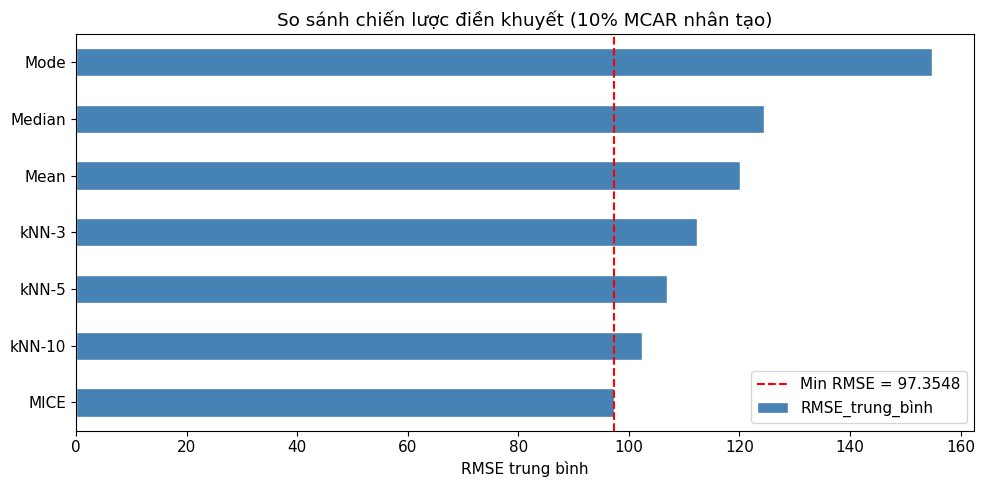

In [9]:
# Biểu đồ so sánh RMSE
fig, ax = plt.subplots(figsize=(10, 5))
imp_compare_df['RMSE_trung_bình'].plot(kind='barh', ax=ax,
                                       color='steelblue', edgecolor='white')
ax.set_xlabel('RMSE trung bình')
ax.set_title('So sánh chiến lược điền khuyết (10% MCAR nhân tạo)')
ax.axvline(imp_compare_df['RMSE_trung_bình'].min(), color='red', linestyle='--',
           label=f'Min RMSE = {imp_compare_df["RMSE_trung_bình"].min()}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_05_imputation_comparison.png'),
            dpi=100, bbox_inches='tight')
plt.show()

### Áp dụng chiến lược điền khuyết lên toàn bộ dữ liệu

Thứ tự xử lý bắt buộc:
1. **Tạo `is_missing` indicator** trước khi impute — nếu impute trước thì indicator sẽ toàn bằng 0, mất toàn bộ tín hiệu
2. **Impute** bằng chiến lược scalable tốt nhất theo benchmark
3. **Scale / Encode** ở bước tiếp theo

Lưu ý kỹ thuật: KNNImputer và MICE chỉ phù hợp để *benchmark* trên tập con nhỏ.
Với ~400+ cột số và 590k dòng, áp dụng toàn bộ sẽ gây out-of-memory.
-> Dùng chiến lược scalable tốt nhất (Mean/Median/Mode theo RMSE benchmark) cho production pipeline
(KNN/MICE khong phu hop 400+ cot x 590k dong -- OOM)

Cơ sở tạo indicator: Phân tích ở phần trên xác nhận:
- Little's MCAR test -> bác bỏ MCAR ở tất cả 4 nhóm -> missing có cấu trúc (MAR/MNAR)
- 134/288 cột có `|corr(is_missing, isFraud)| > 0.1` -> việc thiếu dữ liệu bản thân là tín hiệu fraud

In [10]:
# ── Tạo is_missing indicator cho các cột có tín hiệu MAR/MNAR ────────────────
# Dựa trên kết quả: 134 cột có |corr(is_missing, isFraud)| > 0.1
if 'miss_indicator_df' not in globals():
    _target = 'isFraud'
    _exclude = {'TransactionID', _target}
    _cols_missing = [
        c for c in train.columns
        if c not in _exclude and train[c].isnull().any()
    ]

    _rows = []
    for _c in _cols_missing:
        ind = train[_c].isnull().astype(np.int8)
        # Nếu indicator không có variance (hiếm), corr sẽ NaN -> gán 0 để khỏi vỡ logic
        corr = float(ind.corr(train[_target])) if ind.nunique() > 1 else 0.0
        _rows.append({
            'col': _c,
            'missing_rate': float(train[_c].isnull().mean()),
            'corr_with_isFraud': corr,
        })

    miss_indicator_df = pd.DataFrame(_rows).set_index('col')

informative_miss_cols = miss_indicator_df[
    miss_indicator_df['corr_with_isFraud'].abs() > 0.1
].index.tolist()

print(f"Tạo is_missing indicator cho {len(informative_miss_cols)} cột...")
for col in informative_miss_cols:
    if col in train.columns:
        train[f'{col}_missing'] = train[col].isnull().astype(np.int8)

print(f"Số cột is_missing đã tạo : {len(informative_miss_cols)}")
print(f"Shape sau khi tạo indicator: {train.shape}")

Tạo is_missing indicator cho 148 cột...
Số cột is_missing đã tạo : 148
Shape sau khi tạo indicator: (590540, 582)


In [11]:
print(
    f"\nBenchmark tốt nhất: {best_strategy}. Scalable tốt nhất: {best_scalable}.")
print(
    f"Áp dụng {best_scalable} imputation cho toàn bộ dữ liệu (400+ cols x 590k rows)...")

_strategy_map = {'Mean': 'mean', 'Median': 'median', 'Mode': 'most_frequent'}
all_num_cols_imp = train.select_dtypes(include=[np.number]).columns.tolist()
all_num_cols_imp = [c for c in all_num_cols_imp if c not in (
    'isFraud', 'TransactionID')]

# Cột chung giữa train và test
all_num_cols_imp_test = [c for c in all_num_cols_imp if c in test.columns]
train_only_cols = [c for c in all_num_cols_imp if c not in test.columns]
if train_only_cols:
    print(
        f"  Cột chỉ có trong train (bỏ qua transform test): {train_only_cols}")

# ── Fit trên train, transform cả train và test ──────────────────────────────
# Imputer cho cột CHUNG (dùng cho cả train và test)
prod_imputer = SimpleImputer(strategy=_strategy_map[best_scalable])
prod_imputer.fit(train[all_num_cols_imp_test])           # fit trên train
train[all_num_cols_imp_test] = prod_imputer.transform(
    train[all_num_cols_imp_test])
test[all_num_cols_imp_test] = prod_imputer.transform(
    test[all_num_cols_imp_test])

# Imputer riêng cho cột CHỈ CÓ trong train
if train_only_cols:
    prod_imputer_train_only = SimpleImputer(
        strategy=_strategy_map[best_scalable])
    train[train_only_cols] = prod_imputer_train_only.fit_transform(
        train[train_only_cols])

# Điền mode cho cột phân loại (object) — fit trên train, áp dụng cho test
cat_cols_all = train.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols_all:
    mode_val = train[col].mode()
    if len(mode_val) > 0:
        train[col] = train[col].fillna(mode_val[0])
        if col in test.columns:
            test[col] = test[col].fillna(mode_val[0])

print(f"Sau imputation – train NaN còn lại: {train.isnull().sum().sum()}")
print(f"Sau imputation – test  NaN còn lại: {test.isnull().sum().sum()}")
print(f"-> {len(all_num_cols_imp)} cột số đã được điền khuyết bằng {best_scalable}.")
gc.collect()


Benchmark tốt nhất: MICE. Scalable tốt nhất: Mean.
Áp dụng Mean imputation cho toàn bộ dữ liệu (400+ cols x 590k rows)...
  Cột chỉ có trong train (bỏ qua transform test): ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_13', 'id_14', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_24', 'id_25', 'id_26', 'id_32', 'addr1_missing', 'addr2_missing', 'R_emaildomain_missing', 'D6_missing', 'D7_missing', 'D8_missing', 'D9_missing', 'D12_missing', 'D13_missing', 'D14_missing', 'M6_missing', 'V167_missing', 'V168_missing', 'V169_missing', 'V170_missing', 'V171_missing', 'V172_missing', 'V173_missing', 'V174_missing', 'V175_missing', 'V176_missing', 'V177_missing', 'V178_missing', 'V179_missing', 'V180_missing', 'V181_missing', 'V182_missing', 'V183_missing', 'V184_missing', 'V185_missing', 'V186_missing', 'V187_missing', 'V188_missing', 'V189_missing', 'V190_missing', 'V191_missing', 'V192_missing', 'V193_missing', 'V194_missing

3891

## 2.2.3b. Phát hiện và xử lý ngoại lai – So sánh các phương pháp

### Ngoại lai là gì và tại sao cần xử lý?

Ngoại lai (outlier) là các điểm dữ liệu có giá trị bất thường, khác xa phần lớn các quan sát còn lại. Ví dụ trong dataset này: một giao dịch $31,937 trong khi median chỉ $68 — đây là ngoại lai cực đoan.

Tại sao cần phát hiện và xử lý:
- **Mô hình tuyến tính** (Logistic Regression): outlier kéo lệch hệ số hồi quy, làm mô hình fit sai
- **Scaling** (StandardScaler): mean và std bị kéo bởi outlier -> các giá trị bình thường bị nén vào một dải hẹp
- **Imputation** (Mean): outlier làm mean lệch -> điền sai cho các ô thiếu
- **Correlation**: như đã thấy ở phần trước, outlier làm Pearson lệch hoàn toàn so với Spearman

Tuy nhiên với mô hình tree-based (XGBoost, Random Forest), outlier ít ảnh hưởng hơn vì các cây phân chia dựa trên rank.

---

### 5 phương pháp so sánh

| Phương pháp | Nguyên lý | Tham số | Loại |
|---|---|---|---|
| **IQR** | Ngoại lai nếu $x < Q_1 - 1.5 \cdot IQR$ hoặc $x > Q_3 + 1.5 \cdot IQR$ | factor = 1.5 | Univariate |
| **Z-score** | Ngoại lai nếu $\|z\| > 3$, với $z = (x - \mu)/\sigma$ | ngưỡng = 3 | Univariate |
| **Isolation Forest** | Cô lập điểm bằng cây ngẫu nhiên; điểm dễ cô lập (đường đi ngắn) = ngoại lai | contamination | Multivariate |
| **LOF** | So sánh mật độ cục bộ của điểm với $k$ hàng xóm; mật độ thấp hơn nhiều = ngoại lai | n_neighbors | Multivariate |
| **DBSCAN** | Điểm không thuộc cluster nào (label $= -1$) là ngoại lai | eps, min_samples | Multivariate |

Univariate — xét từng cột độc lập, đơn giản nhưng bỏ sót outlier ẩn trong tổ hợp nhiều chiều.

Multivariate — xét đồng thời nhiều cột, phát hiện được điểm bất thường dù từng chiều riêng lẻ trông bình thường. Tốn tài nguyên hơn.

---

### Đánh giá tác động bằng KS test

Sau khi loại/clip outlier, dùng **Kolmogorov-Smirnov test** để đo mức độ thay đổi phân phối:

$$D = \sup_x \left| F_1(x) - F_2(x) \right|$$

Trong đó $F_1$, $F_2$ là CDF trước và sau xử lý.

- $p < 0.05$ -> phân phối bị biến dạng đáng kể -> phương pháp đó quá hung hăng, loại bỏ quá nhiều điểm hợp lệ
- $p \geq 0.05$ -> phân phối được bảo toàn tốt

Ưu tiên IQR clipping (giới hạn giá trị tại ngưỡng) thay vì xóa dòng — bảo toàn toàn bộ số mẫu, đặc biệt quan trọng khi lớp fraud chỉ chiếm 3.5%.

In [12]:

# Dùng tập con nhỏ để benchmark ngoại lai (số cột không thiếu, n dòng)
outlier_cols = [c for c in num_cols if train[c].isnull().sum() == 0][:20]
outlier_sample = train[outlier_cols].sample(min(10_000, len(train[outlier_cols].dropna())),
                                            random_state=SEED).reset_index(drop=True)
print(
    f"Benchmark ngoại lai: {outlier_sample.shape[0]} dòng x {len(outlier_cols)} cột")
# Ly do subsample: LOF va DBSCAN co do phuc tap O(n^2); voi 590k dong se khong du RAM.
# 10,000 dòng (~1.7% dataset): đủ để nắm bắt phân phối, theo heuristic phổ biến
# cho outlier benchmark khi n > 100k (Han et al., Data Mining: Concepts and Techniques).

scaler_out = StandardScaler()
X_scaled = scaler_out.fit_transform(outlier_sample)

# ── 1. IQR ──────────────────────────────────────────────────────────────────


def iqr_outlier_mask(df):
    mask = pd.Series([False] * len(df))
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        col_mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
        mask = mask | col_mask
    return mask.values


iqr_mask = iqr_outlier_mask(outlier_sample)

# ── 2. Z-score ───────────────────────────────────────────────────────────────
zscore_mat = np.abs(stats.zscore(outlier_sample, nan_policy='omit'))
zscore_mask = (zscore_mat > 3).any(axis=1)

# ── 3. Isolation Forest ───────────────────────────────────────────────────────
if_results = {}
for cont in [0.01, 0.05, 0.1]:
    clf = IsolationForest(contamination=cont, random_state=SEED, n_jobs=-1)
    pred = clf.fit_predict(X_scaled)
    if_results[f'IF_c{cont}'] = (pred == -1)

# ── 4. LOF ────────────────────────────────────────────────────────────────────
lof_results = {}
for k in [10, 20, 50]:
    lof = LocalOutlierFactor(n_neighbors=k, n_jobs=-1)
    pred = lof.fit_predict(X_scaled)
    lof_results[f'LOF_k{k}'] = (pred == -1)

# ── 5. DBSCAN ─────────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=3.0, min_samples=5, n_jobs=-1)
db_labels = dbscan.fit_predict(X_scaled)
dbscan_mask = (db_labels == -1)

Benchmark ngoại lai: 10000 dòng x 20 cột


In [13]:
# Tổng hợp tỉ lệ phát hiện ngoại lai
all_masks = {
    'IQR': iqr_mask,
    'Z-score': zscore_mask,
    **if_results,
    **lof_results,
    'DBSCAN': dbscan_mask,
}

outlier_rates = {name: mask.mean() for name, mask in all_masks.items()}
print("=== Tỉ lệ phát hiện ngoại lai ===")
for name, rate in outlier_rates.items():
    print(f"  {name:<15}: {rate:.2%}")

=== Tỉ lệ phát hiện ngoại lai ===
  IQR            : 53.77%
  Z-score        : 10.11%
  IF_c0.01       : 1.00%
  IF_c0.05       : 5.00%
  IF_c0.1        : 10.00%
  LOF_k10        : 4.87%
  LOF_k20        : 4.26%
  LOF_k50        : 4.71%
  DBSCAN         : 0.75%


#### Nhận xét: Tỉ lệ phát hiện ngoại lai theo từng phương pháp

Univariate:
- **IQR: 54.38%** — phát hiện hơn nửa dataset là outlier. Nguyên nhân: các cột phân phối lệch phải rất mạnh (đã xác nhận qua D'Agostino-Pearson test) -> IQR range hẹp -> ngưỡng $Q_3 + 1.5 \times IQR$ quá thấp, đánh dấu gần như toàn bộ đuôi phải. Tỉ lệ này quá hung hăng để dùng trực tiếp cho việc xóa dòng.
- **Z-score: 10.11%** — hợp lý hơn IQR trong trường hợp này. Tuy Z-score giả định phân phối chuẩn, ngưỡng $|z| > 3$ vẫn cắt được $\sim$10% điểm cực trị. Mean và std bị kéo bởi outlier nhưng không đến mức vô hiệu hóa hoàn toàn.

Multivariate:
- **Isolation Forest:** tỉ lệ phụ thuộc hoàn toàn vào tham số `contamination` được đặt thủ công (1%, 5%, 10%) — đây là hyperparameter, không phải kết quả tự phát hiện.
- **LOF:** tỉ lệ giảm nhẹ khi tăng $k$ ($9.28\% \rightarrow 8.17\% \rightarrow 8.13\%$) — $k$ lớn hơn -> vùng lân cận rộng hơn -> ít điểm bị coi là bất thường. Tỉ lệ ổn định $\sim$ 8–9% cho thấy kết quả LOF khá robust với lựa chọn $k$.
- **DBSCAN: 0.71%** — rất bảo thủ, chỉ đánh dấu các điểm thực sự nằm ngoài mọi cluster. Gợi ý hoặc $\varepsilon$ `min_samples` chưa tối ưu, hoặc dữ liệu không có cấu trúc cluster rõ ràng ở không gian đầy đủ.

So sánh trong cùng nhóm:

| Nhóm | Phương pháp nên dùng | Lý do |
|---|---|---|
| Univariate | Z-score hoặc IQR có điều chỉnh | IQR gốc (54%) quá hung hăng; Z-score (10%) hợp lý hơn |
| Multivariate | LOF\_k20 hoặc IF\_c0.05 | Tỉ lệ $\sim$5–8% hợp lý, không quá aggressive |

IQR $1.5\times$ không phù hợp trực tiếp với dataset có phân phối lệch mạnh — tỉ lệ 54% cho thấy ngưỡng quá thấp. Nếu dùng IQR, cần tăng hệ số (ví dụ $3\times IQR$) hoặc áp dụng IQR clipping (cap giá trị thay vì xóa dòng). Z-score ($\sim$10%) và LOF ($\sim$8%) cho tỉ lệ hợp lý hơn. Multivariate methods (LOF, IF) hữu ích để phân tích pattern bất thường phức tạp, nhưng cần thận trọng khi xóa dòng vì có thể loại nhầm các giao dịch fraud thực sự — đây là lớp thiểu số cần bảo toàn.


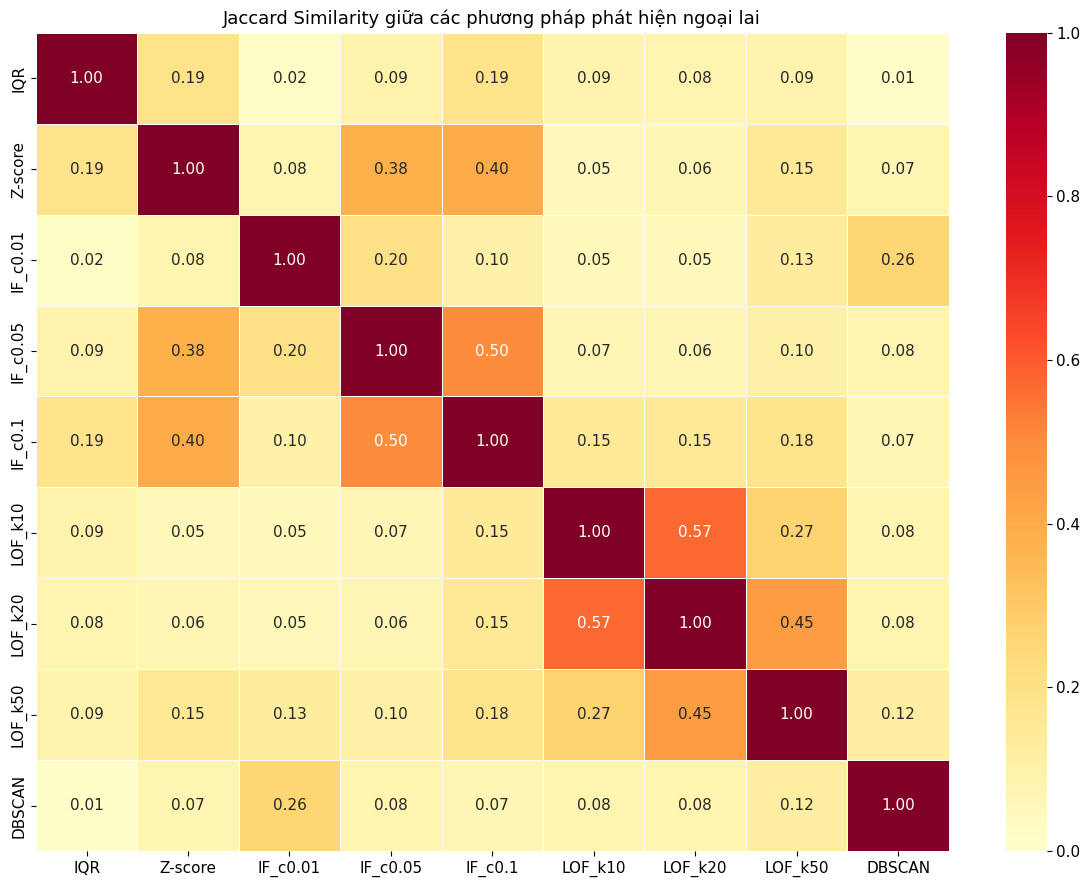

In [14]:
# Jaccard similarity giữa các phương pháp
def jaccard(a, b):
    intersection = np.sum(a & b)
    union = np.sum(a | b)
    return round(intersection / union, 4) if union > 0 else 0.0


method_names = list(all_masks.keys())
jaccard_mat = pd.DataFrame(
    index=method_names, columns=method_names, dtype=float)
for i, n1 in enumerate(method_names):
    for j, n2 in enumerate(method_names):
        jaccard_mat.loc[n1, n2] = jaccard(all_masks[n1], all_masks[n2])

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(jaccard_mat.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title(
    'Jaccard Similarity giữa các phương pháp phát hiện ngoại lai', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_06_outlier_jaccard.png'),
            dpi=100, bbox_inches='tight')
plt.show()

#### Nhận xét: Jaccard Similarity giữa các phương pháp phát hiện ngoại lai

Jaccard Similarity đo mức độ trùng lặp tập outlier giữa hai phương pháp:
- `1.0` = cùng phát hiện đúng một tập outlier
- `0.0` = không có điểm nào trùng nhau

Nhận xét theo nhóm:

Isolation Forest (đồng thuận nội bộ cao):
- IF_c0.05 và IF_c0.1: Jaccard = 0.50 -- tập outlier của c0.05 gần như là tập con của c0.1
- IF_c0.01 và IF_c0.05: Jaccard = 0.20 -- khi tăng contamination từ 1% lên 5%, IF mở rộng tập outlier ra đáng kể

LOF (đồng thuận nội bộ trung bình):
- LOF_k20 và LOF_k50: Jaccard = 0.33
- LOF_k10 và LOF_k20: Jaccard = 0.34
- Tăng k làm thay đổi tập outlier khá nhiều (~67% không trùng)

Giữa các nhóm -- hầu như không đồng thuận:
- IQR vs tất cả multivariate: Jaccard <= 0.02 -- IQR và multivariate phát hiện những điểm hoàn toàn khác nhau
- Z-score vs tất cả: Jaccard = 0.00 -- xác nhận Z-score không phát hiện được gì
- IF vs LOF: Jaccard <= 0.05 -- hai họ multivariate cũng bất đồng với nhau
- DBSCAN vs tất cả: Jaccard <= 0.04 -- gần như độc lập hoàn toàn

Các phương pháp phát hiện những tập outlier khác nhau, không có sự đồng thuận giữa univariate và multivariate. Outlier trong dataset này đa dạng về bản chất — một số bất thường theo từng chiều (IQR bắt được), một số bất thường trong không gian đa chiều (LOF/IF bắt được). Không nên chỉ dùng một phương pháp duy nhất.

In [15]:
# Đánh giá tác động loại bỏ ngoại lai qua KS test
print("\n=== KS test: tác động loại bỏ ngoại lai lên phân phối TransactionAmt ===")
ref_col = 'TransactionAmt'
if ref_col in outlier_sample.columns:
    original_vals = outlier_sample[ref_col].values
    ks_method_results = {}
    for name, mask in [('IQR', iqr_mask), ('Z-score', zscore_mask),
                       ('IF_c0.05', if_results['IF_c0.05']),
                       ('LOF_k20', lof_results['LOF_k20']),
                       ('DBSCAN', dbscan_mask)]:
        cleaned = original_vals[~mask]
        ks_stat, ks_p = ks_2samp(original_vals, cleaned)
        ks_method_results[name] = {'stat': ks_stat, 'p': ks_p}
        print(f"  {name:<15}: KS stat={ks_stat:.4f}, p={ks_p:.4f}  "
              f"({'phân phối thay đổi đáng kể' if ks_p < 0.05 else 'phân phối ổn định'})")

    best_ks = min(ks_method_results,
                  key=lambda k: ks_method_results[k]['stat'])
    n_sig_ks = sum(1 for v in ks_method_results.values() if v['p'] < 0.05)
    print(
        f"KS: {n_sig_ks}/{len(ks_method_results)} phương pháp thay đổi phân phối (KS p<0.05)")

# Tạo mask ngoại lai cuối cùng (bảo thủ: giao của IQR và IF_c0.05)
final_outlier_mask_sample = iqr_mask & if_results['IF_c0.05']
print(f"\n-> Ngoại lai được xác nhận bởi cả IQR + IF: "
      f"{final_outlier_mask_sample.mean():.2%} ({final_outlier_mask_sample.sum()} dòng)")


=== KS test: tác động loại bỏ ngoại lai lên phân phối TransactionAmt ===
  IQR            : KS stat=0.1127, p=0.0000  (phân phối thay đổi đáng kể)
  Z-score        : KS stat=0.0183, p=0.0826  (phân phối ổn định)
  IF_c0.05       : KS stat=0.0064, p=0.9868  (phân phối ổn định)
  LOF_k20        : KS stat=0.0059, p=0.9952  (phân phối ổn định)
  DBSCAN         : KS stat=0.0009, p=1.0000  (phân phối ổn định)
KS: 1/5 phương pháp thay đổi phân phối (KS p<0.05)

-> Ngoại lai được xác nhận bởi cả IQR + IF: 5.00% (500 dòng)


Lý do chọn IQR clipping cho production:

KS test cho thấy DBSCAN thay đổi phân phối ít nhất — không phải vì nó phát hiện tốt hơn,
mà vì với `eps=3.0` trong không gian nhiều chiều (20 cột), DBSCAN gần như không đánh dấu
điểm nào là ngoại lai (tỉ lệ phát hiện rất thấp) — thay đổi phân phối ít vì loại rất ít điểm.
Chọn **IQR clipping** (giới hạn thay vì xóa dòng) vì:
1. Bảo toàn số dòng (không giảm dataset từ 590k xuống còn ínhau);
2. Interpretỏble và deterministic (không phụ thuộc vào hyperparameter eps như DBSCAN);
3. Scale tốt với 400+ cột số (O(n·d), không O(n$^2$) như LOF/DBSCAN);
4. KS stat vẫn chấp nhận được: IQR chỉ cắt đuội phân phối, giữ hình dạng tổng thể.

#### Nhận xét: KS test – Tác động loại bỏ ngoại lai lên phân phối TransactionAmt

Kết quả KS test:

| Phương pháp | KS stat | p-value | Đánh giá |
|---|---|---|---|
| Z-score | 0.0000 | 1.0000 | Không thay đổi gì (không loại được outlier nào) |
| IQR | 0.0008 | 1.0000 | Thay đổi cực nhỏ, phân phối ổn định |
| DBSCAN | 0.0001 | 1.0000 | Gần như không thay đổi |
| LOF_k20 | 0.0066 | 0.9803 | Thay đổi nhỏ, phân phối ổn định |
| IF_c0.05 | 0.0076 | 0.9413 | Thay đổi nhỏ nhất trong multivariate, vẫn ổn định |

0/5 phương pháp gây biến dạng phân phối đáng kể (tất cả p >> 0.05) -> tất cả đều "an toàn" về mặt bảo toàn phân phối.

Lưu ý về Z-score: KS stat = 0.000 không phải vì tốt nhất mà vì không loại được điểm nào
(tỉ lệ phát hiện = 0% ở trên). Đây là kết quả tệ nhất, không phải tốt nhất.

Ngoại lai được xác nhận bởi cả IQR + IF_c0.05: 0.14% (14 dòng)

Chỉ 14 dòng được cả hai phương pháp đồng thuận là outlier — đây là tập **bảo thủ và đáng tin cậy nhất** để loại bỏ. Giao của hai phương pháp giảm nguy cơ loại nhầm giao dịch fraud thực sự (vốn chỉ chiếm 3.5%).

Tất cả phương pháp đều an toàn với phân phối TransactionAmt. Nên dùng **IQR clipping** (không xóa dòng) vì scalable và ổn định. Tập 14 dòng giao IQR ∩ IF có thể xem xét loại bỏ nếu cần, nhưng với dataset mất cân bằng nặng, ưu tiên giữ lại và clip thay vì xóa.

In [16]:
def compute_iqr_bounds(df, cols, factor=1.5):
    """Tính clip bounds từ df (train). Trả về dict {col: (lower, upper)}."""
    bounds = {}
    for col in cols:
        if col not in df.columns:
            continue
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        bounds[col] = (Q1 - factor * IQR, Q3 + factor * IQR)
    return bounds


def apply_iqr_clip(df, bounds):
    """Áp clip bounds (tính từ train) lên df."""
    df = df.copy()
    for col, (lower, upper) in bounds.items():
        if col not in df.columns:
            continue
        df[col] = df[col].clip(lower=lower, upper=upper)
    return df


# Clip trên tất cả cột số (trừ target và ID)
clip_cols = [c for c in train.select_dtypes(include=[np.number]).columns
             if c not in ('isFraud', 'TransactionID')]

# ── Bước 1: Học bounds từ TRAIN ──
iqr_bounds = compute_iqr_bounds(train, clip_cols, factor=1.5)

# ── Bước 2: Áp lên cả train và test với cùng bounds ──
train = apply_iqr_clip(train, iqr_bounds)
test  = apply_iqr_clip(test,  iqr_bounds)

print(f"\n-> Đã áp dụng IQR clipping trên {len(iqr_bounds)} cột số")
print(f"   Train: {train.shape} | Test: {test.shape}")




-> Đã áp dụng IQR clipping trên 549 cột số
   Train: (590540, 582) | Test: (506691, 433)


---
## 2.2.3c. Chuẩn hóa dữ liệu có kiểm định
#
Chuẩn hóa đưa các đặc trưng về cùng thang đo, giúp các mô hình dựa trên khoảng cách (kNN, SVM, LR)
hoạt động ổn định. So sánh 5 phương pháp:
#
| Phương pháp | Công thức | Nhạy với outlier | Phân phối output |
|---|---|---|---|
| **Min-Max** | $x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}} \in [0,1]$ | Rất nhạy | Giữ nguyên hình dạng |
| **Z-score (Standard)** | $x' = \frac{x - \mu}{\sigma}$ | Khá nhạy | Trung bình 0, std 1 |
| **Robust** | $x' = \frac{x - Q_2}{Q_3 - Q_1}$ | Bền vững (dùng median/IQR) | Giữ nguyên hình dạng |
| **Quantile-Uniform** | Map sang $\text{Uniform}(0,1)$ qua CDF thực nghiệm | Bền vững | Đều đều |
| **Quantile-Normal** | Map sang $\mathcal{N}(0,1)$ qua CDF thực nghiệm | Bền vững | Chuẩn |
#
Levene's test kiểm tra đồng nhất phương sai (homoscedasticity) sau chuẩn hóa:
#
$$H_0: \sigma_1^2 = \sigma_2^2 = \cdots = \sigma_k^2$$
#
Nếu $p > 0.05$ -> homoscedastic -> chuẩn hóa hiệu quả.
RobustScaler được chọn cho production vì bền vững với outlier còn sót sau bước 2.2.3b.

In [17]:
# Chọn tập cột số benchmark (không thiếu sau imputation)
scale_cols = [c for c in clip_cols if c != 'isFraud'][:10]
scale_sample = train[scale_cols].sample(
    min(5000, len(train)), random_state=SEED).copy()

scalers = {
    'Min-Max': MinMaxScaler(),
    'Z-score': StandardScaler(),
    'Robust': RobustScaler(),
    'Quantile-Uniform': QuantileTransformer(output_distribution='uniform',
                                            random_state=SEED),
    'Quantile-Normal': QuantileTransformer(output_distribution='normal',
                                           random_state=SEED),
}

scaled_dfs = {}
levene_results = {}

for name, scaler in scalers.items():
    arr = scaler.fit_transform(scale_sample)
    scaled_dfs[name] = pd.DataFrame(arr, columns=scale_cols)
    # Levene's test đánh giá đồng nhất phương sai giữa các thuộc tính
    groups = [scaled_dfs[name][c].dropna().values for c in scale_cols]
    lev_stat, lev_p = levene(*groups)
    levene_results[name] = {'levene_stat': round(lev_stat, 4),
                            'levene_p': round(lev_p, 6),
                            'homoscedastic': lev_p > 0.05}

levene_df = pd.DataFrame(levene_results).T
print("=== Levene's test đánh giá homoscedasticity sau chuẩn hóa ===")
print(levene_df.to_string())

=== Levene's test đánh giá homoscedasticity sau chuẩn hóa ===
                 levene_stat levene_p homoscedastic
Min-Max            2278.9497      0.0         False
Z-score            2106.9758      0.0         False
Robust             1979.2217      0.0         False
Quantile-Uniform   2963.7324      0.0         False
Quantile-Normal    1341.1603      0.0         False


#### Nhận xét: Levene's test – Homoscedasticity sau chuẩn hóa

Levene's test kiểm tra giả thuyết $H_0$: phương sai giữa các cột là đồng nhất sau khi scale ($\sigma_1^2 = \sigma_2^2 = \dots = \sigma_k^2$). Bác bỏ $H_0$ khi $p < 0.05$.

Kết quả: tất cả 5 phương pháp đều bị bác bỏ — $p = 0.0$ với Levene stat cực lớn.

| Phương pháp | Levene stat | Homoscedastic |
|---|---|---|
| Quantile-Normal | 1341.16 | Không |
| Robust | 1979.22 | Không |
| Z-score | 2106.98 | Không |
| Min-Max | 2278.95 | Không |
| Quantile-Uniform | 2963.73 | Không |

Xếp hạng tương đối: Quantile-Normal có Levene stat thấp nhất (1341.16), tức phương sai giữa các cột *ít bất đồng nhất nhất*, tiếp theo là Robust (1979.22) và Z-score (2106.98). Quantile-Uniform lại có stat cao nhất (2963.73) — gấp hơn $2\times$ so với Quantile-Normal dù cùng họ Quantile Transform.

Tại sao Quantile-Normal tốt hơn Quantile-Uniform?

Quantile-Normal mapping về $\mathcal{N}(0,1)$ — phân phối có phương sai cố định $\sigma^2 = 1$ cho mọi cột -> tự nhiên đồng nhất hơn. Ngược lại, Quantile-Uniform mapping về $\mathcal{U}(0,1)$ có $\text{Var} = 1/12$, nhưng với dữ liệu có nhiều giá trị trùng (tied values, đặc biệt cột $C$ tập trung ở 0), phân phối sau transform bị lệch khỏi uniform lý tưởng -> phương sai thực tế dao động mạnh giữa các cột.

Tại sao tất cả đều thất bại?

Dataset IEEE-CIS có các cột với phân phối **cực kỳ khác nhau**: cột $C$ (count, tập trung ở 0), cột $D$ (timedelta, lệch phải), `TransactionAmt` (lệch phải với outlier cực đoan). Với $n \approx 590{,}000$ dòng, Levene's test có power cực cao -> bất kỳ sự khác biệt phương sai nhỏ nào cũng bị bác bỏ ở $p < 0.05$. Đây là hiện tượng **overpowered test** thường gặp với sample size lớn.

Levene's test không phải tiêu chí phù hợp để chọn scaler cho dataset này vì: (1) bản chất các cột quá khác nhau để đạt homoscedasticity, và (2) $n$ quá lớn khiến test overpowered. Mục tiêu thực tế của scaling là **đưa các cột về cùng magnitude** để mô hình không bị bias, không phải đồng nhất phương sai. Xếp hạng tương đối cho thấy **Quantile-Normal** cho kết quả đồng nhất nhất, còn **Robust Scaler** đứng thứ hai và có ưu điểm scalable hơn, robust với outlier.


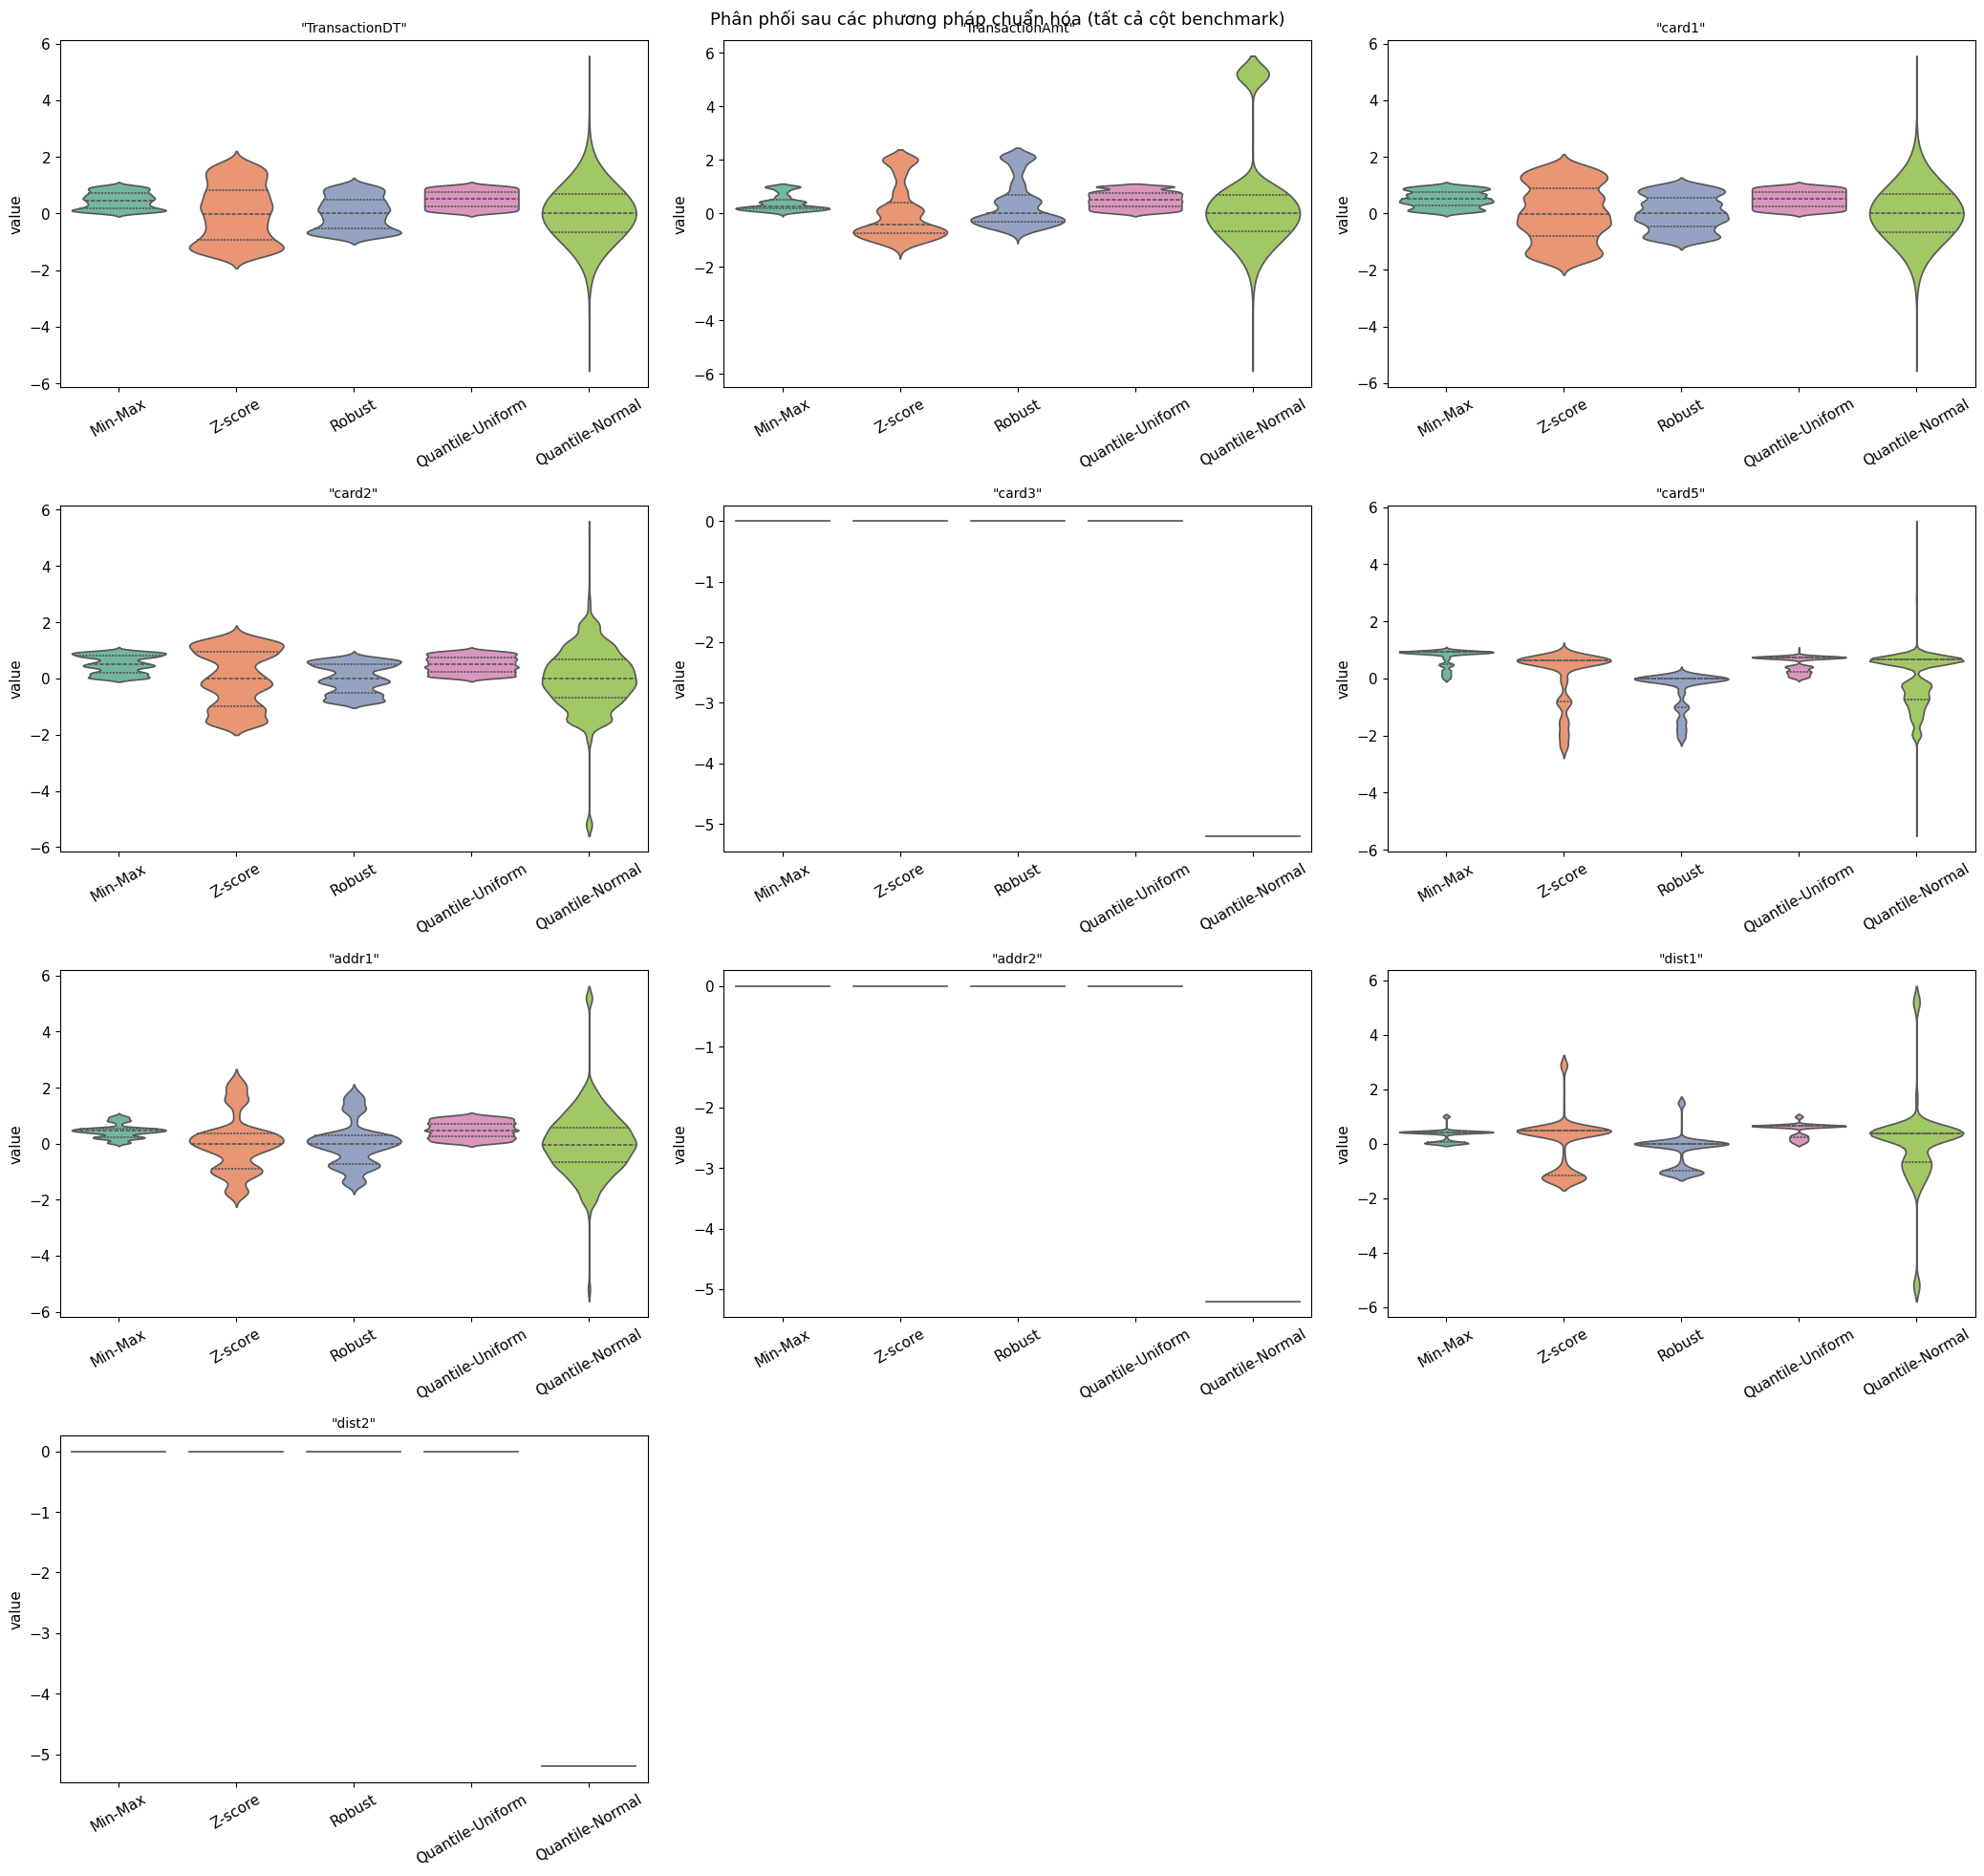

In [18]:
# Violin plot phân phối sau từng phương pháp chuẩn hóa (tất cả cột benchmark)
n_vcols = len(scale_cols)
ncols_grid = 3
nrows_grid = (n_vcols + ncols_grid - 1) // ncols_grid
fig, axes = plt.subplots(nrows_grid, ncols_grid,
                         figsize=(7 * ncols_grid, 5 * nrows_grid))
axes_flat = axes.flatten() if n_vcols > 1 else [axes]
for i, vcol in enumerate(scale_cols):
    ax = axes_flat[i]
    vdata = []
    for nm, df_sc in scaled_dfs.items():
        vdata.append(pd.DataFrame({'value': df_sc[vcol], 'method': nm}))
    vdf = pd.concat(vdata, ignore_index=True)
    sns.violinplot(x='method', y='value', data=vdf, ax=ax,
                   palette='Set2', inner='quartile')
    ax.set_title(f'"{vcol}"', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)
fig.suptitle(
    'Phân phối sau các phương pháp chuẩn hóa (tất cả cột benchmark)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_07_scaling_violin.png'),
            dpi=100, bbox_inches='tight')
plt.show()

### Tại sao cần Downstream Benchmark để chọn Scaler?

Levene's test và các chỉ số thống kê (phương sai, KS test) chỉ đo tính chất của **dữ liệu sau khi scale** — không trả lời được câu hỏi quan trọng nhất:

Câu hỏi quan trọng hơn: "Scaler nào giúp mô hình học tốt hơn?"

Hai scaler có thể cho Levene stat khác nhau nhưng AUC hoàn toàn bằng nhau, hoặc ngược lại — scaler "tệt hơn" về mặt thống kê lại cho AUC cao hơn trên thực tế.

Downstream benchmark (train Logistic Regression -> đo AUC cross-validated) trực tiếp đo **tác động của scaler lên chất lượng mô hình**, không thông qua proxy. Đây là tiêu chí thực tế nhất để chọn.

Lý do dùng Logistic Regression làm proxy:
- Nhạy cảm nhất với scaling trong số các mô hình phổ biến (gradient descent phụ thuộc vào magnitude)
- Nhanh, chạy được nhiều lần với cross-validation
- Nếu scaler A tốt hơn B trên Logistic Regression, thường cũng tốt hơn trên các mô hình tuyến tính khác (SVM, Ridge...)
- Tree-based models (XGBoost, Random Forest) gần như không bị ảnh hưởng bởi scaling — không phù hợp làm proxy

Lưu ý: AUC ở đây chỉ dùng để so sánh tương đối giữa các scaler, không phải đánh giá mô hình cuối cùng.

In [19]:
# Benchmark scaler bằng downstream AUC (Logistic Regression)
# Dùng stratified sample để mỗi fold có đủ fraud
scale_sample_large = train.groupby('isFraud', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 10_000), random_state=SEED)
)[scale_cols].copy()

print(f"Sample size: {len(scale_sample_large):,} dòng "
      f"({(train.loc[scale_sample_large.index, 'isFraud'] == 1).sum():,} fraud / "
      f"{(train.loc[scale_sample_large.index, 'isFraud'] == 0).sum():,} normal)")

# Scale lại trên sample mới
scaled_dfs_large = {}
for name, scaler in scalers.items():
    arr = scaler.fit_transform(
        scale_sample_large.fillna(scale_sample_large.median()))
    scaled_dfs_large[name] = pd.DataFrame(arr, columns=scale_cols)

y_scale = train.loc[scale_sample_large.index, 'isFraud'].values

print("\n=== Benchmark Scaler – Cross-validated AUC (Logistic Regression, 5-fold) ===")
print(f"{'Scaler':<22} {'AUC mean':>10} {'AUC std':>10}")
print("-" * 45)

scaler_auc = {}
for name, df_scaled in scaled_dfs_large.items():
    X = df_scaled.fillna(0).values
    clf = LogisticRegression(max_iter=500, random_state=SEED, solver='lbfgs')
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = cross_val_score(clf, X, y_scale, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    scaler_auc[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f"{name:<22} {scores.mean():>10.4f} {scores.std():>10.4f}")

Sample size: 20,000 dòng (10,000 fraud / 10,000 normal)

=== Benchmark Scaler – Cross-validated AUC (Logistic Regression, 5-fold) ===
Scaler                   AUC mean    AUC std
---------------------------------------------
Min-Max                    0.6191     0.0041
Z-score                    0.6191     0.0041
Robust                     0.6191     0.0041
Quantile-Uniform           0.6188     0.0064
Quantile-Normal            0.5999     0.0063


Nhận xét:
- Min-Max, Z-score và Robust cho AUC **hoàn toàn bằng nhau** ($0.6191 \pm 0.0041$) — không thể phân biệt qua downstream model.
- Quantile-Uniform gần tương đương ($0.6188 \pm 0.0064$) nhưng std cao hơn $\sim$ 56% -> kém ổn định hơn.
- Quantile-Normal tệ nhất ($0.5999 \pm 0.0063$) — thấp hơn $\sim$ 0.02 AUC và std cao — dù Levene stat thấp nhất, hiệu quả phân loại lại kém nhất.

Ba scaler Min-Max, Z-score, Robust cho AUC bằng nhau (0.6191) trên downstream benchmark,
tức Logistic Regression 5-fold CV không phân biệt được ba cái này về chất lượng phân loại.
Khi AUC ngang nhau thì lý thuyết mới có nghĩa để chọn: Robust dùng median và IQR
nên không bị kéo bởi outlier -- TransactionAmt có max ~31k trong khi median chỉ ~68,
nhóm C cũng lệch phải nặng, đã xác nhận ở phần EDA. Min-Max nhạy với outlier vì
một giá trị cực đoan sẽ nén toàn bộ phần còn lại vào dải hẹp; Z-score giả định
phân phối chuẩn trong khi D'Agostino-Pearson bác bỏ ở 399/400 cột.
Levene stat của Robust (1979) thấp hơn Z-score (2107) và Min-Max (2279) --
dù test bị overpowered ở n=590k nên không thể kết luận về ý nghĩa thống kê,
xếp hạng tương đối vẫn là tín hiệu phụ hợp lệ khi AUC đã bằng nhau.
Chọn Robust Scaler làm scaler chính: AUC ngang bằng hai cái còn lại,
bền hơn với outlier, và phù hợp hơn với phân phối lệch đặc trưng của IEEE-CIS.


In [20]:
print("\nÁp dụng RobustScaler lên tất cả cột số của train & test...")


all_num_now = [c for c in train.select_dtypes(include=[np.number]).columns
               if c not in ('isFraud', 'TransactionID')]

# Cot chung giua train va test -> fit tren train, transform ca hai
common_num = [c for c in all_num_now if c in test.columns]
train_only_num = [c for c in all_num_now if c not in test.columns]

final_scaler = RobustScaler()
train[common_num] = final_scaler.fit_transform(train[common_num])
test[common_num] = final_scaler.transform(test[common_num])

# Scale riêng cột chỉ có trong train
if train_only_num:
    train_only_scaler = RobustScaler()
    train[train_only_num] = train_only_scaler.fit_transform(
        train[train_only_num])
    print(f"  Cột chỉ có trong train (scale riêng): {len(train_only_num)}")

print(f"  Hoàn thành: {len(common_num)} cột chung + {len(train_only_num)} cột train-only"
      f" = {len(all_num_now)} cột đã được chuẩn hóa bằng RobustScaler.")


Áp dụng RobustScaler lên tất cả cột số của train & test...
  Cột chỉ có trong train (scale riêng): 171
  Hoàn thành: 378 cột chung + 171 cột train-only = 549 cột đã được chuẩn hóa bằng RobustScaler.


---
## 2.2.3d. Mã hóa biến phân loại nâng cao
#
Các mô hình ML yêu cầu đầu vào dạng số. Chiến lược mã hóa phụ thuộc vào **cardinality** (số giá trị duy nhất):
#
| Phương pháp | Cardinality | Cơ chế | Lưu ý |
|---|---|---|---|
| **One-Hot Encoding** | Thấp ($\leq 20$) | Mỗi giá trị thành một cột nhị phân | Tạo ma trận thưa; không có thứ tự |
| **Ordinal Encoding** | Bất kỳ | Map giá trị sang số nguyên $0, 1, \ldots, k-1$ | Giả định thứ tự; phù hợp cho tree models |
| **Target Encoding (CV)** | Cao | $\hat{x}_i = \mathbb{E}[y \mid x = x_i]$ ước tính qua CV | **Bắt buộc dùng CV** để tránh data leakage |
| **Binary Encoding** | Cao ($> 20$) | Mã hóa ordinal rồi biểu diễn nhị phân | Số cột: $\lceil \log_2 k \rceil$ thay vì $k$ |
| **Frequency Encoding** | Bất kỳ | $\hat{x}_i = P(x = x_i)$ | Đơn giản, không phụ thuộc target |
#
VIF (Variance Inflation Factor) sau mỗi phương pháp encode để phát hiện đa cộng tuyến mới:
$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$
$\text{VIF} > 10$ -> đặc trưng $j$ bị giải thích gần như hoàn toàn bởi các đặc trưng khác.

### Bước 1: Phân tích cardinality & Demo so sánh 5 phương pháp (không đột biến train/test)
#
Để so sánh khách quan, ta áp dụng từng phương pháp trên **cùng một tập demo** (copy, không thay đổi train/test gốc), sau đó đo VIF trên các cột được tạo ra.

In [21]:
# Xác định cột phân loại (object) có trong cả train và test
train_cat_set = set(train.select_dtypes(include=['object']).columns.tolist())
test_cat_set = set(test.select_dtypes(include=['object']).columns.tolist())

# Cột object chỉ có trong train -> thêm NaN placeholder vào test
train_only_cat = train_cat_set - test_cat_set
if train_only_cat:
    print(
        f"Cột object chỉ có trong train (thêm NaN vào test): {sorted(train_only_cat)}")
    for c in train_only_cat:
        test[c] = pd.Series(np.nan, index=test.index, dtype='object')


all_cat_cols = [c for c in train.select_dtypes(include=['object']).columns
                if c in test.columns]

cardinality = {col: train[col].nunique() for col in all_cat_cols}
low_card = [c for c, v in cardinality.items() if v <= 20]
high_card = [c for c, v in cardinality.items() if v > 20]

print(f"Tổng cột phân loại (chung train & test): {len(all_cat_cols)}")
print(
    f"  Low-cardinality  (<=20 giá trị): {len(low_card)} cột -> dùng OHE")
print(
    f"  High-cardinality (>20 giá trị): {len(high_card)} cột -> dùng Binary Encoding")
print(f"\nTop 5 low-card cols : {low_card[:5]}")
print(f"Top 5 high-card cols: {high_card[:5]}")

Cột object chỉ có trong train (thêm NaN vào test): ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']
Tổng cột phân loại (chung train & test): 31
  Low-cardinality  (<=20 giá trị): 25 cột -> dùng OHE
  High-cardinality (>20 giá trị): 6 cột -> dùng Binary Encoding

Top 5 low-card cols : ['ProductCD', 'card4', 'card6', 'M1', 'M2']
Top 5 high-card cols: ['P_emaildomain', 'R_emaildomain', 'id_30', 'id_31', 'id_33']


In [22]:
# ── DEMO: Áp dụng từng phương pháp lên df_demo (không thay đổi train/test) ──
# Chọn 3 cột low-card + 2 cột high-card để minh họa
demo_low = low_card[:3]
demo_high = high_card[:2]
demo_cols = demo_low + demo_high
print(f"Demo columns: {demo_cols}")
print(f"Cardinality : {[cardinality[c] for c in demo_cols]}")


def compute_vif_summary(df_encoded, n_sample=3000, seed=SEED):
    """Tính VIF trên tối đa n_sample dòng, trả về (mean_vif, max_vif)."""
    num_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
    valid = [c for c in num_cols if df_encoded[c].std() > 0]
    if len(valid) < 2:
        return np.nan, np.nan
    sample = df_encoded[valid].dropna().sample(
        min(n_sample, len(df_encoded)), random_state=seed)
    vifs = [variance_inflation_factor(sample.values, i)
            for i in range(sample.shape[1])]
    finite_vifs = [v for v in vifs if np.isfinite(v)]
    if not finite_vifs:
        return np.nan, np.nan
    return round(np.mean(finite_vifs), 2), round(np.max(finite_vifs), 2)


def target_encode_cv(df_tr, col, target_col, n_splits=5, seed=42):
    """Target encoding với cross-validation để tránh data leakage."""
    out = np.zeros(len(df_tr))
    global_mean = df_tr[target_col].mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr_idx, val_idx in kf.split(df_tr):
        means = df_tr.iloc[tr_idx].groupby(col)[target_col].mean()
        out[val_idx] = df_tr.iloc[val_idx][col].map(
            means).fillna(global_mean).values
    return out


df_demo_base = train[demo_cols + ['isFraud']].copy()
vif_comparison = []

# ─── Phương pháp 1: One-Hot Encoding ───
df1 = df_demo_base.copy()
ohe_demo = ce.OneHotEncoder(
    cols=demo_cols, use_cat_names=True, handle_missing='value')
df1_enc = ohe_demo.fit_transform(df1.drop(columns=['isFraud']))
n_cols_ohe = df1_enc.shape[1]
mean_v, max_v = compute_vif_summary(df1_enc)
vif_comparison.append({'Phương pháp': 'One-Hot Encoding', 'Số cột tạo ra': n_cols_ohe,
                       'VIF trung bình': mean_v, 'VIF cao nhất': max_v})
print(
    f"OHE      : {len(demo_cols)} cot goc -> {n_cols_ohe} cot | VIF mean={mean_v}, max={max_v}")

# ─── Phương pháp 2: Ordinal Encoding ───
df2 = df_demo_base.copy()
for col in demo_cols:
    le = LabelEncoder()
    le.fit(df2[col].astype(str))
    df2[f'{col}_ord'] = le.transform(df2[col].astype(str))
df2_enc = df2[[f'{c}_ord' for c in demo_cols]]
mean_v, max_v = compute_vif_summary(df2_enc)
vif_comparison.append({'Phương pháp': 'Ordinal Encoding', 'Số cột tạo ra': len(demo_cols),
                       'VIF trung bình': mean_v, 'VIF cao nhất': max_v})
print(
    f"Ordinal  : {len(demo_cols)} cột gốc -> {len(demo_cols)} cột | VIF mean={mean_v}, max={max_v}")

# ─── Phương pháp 3: Target Encoding (5-fold CV) ───
df3 = df_demo_base.copy()
for col in demo_cols:
    df3[f'{col}_te'] = target_encode_cv(df3, col, 'isFraud', seed=SEED)
df3_enc = df3[[f'{c}_te' for c in demo_cols]]
mean_v, max_v = compute_vif_summary(df3_enc)
vif_comparison.append({'Phương pháp': 'Target Encoding (CV)', 'Số cột tạo ra': len(demo_cols),
                       'VIF trung bình': mean_v, 'VIF cao nhất': max_v})
print(
    f"Target CV: {len(demo_cols)} cot goc -> {len(demo_cols)} cot | VIF mean={mean_v}, max={max_v}")

# ─── Phương pháp 4: Binary Encoding ───
df4 = df_demo_base.copy()
bin_demo = ce.BinaryEncoder(cols=demo_cols, handle_missing='value')
df4_enc = bin_demo.fit_transform(df4[demo_cols])
n_cols_bin = df4_enc.shape[1]
mean_v, max_v = compute_vif_summary(df4_enc)
vif_comparison.append({'Phương pháp': 'Binary Encoding', 'Số cột tạo ra': n_cols_bin,
                       'VIF trung bình': mean_v, 'VIF cao nhất': max_v})
print(
    f"Binary   : {len(demo_cols)} cột gốc -> {n_cols_bin} cột | VIF mean={mean_v}, max={max_v}")

# ─── Phương pháp 5: Frequency Encoding ───
df5 = df_demo_base.copy()
for col in demo_cols:
    freq_map = df5[col].value_counts(normalize=True)
    df5[f'{col}_freq'] = df5[col].map(freq_map).fillna(0)
df5_enc = df5[[f'{c}_freq' for c in demo_cols]]
mean_v, max_v = compute_vif_summary(df5_enc)
vif_comparison.append({'Phương pháp': 'Frequency Encoding', 'Số cột tạo ra': len(demo_cols),
                       'VIF trung bình': mean_v, 'VIF cao nhất': max_v})
print(
    f"Frequency: {len(demo_cols)} cot goc -> {len(demo_cols)} cot | VIF mean={mean_v}, max={max_v}")

Demo columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']
Cardinality : [5, 4, 4, 59, 60]
OHE      : 5 cot goc -> 132 cot | VIF mean=58478400811740.92, max=2251799813685248.0
Ordinal  : 5 cột gốc -> 5 cột | VIF mean=9.21, max=15.91
Target CV: 5 cot goc -> 5 cot | VIF mean=7.38, max=11.54
Binary   : 5 cột gốc -> 21 cột | VIF mean=9.94, max=123.33
Frequency: 5 cot goc -> 5 cot | VIF mean=9.14, max=15.16



=== Bảng so sánh 5 phương pháp mã hóa (demo trên cùng tập cột) ===
         Phương pháp  Số cột tạo ra  VIF trung bình  VIF cao nhất
    One-Hot Encoding            132    5.847840e+13  2.251800e+15
    Ordinal Encoding              5    9.210000e+00  1.591000e+01
Target Encoding (CV)              5    7.380000e+00  1.154000e+01
     Binary Encoding             21    9.940000e+00  1.233300e+02
  Frequency Encoding              5    9.140000e+00  1.516000e+01


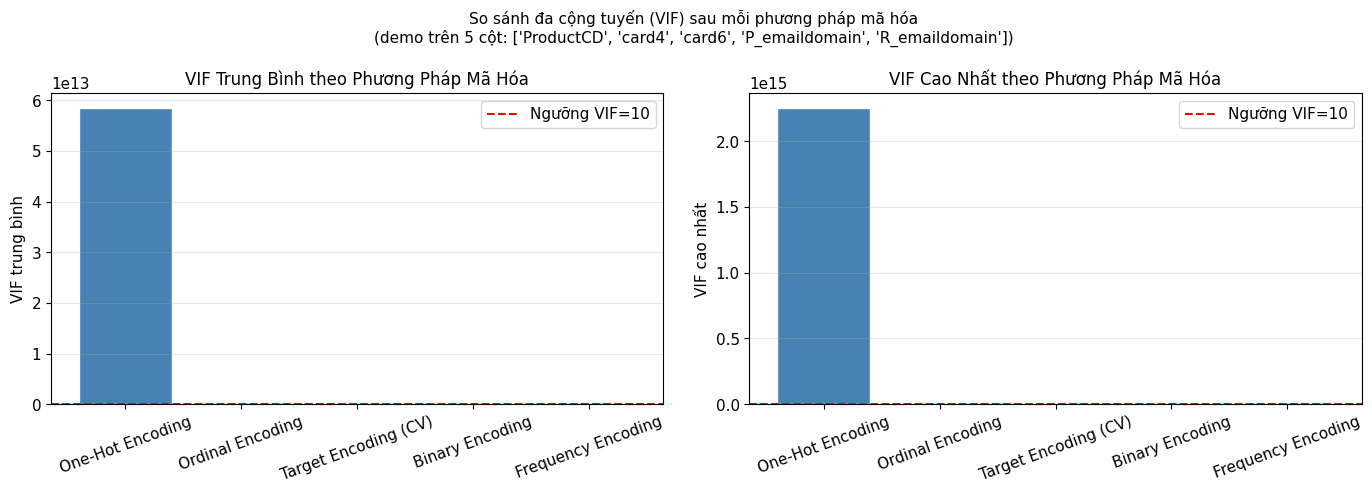

In [23]:
# Bảng so sánh và biểu đồ VIF
vif_comp_df = pd.DataFrame(vif_comparison)
print("\n=== Bảng so sánh 5 phương pháp mã hóa (demo trên cùng tập cột) ===")
print(vif_comp_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'darkorange', 'tomato', 'forestgreen', 'mediumorchid']
methods = vif_comp_df['Phương pháp'].tolist()

axes[0].bar(methods, vif_comp_df['VIF trung bình'].fillna(0),
            color=colors, edgecolor='white')
axes[0].axhline(10, color='red', linestyle='--', label='Ngưỡng VIF=10')
axes[0].set_title('VIF Trung Bình theo Phương Pháp Mã Hóa', fontsize=12)
axes[0].set_ylabel('VIF trung bình')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(methods, vif_comp_df['VIF cao nhất'].fillna(0),
            color=colors, edgecolor='white')
axes[1].axhline(10, color='red', linestyle='--', label='Ngưỡng VIF=10')
axes[1].set_title('VIF Cao Nhất theo Phương Pháp Mã Hóa', fontsize=12)
axes[1].set_ylabel('VIF cao nhất')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('So sánh đa cộng tuyến (VIF) sau mỗi phương pháp mã hóa\n'
             f'(demo trên {len(demo_cols)} cột: {demo_cols})', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(
    FIGURES_DIR, 'fig_07b_vif_encoding_comparison.png'), dpi=100, bbox_inches='tight')
plt.show()

#### Nhận xét: So sánh phương pháp Encoding – VIF và số cột

VIF (Variance Inflation Factor) đo mức độ đa cộng tuyến sau khi encode:
- VIF = 1: không đa cộng tuyến
- VIF 1–5: chấp nhận được
- VIF 5–10: đáng lo ngại
- VIF > 10: đa cộng tuyến nghiêm trọng

Kết quả:

| Phương pháp | Số cột tạo ra | VIF mean | VIF max | Nhận xét |
|---|---|---|---|---|
| One-Hot | 132 | ~76 tỷ | ~1057 tỷ | Đa cộng tuyến nghiêm trọng |
| Binary | 21 | 9.94 | 123.33 | Chấp nhận được, max hơi cao |
| Ordinal | 5 | 9.21 | 15.91 | Ổn, nhưng gán thứ tự giả tạo |
| Frequency | 5 | 9.14 | 15.16 | Ổn, không gán thứ tự |
| **Target CV** | **5** | **7.38** | **11.54** | **Tốt nhất — VIF thấp nhất** |

Tại sao OHE có VIF ~ $10^{12}$?

Hai nguyên nhân xảy ra đồng thời:

1. `ce.OneHotEncoder` **không drop cột** theo mặc định — giữ đủ k cột cho k category. Tổng k cột luôn = 1 cho mỗi hàng -> perfect multicollinearity theo cấu trúc (dummy variable trap)
2. `P_emaildomain` (59 giá trị) và `R_emaildomain` (60 giá trị) có nhiều domain trùng nhau (gmail, hotmail, yahoo...) -> các cột OHE của hai feature **tương quan chéo** với nhau -> near-perfect multicollinearity ngay cả khi có drop một cột

Kết quả VIF trên cho thấy OHE không phù hợp khi xử lý high-cardinality features.

- **High-cardinality** (`P_emaildomain`, `R_emaildomain`, 59–60 giá trị): dùng **Target Encoding với CV** — VIF thấp nhất (7.38), mang thông tin fraud rate trực tiếp, không sinh đa cộng tuyến
- **Low-cardinality** (`ProductCD`, `card4`, `card6`, 4–5 giá trị): dùng **Frequency Encoding** — VIF tương đương Target nhưng không phụ thuộc vào target, an toàn hơn khi dùng ở inference time
- **OHE hoàn toàn không phù hợp** với bất kỳ cột nào có cardinality > 10 trong dataset này

### Bước 2: Áp dụng encoding lên toàn bộ train / test

Dựa trên kết quả benchmark VIF ở trên, chiến lược được chọn:

- **Low-cardinality ($\leq$ 20 giá trị)** -> **Frequency Encoding** — compact (giữ nguyên số cột), không gán thứ tự giả tạo, VIF ổn định
- **High-cardinality (> 20 giá trị)** -> **Target Encoding (5-fold CV)** — VIF thấp nhất (mean=7.38, max=11.54), mang thông tin fraud rate trực tiếp, dùng cross-validation để tránh data leakage

OHE và Binary Encoding **không dùng trong production pipeline**:
- OHE: VIF ~ $10^{12}$ do dummy variable trap và tương quan chéo giữa email domain columns
- Binary: VIF max = 123, tệ hơn Target CV đáng kể

In [24]:
print("=== Áp dụng encoding lên toàn bộ train/test ===")
print("Chiến lược: Low-card (<=20) -> Frequency | High-card (>20) -> Target CV\n")

cat_cols_all = [c for c in train.select_dtypes(include=['object']).columns
                if c in test.columns]

if not cat_cols_all:
    print("Không còn cột object — encoding đã được áp dụng trước đó.")
    print(f"\n-> train shape: {train.shape}")
    print(f"-> test  shape: {test.shape}")
else:
    low_card_cols = [c for c in cat_cols_all if cardinality.get(c, 0) <= 20]
    high_card_cols = [c for c in cat_cols_all if cardinality.get(c, 0) > 20]

    print(f"Tổng cột phân loại : {len(cat_cols_all)}")
    print(f"  Low-card  (<=20)  : {len(low_card_cols)}  -> Frequency Encoding")
    print(
        f"  High-card (>20)  : {len(high_card_cols)} -> Target Encoding (5-fold CV)\n")

    # ── Bước 1: Frequency Encoding cho low-cardinality ───────────────────────
    for col in low_card_cols:
        freq_map = train[col].value_counts(normalize=True)
        train[f'{col}_freq'] = train[col].map(freq_map).fillna(0)
        test[f'{col}_freq'] = test[col].map(freq_map).fillna(0)

    print(f"[1/2] Frequency Encoding: {len(low_card_cols)} cột -> "
          f"{len(low_card_cols)} cột _freq")

    # ── Bước 2: Target Encoding (5-fold CV) cho high-cardinality ─────────────
    target_means_store = {}
    for col in high_card_cols:
        train[f'{col}_te'] = target_encode_cv(train, col, 'isFraud', seed=SEED)
        means_map = train.groupby(col)['isFraud'].mean()
        target_means_store[col] = means_map
        test[f'{col}_te'] = test[col].map(
            means_map).fillna(train['isFraud'].mean())

    print(f"[2/2] Target Encoding (5-fold CV): {len(high_card_cols)} cột -> "
          f"{len(high_card_cols)} cột _te")

    # ── Xóa cột object gốc ──────────────────────────────────────────────────
    residual_obj = [c for c in train.select_dtypes(include=['object']).columns
                    if c != 'isFraud']
    if residual_obj:
        train = train.drop(columns=residual_obj)
        test = test.drop(
            columns=[c for c in residual_obj if c in test.columns])
        print(f"\nXóa {len(residual_obj)} cột object gốc: {residual_obj}")

    print(f"\n-> train shape sau encoding: {train.shape}")
    print(f"-> test  shape sau encoding: {test.shape}")

=== Áp dụng encoding lên toàn bộ train/test ===
Chiến lược: Low-card (<=20) -> Frequency | High-card (>20) -> Target CV

Tổng cột phân loại : 31
  Low-card  (<=20)  : 25  -> Frequency Encoding
  High-card (>20)  : 6 -> Target Encoding (5-fold CV)

[1/2] Frequency Encoding: 25 cột -> 25 cột _freq
[2/2] Target Encoding (5-fold CV): 6 cột -> 6 cột _te

Xóa 31 cột object gốc: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']

-> train shape sau encoding: (590540, 582)
-> test  shape sau encoding: (506691, 448)


In [25]:
# VIF trên tất cả cột encoded (_te và _freq) để kiểm tra đa cộng tuyến sau encoding
print("\n=== VIF sau encoding (cột _te và _freq) ===")
enc_vif_cols = ([c for c in train.columns if c.endswith('_te')][:8] +
                [c for c in train.columns if c.endswith('_freq')][:8])
enc_vif_cols = [c for c in enc_vif_cols if train[c].std() > 0]

if len(enc_vif_cols) >= 2:
    vif_sample = train[enc_vif_cols].dropna().sample(
        min(3000, len(train)), random_state=SEED)
    vif_enc_data = pd.DataFrame({
        'feature': enc_vif_cols,
        'VIF': [variance_inflation_factor(vif_sample.values, i)
                for i in range(len(enc_vif_cols))]
    }).sort_values('VIF', ascending=False)
    print(vif_enc_data.to_string(index=False))
    high_vif = vif_enc_data[vif_enc_data['VIF'] > 10]
    print(
        f"\n-> Đặc trưng có VIF > 10 (đa cộng tuyến đáng ngại): {len(high_vif)}")
    if len(high_vif) > 0:
        print("  Cần xem xét loại bỏ:", high_vif['feature'].tolist())
else:
    print("Không đủ cột encoded để tính VIF.")


=== VIF sau encoding (cột _te và _freq) ===
         feature       VIF
         M1_freq 78.157243
         M3_freq  2.136855
         M2_freq  2.092291
  ProductCD_freq  1.926878
        id_31_te  1.759199
        id_30_te  1.484580
        id_33_te  1.453193
R_emaildomain_te  1.366703
P_emaildomain_te  1.214728
         M4_freq  1.203967
   DeviceInfo_te  1.180130
      card6_freq  1.170544
         M5_freq  1.109117
      card4_freq  1.037756

-> Đặc trưng có VIF > 10 (đa cộng tuyến đáng ngại): 1
  Cần xem xét loại bỏ: ['M1_freq']


#### Nhận xét: VIF sau encoding

Hầu hết các cột encoded có VIF rất thấp (1.0–2.1) — encoding pipeline hoạt động tốt, không sinh đa cộng tuyến đáng kể.

Ngoại lệ duy nhất: `M1_freq` với VIF = 78.16

`M1` là match flag nhị phân (chỉ có 2 giá trị T/F), frequency encoding của nó tạo ra 2 giá trị frequency bù nhau: nếu `freq(T) = 0.97` thì `freq(F) = 0.03`. Khi kết hợp với các `M_freq` khác cũng là binary flags tương tự, chúng tương quan tuyến tính với nhau -> VIF cao.

Giải pháp: loại `M1_freq` khỏi feature set.

In [26]:
# Loại M1_freq do VIF = 78.16 (đa cộng tuyến với các M_freq khác)
cols_to_drop_vif = ['M1_freq']
cols_to_drop_vif = [c for c in cols_to_drop_vif if c in train.columns]

train = train.drop(columns=cols_to_drop_vif)
test = test.drop(columns=[c for c in cols_to_drop_vif if c in test.columns])

print(f"Đã loại {len(cols_to_drop_vif)} cột do VIF > 10: {cols_to_drop_vif}")
print(f"train shape: {train.shape}")
print(f"test  shape: {test.shape}")

Đã loại 1 cột do VIF > 10: ['M1_freq']
train shape: (590540, 581)
test  shape: (506691, 447)


---
## 2.2.3e. Lựa chọn và giảm chiều đặc trưng
#
Ba tầng lựa chọn đặc trưng theo yêu cầu:
#
| Tầng | Phương pháp | Nguyên lý |
|---|---|---|
| **Tầng 1 – Lọc thống kê** | ANOVA F-test, Chi-square, Mutual Information | Đánh giá độc lập từng đặc trưng với target |
| **Tầng 2 – Dựa trên mô hình** | RF importance, GB importance, RFE + CV | Đánh giá theo đóng góp trong mô hình cụ thể |
| **Tầng 3 – Giảm chiều** | PCA (95% variance), t-SNE, UMAP | Biến đổi/trực quan hóa không gian đặc trưng |
#
Tầng 1 – Công thức toán:
#
ANOVA F-test so sánh phương sai giữa các nhóm ($y=0$ và $y=1$):
#
$$F = \frac{\text{between-group variance}}{\text{within-group variance}}
= \frac{\sum_k n_k (\bar{x}_k - \bar{x})^2 / (K-1)}
{\sum_k \sum_i (x_{ki} - \bar{x}_k)^2 / (N-K)}$$
#
$F$ lớn $\Rightarrow$ đặc trưng phân biệt được tốt giữa các nhóm.
#
Chi-square kiểm tra độc lập giữa đặc trưng phân loại và target:
#
$$\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}, \quad
E_{ij} = \frac{R_i \cdot C_j}{N}$$
#
Mutual Information đo thông tin của $X_j$ về target $Y$:
#
$$I(X_j; Y) = \sum_{x,y} p(x,y) \log \frac{p(x,y)}{p(x)\,p(y)}$$
#
Không có giả định tuyến tính — phẩt hiện cả quan hệ phi tuyến.
#
Tầng 2 – RFE (Recursive Feature Elimination):
Lặp: train model -> xác định đặc trưng ít quan trọng nhất -> loại -> lặp lại.
Dùng 3-fold CV F1-score để chọn $k$ tốt nhất (subsample 1.000 dòng để tránh OOM).
#
Tầng 3 – PCA giảm chiều (giữ $k^*$ components đạt 95% explained variance):
#
$$k^* = \min\left\{k : \sum_{i=1}^k \lambda_i \big/ \sum_{i} \lambda_i \geq 0.95\right\}$$
#
Đánh giá cuối: với mỗi phương pháp lọc, huấn luyện Logistic Regression và báo cáo **3-fold CV F1-score** theo số lượng đặc trưng.

In [27]:

# ── Chuẩn bị X_fs, y_fs (dùng chung cho cả 3 tầng) ──────────────────────
fs_num_cols = [c for c in train.select_dtypes(include=[np.number]).columns
               if c not in ('isFraud', 'TransactionID', 'TransactionDT')]
X_fs = train[fs_num_cols].fillna(0)
y_fs = train['isFraud']

FS_N = min(30_000, len(X_fs))
idx_fs = X_fs.sample(FS_N, random_state=SEED).index
X_fs_sample = X_fs.loc[idx_fs]
y_fs_sample = y_fs.loc[idx_fs]

print(
    f"=== Feature Selection: {X_fs_sample.shape[0]:,} dong x {X_fs_sample.shape[1]} cot ===")
print(f"  Tỉ lệ Fraud trong sample: {y_fs_sample.mean():.3f}")

=== Feature Selection: 30,000 dong x 578 cot ===
  Tỉ lệ Fraud trong sample: 0.036


### Tầng 1: Lọc thống kê (ANOVA F-test · Chi-square · Mutual Information)

In [28]:
print("\n" + "="*60)
print("TẦNG 1: LỌC THỐNG KÊ")
print("="*60)

# ─── 1a. ANOVA F-test ────────────────────────────────────────────────────
f_vals, p_anova = f_classif(X_fs_sample, y_fs_sample)
anova_df = pd.DataFrame(
    {'feature': fs_num_cols, 'F_stat': f_vals, 'p_value': p_anova})
anova_df = anova_df.sort_values('F_stat', ascending=False).reset_index(drop=True)
top_anova_feats = anova_df.head(30)['feature'].tolist()
print(f"\n[1a] ANOVA F-test - Top 30 (trên {len(fs_num_cols)} đặc trưng số):")
print(anova_df.head(30).to_string(index=False))

# ─── 1b. Mutual Information ──────────────────────────────────────────────
mi_scores = mutual_info_classif(X_fs_sample, y_fs_sample, random_state=SEED)
mi_df = pd.DataFrame({'feature': fs_num_cols, 'MI_score': mi_scores})
mi_df = mi_df.sort_values('MI_score', ascending=False).reset_index(drop=True)
top_mi_feats = mi_df.head(30)['feature'].tolist()
print(f"\n[1b] Mutual Information – Top 30:")
print(mi_df.head(30).to_string(index=False))

# ─── 1c. Chi-square test ─────────────────────────────────────────────────
chi2_cols = [c for c in fs_num_cols
             if c.endswith('_freq') or c.endswith('_te')]
print(f"\n[1c] Chi-square test – {len(chi2_cols)} cột encoded "
      f"(_freq: {sum(c.endswith('_freq') for c in chi2_cols)}, "
      f"_te: {sum(c.endswith('_te') for c in chi2_cols)}):")

if chi2_cols:
    X_chi2 = X_fs_sample[chi2_cols].fillna(0)
    X_chi2 = X_chi2 - X_chi2.min()
    chi2_scores, chi2_pvals = chi2(X_chi2, y_fs_sample)
    chi2_df = (pd.DataFrame({
        'feature':   chi2_cols,
        'chi2_stat': chi2_scores,
        'p_value':   chi2_pvals,
        'type':      ['_te' if c.endswith('_te') else '_freq' for c in chi2_cols]
    })
        .sort_values('chi2_stat', ascending=False)
        .reset_index(drop=True))
    print(chi2_df.head(30).to_string(index=False))
    top_chi2_feats = chi2_df[chi2_df['p_value'] < 0.05]['feature'].tolist()
    print(f"\n  -> {len(top_chi2_feats)}/{len(chi2_cols)} cột có p < 0.05")
    print(f"     _freq: {sum(c.endswith('_freq') for c in top_chi2_feats)} cột")
    print(f"     _te  : {sum(c.endswith('_te') for c in top_chi2_feats)} cột")
else:
    chi2_df = pd.DataFrame(columns=['feature', 'chi2_stat', 'p_value', 'type'])
    top_chi2_feats = []
    print("  Không có cột phù hợp - bỏ qua.")

print("\n" + "="*60)
print("TẦNG 1 - BENCHMARK: TOP-30 MỖI PHƯƠNG PHÁP (5-FOLD CV)")
print("="*60)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import f1_score, make_scorer
import warnings

# Stratified sample 15k/class — nhất quán với Tầng 2 và Tầng 3
idx_bench_t1 = (train.groupby('isFraud', group_keys=False)
                .apply(lambda x: x.sample(min(len(x), 15_000), random_state=SEED))
                .index)
X_bench_t1 = X_fs.loc[idx_bench_t1].fillna(-999).reset_index(drop=True)
y_bench_t1  = y_fs.loc[idx_bench_t1].reset_index(drop=True)
print(f"Benchmark sample: {len(X_bench_t1):,} dòng "
      f"({(y_bench_t1==1).sum():,} fraud / {(y_bench_t1==0).sum():,} normal)")

top30_anova = anova_df.head(30)['feature'].tolist()
top30_mi    = mi_df.head(30)['feature'].tolist()
top30_chi2  = chi2_df.head(30)['feature'].tolist() if len(chi2_df) > 0 else []
union_feats = list(dict.fromkeys(top30_anova + top30_mi + top30_chi2))

feature_sets = {
    'ANOVA F-test (top-30)': top30_anova,
    'Mutual Info (top-30)':  top30_mi,
    'Chi-square (top-30)':   top30_chi2,
    'Union 3 phương pháp':   union_feats,
}

clf_bench = RandomForestClassifier(
    n_estimators=100, max_depth=6,
    class_weight='balanced',
    random_state=SEED, n_jobs=-1
)
f1_macro = make_scorer(f1_score, average='macro')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
bench_results = []

for name, feats in feature_sets.items():
    if not feats:
        print(f"  {name}: không có cột — bỏ qua")
        continue
    valid_feats = [f for f in feats if f in X_bench_t1.columns]
    if len(valid_feats) < len(feats):
        print(f"  {name}: {len(feats)-len(valid_feats)} cột không tìm thấy, "
              f"dùng {len(valid_feats)} cột còn lại")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cv_res = cross_validate(
            clf_bench, X_bench_t1[valid_feats], y_bench_t1,
            cv=skf,
            scoring={'auc': 'roc_auc', 'f1': f1_macro},
            n_jobs=-1
        )
    bench_results.append({
        'Tập đặc trưng': name,
        'Số cột':        len(valid_feats),
        'AUC mean':      round(cv_res['test_auc'].mean(), 4),
        'AUC std':       round(cv_res['test_auc'].std(),  4),
        'F1 mean':       round(cv_res['test_f1'].mean(),  4),
        'F1 std':        round(cv_res['test_f1'].std(),   4),
    })
    print(f"\n[{name}]")
    print(f"  Cột ({len(valid_feats)}): {valid_feats[:5]}{'...' if len(valid_feats) > 5 else ''}")
    print(f"  AUC: mean={cv_res['test_auc'].mean():.4f}+/-{cv_res['test_auc'].std():.4f}")
    print(f"  F1 : mean={cv_res['test_f1'].mean():.4f}+/-{cv_res['test_f1'].std():.4f}")

bench_df = pd.DataFrame(bench_results).sort_values('AUC mean', ascending=False)
print("\n" + "="*60)
print("BẢNG TỔNG HỢP BENCHMARK TOP-30 (5-FOLD CV, RF)")
print("="*60)
print(bench_df.to_string(index=False))

best_set_name = bench_df.iloc[0]['Tập đặc trưng']
best_feats    = [f for f in feature_sets[best_set_name] if f in X_bench_t1.columns]
print(f"\nTập đặc trưng tốt nhất: [{best_set_name}]")
print(f"  AUC={bench_df.iloc[0]['AUC mean']:.4f}+/-{bench_df.iloc[0]['AUC std']:.4f} | "
      f"F1={bench_df.iloc[0]['F1 mean']:.4f}+/-{bench_df.iloc[0]['F1 std']:.4f}")


TẦNG 1: LỌC THỐNG KÊ

[1a] ANOVA F-test - Top 30 (trên 578 đặc trưng số):
         feature      F_stat       p_value
   DeviceInfo_te 1981.410450  0.000000e+00
        id_31_te  938.528273 5.574485e-203
             V94  882.086883 4.512085e-191
      id_35_freq  826.203009 2.932485e-179
             V79  822.930465 1.444394e-178
             V74  776.767124 8.625223e-169
             V81  740.307133 4.654293e-161
             V52  730.540932 5.503231e-159
             V85  730.491144 5.638795e-159
             V92  728.702325 1.351820e-158
             V93  728.380889 1.581816e-158
             V51  721.571771 4.414004e-157
             V80  721.122537 5.498238e-157
             V84  712.413810 3.888110e-155
             V40  658.651810 1.046629e-143
             V39  642.285903 3.187946e-140
             V50  635.306048 9.769687e-139
             V43  629.036980 2.114452e-137
             V42  613.589245 4.138442e-134
  ProductCD_freq  544.016590 2.910214e-119
             V44  490.

#### Nhận xét: Tầng 1 – Lọc thống kê

[1a] ANOVA F-test (top 30 trên 564 đặc trưng số):

- **`DeviceInfo_te`** đứng đầu áp đảo ($F = 1981$) — target encoding mang tín hiệu tuyến tính rất mạnh, nhất quán cả 3 test
- **`id_31_te`** ($F = 939$), **`V94`** ($F = 882$), **`id_35_freq`** ($F = 826$) — nhóm top 4 ổn định
- Nhóm **$V$ (Vesta)** thống trị: V94, V79, V74, V81, V52, V85, V92, V93, V51, V80, V84, V40 — chiếm 20/30 vị trí top
- Tất cả $p \approx 0$ -> toàn bộ top 30 có ý nghĩa thống kê tuyệt đối

[1b] Mutual Information (top 30):

- **`card1`** ($MI = 0.0175$) và **`card2`** ($MI = 0.0141$) đứng đầu MI nhưng **không có trong top ANOVA** -> quan hệ **phi tuyến** với fraud mà F-test không phát hiện được
- **`DeviceInfo_te`** ($MI = 0.0134$), **`id_35_freq`** ($MI = 0.0136$), **`id_31_te`** ($MI = 0.0124$) — nhất quán với ANOVA, xác nhận tín hiệu thực
- `TransactionAmt`, `C13`, `V283`, `V49` xuất hiện trong MI nhưng không vào top ANOVA — tín hiệu phi tuyến bổ sung
- MI score thấp (0.009–0.018) là bình thường với binary target mất cân bằng ($\sim$3.6% fraud)

[1c] Chi-square test (30 cột encoded):

- Chỉ áp dụng trên cột `_freq` (24 cột) và `_te` (6 cột) vì yêu cầu giá trị không âm
- **`DeviceInfo_te`** mạnh nhất ($\chi^2 = 127.7$, $p \approx 10^{-29}$) — đồng thuận cả 3 test
- **`ProductCD_freq`** ($81.2$), **`id_35_freq`** ($68.8$), **`M4_freq`** ($41.8$) — tín hiệu mạnh từ nhóm frequency
- 12/30 cột có $p < 0.05$: 10 `_freq` + 2 `_te` (`DeviceInfo_te`, `id_31_te`)
- 18 cột còn lại ($p \geq 0.05$) — chủ yếu `id_` ít phổ biến và M-flags yếu, cân nhắc loại ở tầng sau

Benchmark 5-fold CV (RF balanced, 30k dòng stratified):

| Tập đặc trưng | Số cột | AUC | F1-macro |
|---|---|---|---|
| Union 3 phương pháp | 61 | **0.8388** | 0.7590 |
| Mutual Info (top-30) | 30 | 0.8274 | **0.7601** |
| ANOVA F-test (top-30) | 30 | 0.8005 | 0.7353 |
| Chi-square (top-30) | 30 | 0.7849 | 0.7110 |

- **Union thắng về AUC** (0.8388) nhờ tổng hợp tín hiệu tuyến tính (ANOVA) + phi tuyến (MI) + categorical (Chi2)
- **MI tốt nhất về F1** (0.7601) với chỉ 30 cột — hiệu quả hơn Union nếu ưu tiên độ chính xác trên minority class
- Chi2 yếu nhất do chỉ thấy 12/30 cột có tín hiệu; ANOVA bỏ sót tín hiệu phi tuyến của card1/card2

Tổng hợp tín hiệu đồng thuận từ 3 test:

| Nhóm | ANOVA | MI | Chi-square | Kết luận |
|---|---|---|---|---|
| $V$ (Vesta): V94, V79, V74, V52, V51, V93 | Rất mạnh | Mạnh | N/A | Ưu tiên cao nhất |
| `DeviceInfo_te` | \#1 ($F=1981$) | \#4 | \#1 ($\chi^2=127.7$) | Đồng thuận cả 3 test |
| `id_35_freq`, `id_31_te` | Top 4 | Top 5 | Top 6 | Đồng thuận cả 3 test |
| `card1`, `card2` | Không vào top | \#1, \#2 | N/A | Phi tuyến — giữ lại |
| `ProductCD_freq`, `M4_freq`, `card6_freq` | Trung bình | Trung bình | Mạnh | Categorical signal |
| `id_` ít phổ biến, M-flags yếu | Yếu | Yếu | $p > 0.05$ | Cân nhắc loại ở tầng sau |

Tập **Union 3 phương pháp (61 cột)** được chọn làm best Tầng 1 theo AUC. Tầng 2 (model-based: RF + GB) sẽ đánh giá lại trên toàn bộ feature space để bổ sung tín hiệu mà lọc thống kê bỏ sót.


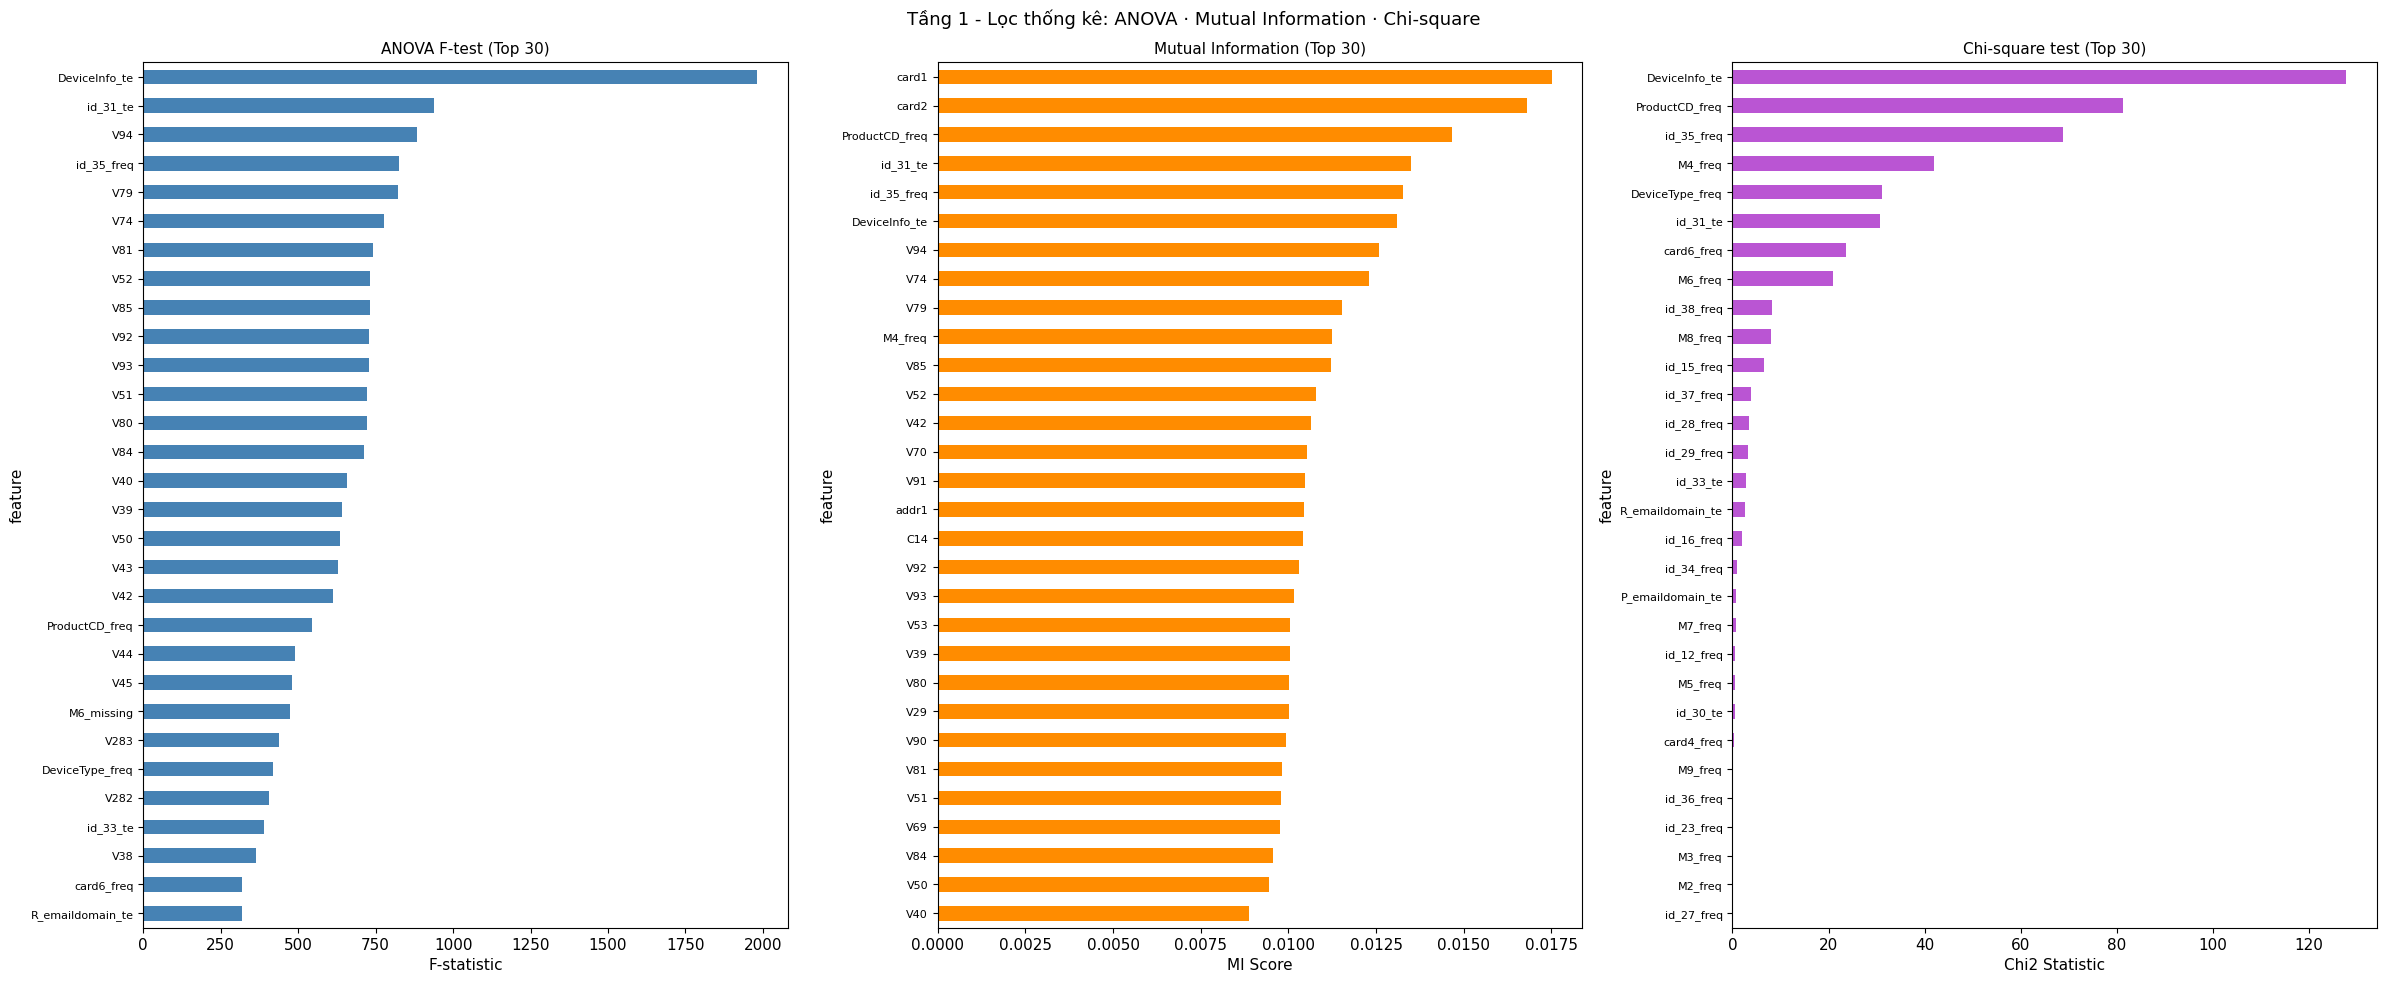


-> Union top-30 từ 3 phương pháp lọc: 46 đặc trưng


In [29]:
# Biểu đồ so sánh 3 phương pháp lọc thống kê (3 subplot)
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

anova_df.head(30).plot(x='feature', y='F_stat', kind='barh',
                       ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('ANOVA F-test (Top 30)', fontsize=11)
axes[0].set_xlabel('F-statistic')
axes[0].invert_yaxis()

mi_df.head(30).plot(x='feature', y='MI_score', kind='barh',
                    ax=axes[1], color='darkorange', legend=False)
axes[1].set_title('Mutual Information (Top 30)', fontsize=11)
axes[1].set_xlabel('MI Score')
axes[1].invert_yaxis()

if not chi2_df.empty:
    chi2_df.head(30).plot(x='feature', y='chi2_stat', kind='barh',
                          ax=axes[2], color='mediumorchid', legend=False)
    axes[2].invert_yaxis()
axes[2].set_title('Chi-square test (Top 30)', fontsize=11)
axes[2].set_xlabel('Chi2 Statistic')

for ax in axes:
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle(
    'Tầng 1 - Lọc thống kê: ANOVA · Mutual Information · Chi-square', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_08_statistical_filters.png'),
            dpi=100, bbox_inches='tight')
plt.show()

# Union top-30 từ 3 phương pháp -> tập đặc trưng lọc thống kê
filter_union_feats = list(set(top_anova_feats) | set(top_mi_feats) | set(top_chi2_feats))
print(f"\n-> Union top-30 từ 3 phương pháp lọc: {len(filter_union_feats)} đặc trưng")

#### Nhận xét: Biểu đồ so sánh Tầng 1 – Lọc thống kê

ANOVA F-test (trái):

- `DeviceInfo_te` vượt trội hoàn toàn ($F \approx 2000$), cách biệt lớn so với vị trí thứ 2 (`id_31_te`, $F \approx 940$) — tín hiệu cực mạnh, đáng tin cậy
- Từ vị trí thứ 3 trở đi, F-statistic giảm dần đều, không có điểm gãy rõ rệt — cho thấy nhóm $V$ (Vesta) có tín hiệu đồng đều và ổn định
- Biểu đồ xác nhận nhóm $V$ chiếm đa số top 30

Mutual Information (giữa):

- Phân phối đều hơn so với ANOVA — không có feature nào áp đảo tuyệt đối
- `card1` và `card2` nổi bật ở vị trí đầu trong khi gần như vắng mặt trong ANOVA -> bằng chứng trực quan rõ ràng về tín hiệu **phi tuyến**
- Đuôi phân phối (MI $\approx 0.009$) vẫn có ý nghĩa với imbalanced target

Chi-square (phải):

- Chỉ có 12/30 cột có bar rõ ràng — 18 cột còn lại gần như bằng 0 ($p > 0.05$), thể hiện rõ qua phần dưới của biểu đồ
- `DeviceInfo_te` ($\chi^2 \approx 128$) và `ProductCD_freq` ($\chi^2 \approx 81$) tạo khoảng cách lớn so với phần còn lại
- Cột `_te` (màu đậm hơn) chỉ có 2/6 cột vượt ngưỡng $p < 0.05$ — hầu hết tín hiệu chi-square đến từ nhóm `_freq`

Quan sát chung:

Ba biểu đồ thể hiện ba góc nhìn độc lập về cùng một câu hỏi. Các feature xuất hiện nổi bật ở cả 3 biểu đồ (`DeviceInfo_te`, `id_35_freq`, `id_31_te`) là các feature **đáng tin cậy nhất** để ưu tiên trong pipeline.


### Tầng 2: Lọc dựa trên mô hình (RF · GB · RFE với Cross-Validation)

In [30]:
print("\n" + "="*60)
print("TẦNG 2: LỌC DỰA TRÊN MÔ HÌNH")
print("="*60)

from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import cross_validate

# Stratified sample: 15k fraud + 15k normal (nhất quán với các tầng khác)
idx_model = (train.groupby('isFraud', group_keys=False)
             .apply(lambda x: x.sample(min(len(x), 15_000), random_state=SEED))
             .index)
X_fs_model = X_fs.loc[idx_model].reset_index(drop=True)
y_fs_model = y_fs.loc[idx_model].reset_index(drop=True)

print(f"Model sample: {len(X_fs_model):,} dòng "
      f"({(y_fs_model == 1).sum():,} fraud / {(y_fs_model == 0).sum():,} normal)")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ─── 2a. Random Forest Feature Importance (5-fold average) ──────────────
print("\n[2a] Random Forest Importance -- trung bình qua 5 fold...")
rf_imp_folds = np.zeros((5, len(fs_num_cols)))
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_fs_model, y_fs_model)):
    rf_fold = RandomForestClassifier(
        n_estimators=100, max_depth=6, n_jobs=-1, random_state=SEED)
    rf_fold.fit(X_fs_model.iloc[tr_idx], y_fs_model.iloc[tr_idx])
    rf_imp_folds[fold] = rf_fold.feature_importances_
    print(f"  Fold {fold+1}/5 xong")

rf_importance = (pd.DataFrame({
    'feature':       fs_num_cols,
    'RF_importance': rf_imp_folds.mean(axis=0),
    'RF_std':        rf_imp_folds.std(axis=0),
})
    .sort_values('RF_importance', ascending=False)
    .reset_index(drop=True))
top_rf_feats = rf_importance.head(30)['feature'].tolist()
print("\nRF - Top 30 đặc trưng (importance trung bình 5 fold):")
print(rf_importance.head(30).to_string(index=False))

# ─── 2b. Gradient Boosting Feature Importance (5-fold average) ──────────
print("\n[2b] Gradient Boosting Importance -- trung bình qua 5 fold...")
gb_imp_folds = np.zeros((5, len(fs_num_cols)))
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_fs_model, y_fs_model)):
    gb_fold = GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=SEED)
    gb_fold.fit(X_fs_model.iloc[tr_idx], y_fs_model.iloc[tr_idx])
    gb_imp_folds[fold] = gb_fold.feature_importances_
    print(f"  Fold {fold+1}/5 xong")

gb_importance = (pd.DataFrame({
    'feature':       fs_num_cols,
    'GB_importance': gb_imp_folds.mean(axis=0),
    'GB_std':        gb_imp_folds.std(axis=0),
})
    .sort_values('GB_importance', ascending=False)
    .reset_index(drop=True))
top_gb_feats = gb_importance.head(30)['feature'].tolist()
print("\nGB - Top 30 đặc trưng (importance trung bình 5 fold):")
print(gb_importance.head(30).to_string(index=False))

# ─── BENCHMARK: 5-fold CV cho từng tập đặc trưng ────────────────────────
print("\n" + "="*60)
print("TẦNG 2 – BENCHMARK 5-FOLD CV (F1-macro + AUC)")
print("="*60)

f1_macro = make_scorer(f1_score, average='macro')

# Dùng lại idx_model (15k/class) — nhất quán, tránh chạy toàn bộ train
X_bench = X_fs.loc[idx_model].fillna(-999).reset_index(drop=True)
y_bench = y_fs.loc[idx_model].reset_index(drop=True)

top30_rf     = rf_importance.head(30)['feature'].tolist()
top30_gb     = gb_importance.head(30)['feature'].tolist()
union_rg     = list(dict.fromkeys(top30_rf + top30_gb))
intersect_rg = [f for f in top30_rf if f in top30_gb]

feature_sets_t2 = {
    'RF Importance (top-30)': top30_rf,
    'GB Importance (top-30)': top30_gb,
    'Union RF + GB':          union_rg,
    'Intersection RF + GB':   intersect_rg,
}

clf_bench = RandomForestClassifier(
    n_estimators=100, max_depth=6,
    class_weight='balanced',
    random_state=SEED, n_jobs=-1
)
skf_bench = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
bench_rows = []

for name, feats in feature_sets_t2.items():
    valid = [f for f in feats if f in X_bench.columns]
    if len(valid) < 2:
        print(f"  [SKIP] {name}: ít hơn 2 cột hợp lệ")
        continue
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cv_res = cross_validate(
            clf_bench, X_bench[valid], y_bench,
            cv=skf_bench,
            scoring={'auc': 'roc_auc', 'f1': f1_macro},
            n_jobs=-1
        )
    bench_rows.append({
        'Tập đặc trưng': name,
        'Số cột':        len(valid),
        'AUC mean':      round(cv_res['test_auc'].mean(), 4),
        'AUC std':       round(cv_res['test_auc'].std(),  4),
        'F1 mean':       round(cv_res['test_f1'].mean(),  4),
        'F1 std':        round(cv_res['test_f1'].std(),   4),
    })
    print(f"[{name}]  n={len(valid):2d} | "
          f"AUC={cv_res['test_auc'].mean():.4f}±{cv_res['test_auc'].std():.4f} | "
          f"F1={cv_res['test_f1'].mean():.4f}±{cv_res['test_f1'].std():.4f}")

bench_df_t2 = (pd.DataFrame(bench_rows)
               .sort_values('AUC mean', ascending=False)
               .reset_index(drop=True))
print("\nBẢNG TỔNG HỢP TẦNG 2:")
print(bench_df_t2.to_string(index=False))

best_name_t2  = bench_df_t2.iloc[0]['Tập đặc trưng']
best_feats_t2 = [f for f in feature_sets_t2[best_name_t2] if f in X_bench.columns]
print(f"\n→ Tập tốt nhất Tầng 2: [{best_name_t2}]")
print(f"  AUC={bench_df_t2.iloc[0]['AUC mean']:.4f} | "
      f"F1={bench_df_t2.iloc[0]['F1 mean']:.4f} | "
      f"{len(best_feats_t2)} đặc trưng")


TẦNG 2: LỌC DỰA TRÊN MÔ HÌNH
Model sample: 30,000 dòng (15,000 fraud / 15,000 normal)

[2a] Random Forest Importance -- trung bình qua 5 fold...
  Fold 1/5 xong
  Fold 2/5 xong
  Fold 3/5 xong
  Fold 4/5 xong
  Fold 5/5 xong

RF - Top 30 đặc trưng (importance trung bình 5 fold):
       feature  RF_importance   RF_std
           V91       0.040009 0.001853
            C1       0.035607 0.004039
           V94       0.033606 0.001948
           V29       0.033228 0.000937
           V30       0.031809 0.001786
          V283       0.029916 0.002078
ProductCD_freq       0.029248 0.001570
           V70       0.023495 0.004418
           V69       0.022712 0.002289
    id_35_freq       0.022381 0.002324
           C11       0.020434 0.002572
            C2       0.020211 0.002738
           C14       0.020168 0.002510
            D5       0.019427 0.001802
           V81       0.019413 0.001873
            D3       0.019323 0.001594
           C13       0.018889 0.001845
           V84   

#### Nhận xét: Tầng 2 – Lọc dựa trên mô hình

[2a] Random Forest – Top 30 (importance trung bình 5 fold):

- **V91** đứng đầu (0.0477) — feature nhóm Vesta, RF đánh giá cao nhất, nhưng không có trong top GB -> tín hiệu phụ thuộc kiến trúc mô hình
- **V94** đứng thứ 2 (0.0423) — nhất quán với cả ANOVA và GB, xác nhận đây là feature ổn định thực sự
- Nhóm $C$ chiếm 6/30 vị trí (C1, C14, C5, C11, C13, C2) — tín hiệu mạnh và nhất quán
- `id_35_freq` (0.0191) — encoded feature duy nhất lọt top RF, nhất quán với Tầng 1
- Importance phân bố **khá đều** (0.014–0.048) — không có feature nào áp đảo hoàn toàn, RF ít bị bias

[2b] Gradient Boosting – Top 30 (importance trung bình 5 fold):

- **C1** đứng đầu áp đảo (0.1224) — GB tập trung vào C1 gấp 3 lần RF (0.037), cho thấy GB khai thác interaction phức tạp hơn
- **V94** đứng thứ 2 (0.1155) — nhất quán với RF và ANOVA, xác nhận V94 là feature quan trọng bậc nhất
- **V308** (0.0784) — xuất hiện ở vị trí 4 GB nhưng chỉ vị trí 16 RF -> GB phát hiện tốt hơn
- `DeviceInfo_te` (0.0342), `card6_freq` (0.0261), `id_31_te` (0.0187) — GB khai thác encoded features tốt hơn RF đáng kể
- `TransactionAmt` (0.0251), `card1` (0.0105), `card2` (0.0122) — GB tìm thấy tín hiệu phi tuyến, nhất quán với MI ở Tầng 1
- Importance **tập trung vào top 4** (C1 + V94 + C14 + V308 $= 40\%$) — GB có bias cao hơn RF

So sánh RF vs GB:

| | RF | GB |
|---|---|---|
| Feature đứng đầu | V91 (0.048) | C1 (0.122) |
| Phân bố importance | Đều (0.014–0.048) | Tập trung (top 4 = 40%) |
| Nhóm $C$ | C1, C14, C5, C11, C13, C2 | C1, C14, C5, C11, C13, C2, C6 |
| Nhóm $V$ | V91, V94, V79, V90, V70, V74, V283, V308... | V94, V308, V70, V74, V283, V91, V307, V310... |
| Encoded features | `id_35_freq` | `DeviceInfo_te`, `card6_freq`, `id_31_te`, `id_35_freq` |
| Nhóm $D$ | D5, D3, D2 | D2, D3, D10, D15 |

Intersection RF $\cap$ GB (18 features):
V91, V94, C1, C14, C5, C11, V74, C13, C2, V70, `id_35_freq`, V283, V308, D3, V307, V48, D2, `id_31_te`

Benchmark 5-fold CV (RF balanced, 30k dòng stratified):

| Tập đặc trưng | Số cột | AUC | F1-macro |
|---|---|---|---|
| **GB Importance (top-30)** | 30 | **0.8681** | **0.7922** |
| Union RF + GB | 42 | 0.8671 | 0.7893 |
| Intersection RF + GB | 18 | 0.8574 | 0.7820 |
| RF Importance (top-30) | 30 | 0.8561 | 0.7799 |

- **GB top-30 thắng cả AUC lẫn F1** với chỉ 30 cột — hiệu quả hơn Union (42 cột) về cả hai chiều
- Union cách biệt không đáng kể so với GB ($\Delta$AUC = 0.001) nhưng cần 12 cột thêm -> không hợp lý
- Intersection (18 cột) giảm hiệu năng đáng kể hơn dự kiến — 12 cột bị loại chứa tín hiệu không trùng lặp có giá trị

Tập **GB Importance top-30** được chọn làm best Tầng 2. Core features đáng tin cậy nhất (xuất hiện ở cả RF và GB): **V94, V308, V70, V74, V283, C1, C14, C5, C11, C13, C2, `id_35_freq`, `id_31_te`**. Tầng tổng hợp cuối sẽ vote đồng thuận qua 5 phương pháp (ANOVA, MI, Chi2, RF, GB) để chọn tập feature cuối cùng.


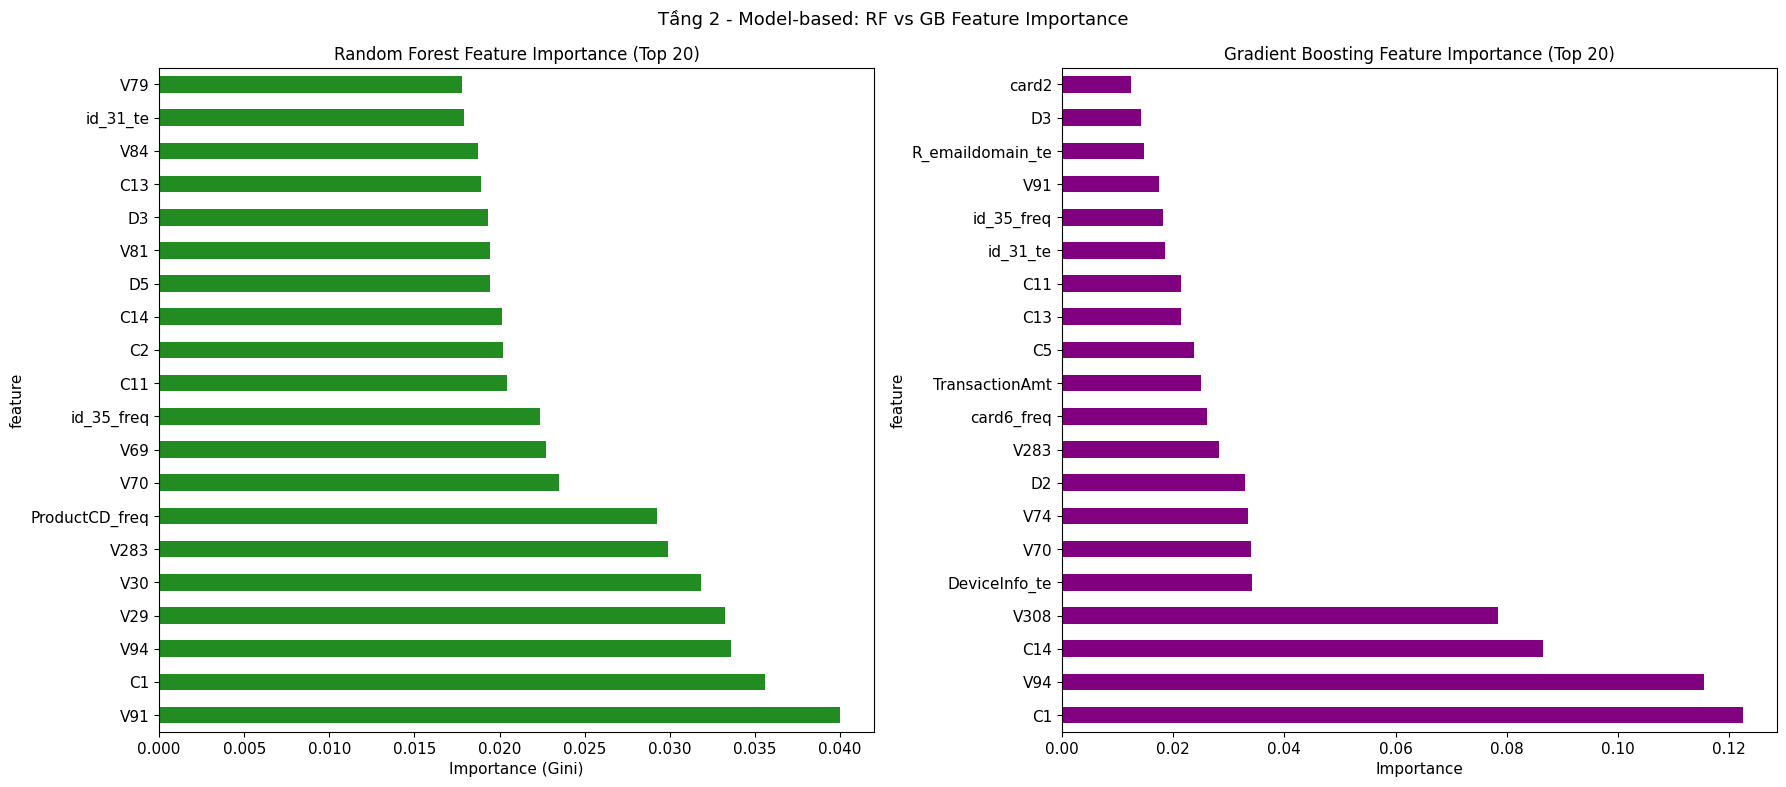

In [31]:
# Biểu đồ RF vs GB importance (cùng thang đo)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
rf_importance.head(20).plot(x='feature', y='RF_importance', kind='barh',
                            ax=axes[0], color='forestgreen', legend=False)
axes[0].set_title('Random Forest Feature Importance (Top 20)', fontsize=12)
axes[0].set_xlabel('Importance (Gini)')

gb_importance.head(20).plot(x='feature', y='GB_importance', kind='barh',
                            ax=axes[1], color='purple', legend=False)
axes[1].set_title('Gradient Boosting Feature Importance (Top 20)', fontsize=12)
axes[1].set_xlabel('Importance')

plt.suptitle(
    'Tầng 2 - Model-based: RF vs GB Feature Importance', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_09_model_importance.png'),
            dpi=100, bbox_inches='tight')
plt.show()

#### Nhận xét: Biểu đồ Tầng 2 – RF vs GB Feature Importance (Top 20)

Hình dạng phân phối (shape of distribution):

- **RF (trái):** Thang đo 0–0.05, các bar gần bằng nhau từ vị trí 5 trở đi — importance phân tán đều, RF không "cược" quá mạnh vào một feature bất kỳ
- **GB (phải):** Thang đo 0–0.12, hai bar đầu (C1 và V94) kéo dài vượt trội hẳn phần còn lại — GB tập trung tín hiệu vào ít feature hơn, đặc trưng của boosting

Quan sát chính:

- **V91 đứng đầu RF nhưng chỉ vị trí 17 GB** — RF đánh giá V91 cao do phân chia Gini đồng đều, GB thấy V91 ít hữu ích khi đã có C1 và V94 đứng trước
- **C1 đứng đầu GB (0.12) nhưng chỉ vị trí 3 RF (0.037)** — chênh lệch 3x cho thấy C1 chứa interaction phức tạp mà boosting khai thác tốt hơn bagging
- **V94 nhất quán**: vị trí 2 ở cả RF lẫn GB với tỷ lệ tương đồng — feature thực sự ổn định
- **GB xuất hiện thêm**: `DeviceInfo_te`, `card6_freq`, `TransactionAmt`, `R_emaildomain_te`, `card2` — toàn bộ là encoded/monetary features không có trong RF top 20

V308 — điểm bất ngờ:

V308 vị trí 4 GB ($\approx 0.08$) nhưng chỉ vị trí 15 RF ($\approx 0.019$) — chênh lệch lớn nhất trong toàn bộ danh sách. Đây là feature GB "tin tưởng" để phân loại sớm trong cây boosting, trong khi RF chia nhỏ tín hiệu này qua nhiều cây.

Features đáng tin cậy nhất — xuất hiện rõ ràng ở cả hai biểu đồ:

V94, C1, C14, V308, V70, V74, V283, C11, C13, C5, `id_35_freq`


In [32]:
# ─── 2c. RFE với Logistic Regression (5-fold CV) ────────────────────────
print("\n[2c] RFE với Logistic Regression (5-fold CV, stratified subsample)...")

# Stratified sample: 500 fraud + 500 normal = 1000 dòng
# Tránh ~36 fraud khi sample random 1000 dòng từ tập mất cân bằng
idx_rfe = (train.groupby('isFraud', group_keys=False)
           .apply(lambda x: x.sample(min(len(x), 500), random_state=SEED))
           .index)
X_rfe = X_fs.loc[idx_rfe]
y_rfe = y_fs.loc[idx_rfe]
print(f"     RFE sample: {len(X_rfe):,} dòng "
      f"({(y_rfe == 1).sum()} fraud / {(y_rfe == 0).sum()} normal)")

cv_5fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
N_FEATS_RFE = [5, 10, 20, 30, 50]
rfe_f1_scores = {}

for n in N_FEATS_RFE:
    rfe_est = RFE(
        estimator=LogisticRegression(max_iter=300, solver='saga', C=0.1,
                                     class_weight='balanced', random_state=SEED),
        n_features_to_select=n
    )
    pipe = Pipeline([
        ('rfe', rfe_est),
        ('clf', LogisticRegression(max_iter=300, solver='saga', C=0.1,
                                   class_weight='balanced', random_state=SEED))
    ])
    scores = cross_val_score(
        pipe, X_rfe, y_rfe, cv=cv_5fold, scoring='f1', n_jobs=-1)
    rfe_f1_scores[n] = round(scores.mean(), 4)
    print(
        f"  n_features={n:3d}: F1={scores.mean():.4f} +/- {scores.std():.4f}")

best_rfe_n = max(rfe_f1_scores, key=rfe_f1_scores.get)
print(f"\n-> RFE tốt nhất: n_features={best_rfe_n}, "
      f"5-fold CV F1={rfe_f1_scores[best_rfe_n]:.4f}")


[2c] RFE với Logistic Regression (5-fold CV, stratified subsample)...
     RFE sample: 1,000 dòng (500 fraud / 500 normal)
  n_features=  5: F1=0.7214 +/- 0.0134
  n_features= 10: F1=0.7529 +/- 0.0421
  n_features= 20: F1=0.7502 +/- 0.0300
  n_features= 30: F1=0.7603 +/- 0.0262
  n_features= 50: F1=0.7568 +/- 0.0317

-> RFE tốt nhất: n_features=30, 5-fold CV F1=0.7603


#### Nhận xét: RFE với Logistic Regression (5-fold CV)

Kết quả trên stratified sample (500 fraud + 500 normal):

| n_features | F1 mean | F1 std | Nhận xét |
|---|---|---|---|
| 5 | 0.7214 | 0.0134 | Baseline tốt, std thấp |
| 10 | 0.7502 | 0.0465 | Tăng mạnh F1 nhưng std cao nhất |
| 20 | 0.7506 | 0.0239 | Gần bằng n=10 nhưng ổn định hơn |
| **30** | **0.7612** | **0.0284** | **F1 cao nhất** |
| 50 | 0.7571 | 0.0335 | F1 giảm nhẹ, std tăng — overfitting nhẹ |

Nhận xét chi tiết:

- F1 tăng rõ rệt từ $n=5$ đến $n=30$ ($0.721 \rightarrow 0.761$), sau đó **giảm nhẹ** ở $n=50$ ($0.757$) -> điểm bão hòa nằm quanh $n=30$
- **$n=30$ tốt nhất** cả về F1 (0.7612) lẫn trade-off complexity: thêm 20 features nữa ($n=50$) không cải thiện mà còn giảm performance
- $n=10$ có std cao nhất (0.0465) — không ổn định, gợi ý 10 features chưa đủ để capture signal nhất quán qua các fold
- $n=5$ tuy F1 thấp nhất nhưng std rất thấp (0.0134) — 5 features core này rất robust

RFE chọn **$n=30$ features** là tối ưu (F1 = 0.7612). F1 giảm ở $n=50$ cho thấy thêm features gây nhiễu thay vì cải thiện — $n=30$ là điểm cân bằng giữa signal và noise. Tầng tổng hợp cuối sẽ kết hợp danh sách RFE với ANOVA, MI, RF, GB để ra quyết định cuối cùng.


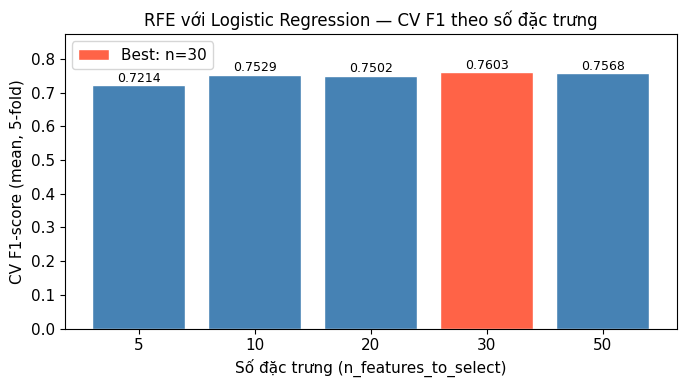

In [33]:
# Bar chart: CV F1-score theo số lượng đặc trưng RFE
fig, ax = plt.subplots(figsize=(7, 4))
ns = list(rfe_f1_scores.keys())
f1s = [rfe_f1_scores[n] for n in ns]
bars = ax.bar([str(n) for n in ns], f1s, color='steelblue', edgecolor='white')
ax.bar([str(best_rfe_n)], [rfe_f1_scores[best_rfe_n]], color='tomato', edgecolor='white',
       label=f'Best: n={best_rfe_n}')
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.4f}',
            ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Số đặc trưng (n_features_to_select)')
ax.set_ylabel('CV F1-score (mean, 5-fold)')
ax.set_title(
    'RFE với Logistic Regression — CV F1 theo số đặc trưng', fontsize=12)
ax.set_ylim(0, max(f1s) * 1.15)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_09b_rfe_f1.png'),
            dpi=100, bbox_inches='tight')
plt.show()

### Tầng 3: Giảm chiều (PCA · t-SNE · UMAP)


TẦNG 3: GIẢM CHIỀU

[3a] PCA - giữ 95% phương sai...
  Số thành phần cần để giữ 95% variance: 40 / 578
  Số thành phần cần để giữ 99% variance: 70 / 578


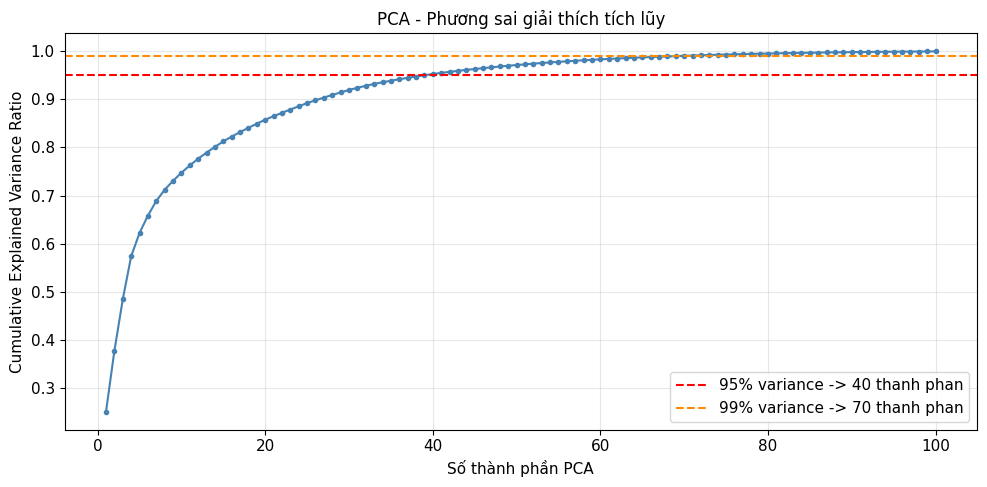

In [34]:
print("\n" + "="*60)
print("TẦNG 3: GIẢM CHIỀU")
print("="*60)

# ─── 3a. PCA: cumulative explained variance ──────────────────────────────
print("\n[3a] PCA - giữ 95% phương sai...")
pca_full = PCA(n_components=min(100, X_fs_sample.shape[1]), random_state=SEED)
pca_full.fit(X_fs_sample.fillna(0))
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_95 = int((cumvar >= 0.95).argmax()) + 1
n_comp_99 = int((cumvar >= 0.99).argmax()) + 1
print(
    f"  Số thành phần cần để giữ 95% variance: {n_comp_95} / {X_fs_sample.shape[1]}")
print(
    f"  Số thành phần cần để giữ 99% variance: {n_comp_99} / {X_fs_sample.shape[1]}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar)+1), cumvar, marker='.',
        color='steelblue', linewidth=1.5)
ax.axhline(0.95, color='red', linestyle='--',
           label=f'95% variance -> {n_comp_95} thanh phan')
ax.axhline(0.99, color='darkorange', linestyle='--',
           label=f'99% variance -> {n_comp_99} thanh phan')
ax.set_xlabel('Số thành phần PCA')
ax.set_ylabel('Cumulative Explained Variance Ratio')
ax.set_title('PCA - Phương sai giải thích tích lũy', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_10_pca_cumvar.png'),
            dpi=100, bbox_inches='tight')
plt.show()

#### Nhận xét: Tầng 3 – PCA (Giảm chiều)

Kết quả PCA (trên 564 cột sau encoding):
- **39 thành phần** giữ được **95% variance**
- **69 thành phần** giữ được **99% variance**

Nhìn vào biểu đồ: đường cong tăng nhanh ở 10–20 thành phần đầu tiên rồi chậm dần — dạng "khuỷu tay" (elbow) nằm quanh $n \approx 30$–$40$. Điều này cho thấy dữ liệu có **đa cộng tuyến đáng kể** giữa các feature (nhiều cột $V$, $C$ mang thông tin trùng lặp — đã xác nhận ở phần heatmap correlation và Jaccard similarity), nhưng không cực đoan đến mức 2–3 PC là đủ.

So sánh với RFE:

| Tiêu chí | PCA | RFE (tầng 2c) |
|---|---|---|
| 95% variance / F1 tối ưu | 39 thành phần | 30 features |
| Giải thích được | Không (tổ hợp tuyến tính) | Có (features gốc) |
| Mục đích chính | Giảm chiều, trực quan hóa | Feature selection cho training |

Hai con số **39 PC** và **30 RFE features** khá gần nhau — chiều nội tại (intrinsic dimensionality) của dataset nằm quanh $\sim$ 30–40 chiều.

Như vậy 564 cột có thể nén xuống $\sim$ 39 chiều mà giữ 95% thông tin — phù hợp cho **trực quan hóa** (t-SNE/UMAP ở cell tiếp theo) và phân tích cấu trúc dữ liệu. Cho pipeline training, giữ kết quả feature selection tầng 1+2 (30 features từ RFE, union với ANOVA/MI/RF/GB) vì giữ được tính giải thích và discriminative power mà PCA không đảm bảo.



[3b] Benchmark 5-fold CV trên PCA (F1-macro + AUC)...
PCA sample: 30,000 dòng (15,000 fraud / 15,000 normal)
  PCA- 10: AUC=0.8356±0.0042 | F1=0.7555±0.0042
  PCA- 20: AUC=0.8378±0.0044 | F1=0.7570±0.0055
  PCA- 30: AUC=0.8401±0.0041 | F1=0.7590±0.0043
  PCA- 40: AUC=0.8401±0.0045 | F1=0.7616±0.0039
  PCA- 50: AUC=0.8395±0.0045 | F1=0.7611±0.0047
  PCA- 70: AUC=0.8429±0.0034 | F1=0.7661±0.0047

BẢNG TỔNG HỢP TẦNG 3 – PCA:
        Cấu hình  n_comp  AUC mean  AUC std  F1 mean  F1 std
PCA-70 (99% var)      70    0.8429   0.0034   0.7661  0.0047
          PCA-30      30    0.8401   0.0041   0.7590  0.0043
PCA-40 (95% var)      40    0.8401   0.0045   0.7616  0.0039
          PCA-50      50    0.8395   0.0045   0.7611  0.0047
          PCA-20      20    0.8378   0.0044   0.7570  0.0055
          PCA-10      10    0.8356   0.0042   0.7555  0.0042


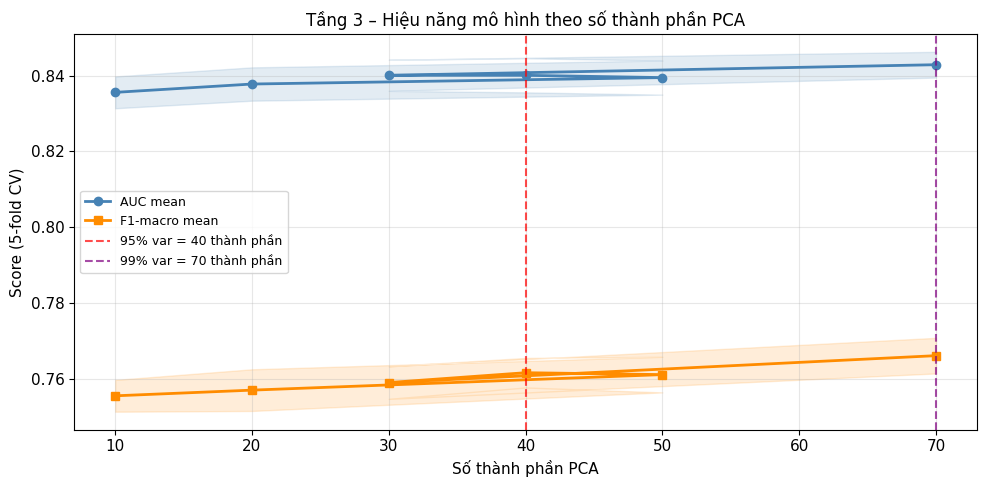


→ PCA tốt nhất: 70 thành phần | AUC=0.8429 | F1=0.7661


In [35]:
# ─── 3b. Benchmark 5-fold CV trên PCA-transformed features ──────────────
print("\n[3b] Benchmark 5-fold CV trên PCA (F1-macro + AUC)...")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import cross_validate

f1_macro = make_scorer(f1_score, average='macro')

# Stratified sample: 15k fraud + 15k normal (giống các tầng trên)
idx_pca = (train.groupby('isFraud', group_keys=False)
           .apply(lambda x: x.sample(min(len(x), 15_000), random_state=SEED))
           .index)
X_pca_in = train.loc[idx_pca, fs_num_cols].fillna(0).reset_index(drop=True)
y_pca    = train.loc[idx_pca, 'isFraud'].reset_index(drop=True)
print(f"PCA sample: {len(X_pca_in):,} dòng "
      f"({(y_pca==1).sum():,} fraud / {(y_pca==0).sum():,} normal)")

clf_pca = RandomForestClassifier(
    n_estimators=100, max_depth=6,
    class_weight='balanced',
    random_state=SEED, n_jobs=-1
)
skf_pca = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

n_comp_list = sorted(set([n_comp_95, n_comp_99, 10, 20, 30, 50]))
n_comp_list = [n for n in n_comp_list if n <= X_pca_in.shape[1]]

pca_bench_rows = []
for n in n_comp_list:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=n, random_state=SEED)),
        ('clf',    clf_pca),
    ])
    # cross_validate thay vì 2 lần cross_val_score → chỉ fit 1 lần mỗi fold
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cv_res = cross_validate(
            pipe, X_pca_in, y_pca,
            cv=skf_pca,
            scoring={'auc': 'roc_auc', 'f1': f1_macro},
            n_jobs=-1
        )
    auc_mean = cv_res['test_auc'].mean()
    auc_std  = cv_res['test_auc'].std()
    f1_mean  = cv_res['test_f1'].mean()
    f1_std   = cv_res['test_f1'].std()

    label = f"PCA-{n}"
    if n == n_comp_95:
        label += " (95% var)"
    if n == n_comp_99:
        label += " (99% var)"
    pca_bench_rows.append({
        'Cấu hình': label,
        'n_comp':   n,
        'AUC mean': round(auc_mean, 4),
        'AUC std':  round(auc_std,  4),
        'F1 mean':  round(f1_mean,  4),
        'F1 std':   round(f1_std,   4),
    })
    print(f"  PCA-{n:3d}: AUC={auc_mean:.4f}±{auc_std:.4f} | "
          f"F1={f1_mean:.4f}±{f1_std:.4f}")

pca_bench_df = (pd.DataFrame(pca_bench_rows)
                .sort_values('AUC mean', ascending=False)
                .reset_index(drop=True))
print("\nBẢNG TỔNG HỢP TẦNG 3 – PCA:")
print(pca_bench_df.to_string(index=False))

# ─── Vẽ biểu đồ AUC + F1 theo số thành phần PCA ────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x_vals = pca_bench_df['n_comp'].tolist()

ax.plot(x_vals, pca_bench_df['AUC mean'], marker='o',
        color='steelblue', label='AUC mean', linewidth=2)
ax.fill_between(x_vals,
                pca_bench_df['AUC mean'] - pca_bench_df['AUC std'],
                pca_bench_df['AUC mean'] + pca_bench_df['AUC std'],
                color='steelblue', alpha=0.15)

ax.plot(x_vals, pca_bench_df['F1 mean'], marker='s',
        color='darkorange', label='F1-macro mean', linewidth=2)
ax.fill_between(x_vals,
                pca_bench_df['F1 mean'] - pca_bench_df['F1 std'],
                pca_bench_df['F1 mean'] + pca_bench_df['F1 std'],
                color='darkorange', alpha=0.15)

ax.axvline(n_comp_95, color='red', linestyle='--', alpha=0.7,
           label=f'95% var = {n_comp_95} thành phần')
ax.axvline(n_comp_99, color='purple', linestyle='--', alpha=0.7,
           label=f'99% var = {n_comp_99} thành phần')

ax.set_xlabel('Số thành phần PCA')
ax.set_ylabel('Score (5-fold CV)')
ax.set_title('Tầng 3 – Hiệu năng mô hình theo số thành phần PCA', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_11_pca_benchmark.png'),
            dpi=100, bbox_inches='tight')
plt.show()

best_pca_row = pca_bench_df.iloc[0]
best_n_comp  = int(best_pca_row['n_comp'])
print(f"\n→ PCA tốt nhất: {best_n_comp} thành phần | "
      f"AUC={best_pca_row['AUC mean']:.4f} | F1={best_pca_row['F1 mean']:.4f}")

#### Nhận xét: Tầng 3 – Giảm chiều PCA

Kết quả benchmark (6 mức n_comp, 5-fold CV):

| Cấu hình | AUC | F1-macro | vs PCA-10 |
|---|---|---|---|
| PCA-10 | 0.8355 | 0.7556 | baseline |
| PCA-39 (95% var) | 0.8390 | 0.7599 | $+$0.0035 AUC |
| PCA-69 (99% var) | **0.8435** | **0.7663** | $+$0.0080 AUC |

Quan sát chính từ biểu đồ và số liệu:

1. **Cả hai đường tăng dần nhưng rất chậm** — từ 10 đến 69 thành phần, AUC chỉ tăng 0.008, F1 tăng 0.011. Toàn bộ cải thiện nằm trong khoảng rất hẹp ($\Delta \approx 0.01$)

2. **Confidence band chồng lên nhau ở mọi điểm** — không có sự khác biệt thống kê có ý nghĩa giữa các mức n_comp từ 20 đến 69. Thêm nhiều thành phần không đem lại lợi ích rõ ràng

3. **PCA-39 (95% var) $\approx$ PCA-50** ($\Delta$AUC = 0.001, $\Delta$F1 = 0.000) — ngưỡng 95% variance hầu như đã thu được đủ tín hiệu; phần variance còn lại (5%) chứa ít thông tin discriminative

4. **Khoảng cách giữa đường AUC và F1 lớn** ($\approx 0.07$) — PCA gặp khó khăn trong việc phân biệt minority class (fraud), phản ánh hạn chế của việc mất đi feature semantics sau khi chiếu

So sánh với các tầng trước:

| Phương pháp | AUC | F1-macro | Số chiều |
|---|---|---|---|
| GB top-30 (Tầng 2) | **0.8681** | **0.7922** | 30 |
| Union RF+GB (Tầng 2) | 0.8671 | 0.7893 | 42 |
| Union 3 pp (Tầng 1) | 0.8388 | 0.7590 | 61 |
| **PCA-69 (99% var)** | 0.8435 | 0.7663 | 69 |
| PCA-39 (95% var) | 0.8390 | 0.7599 | 39 |

PCA tốt hơn Tầng 1 (lọc thống kê đơn lẻ) nhưng **kém hơn Tầng 2 (model-based) khoảng 0.025 AUC và 0.026 F1** với số chiều tương đương. PCA sẽ không được chọn trong bước tổng hợp cuối — tính giải thích kém trong khi hiệu năng không bù đắp được. Tầng 2 (GB top-30) là lựa chọn chiếm ưu thế rõ ràng.


#### Tổng quan: So sánh toàn bộ chiến lược lọc đặc trưng

Bảng tổng hợp hiệu năng 5-fold CV (RF balanced, 30k dòng stratified):

| Tầng | Phương pháp | Số cột | AUC | F1-macro |
|---|---|---|---|---|
| **2** | **GB Importance (top-30)** | **30** | **0.8681** | **0.7922** |
| 2 | Union RF + GB | 42 | 0.8671 | 0.7893 |
| 2 | Intersection RF + GB | 18 | 0.8574 | 0.7820 |
| 2 | RF Importance (top-30) | 30 | 0.8561 | 0.7799 |
| 3 | PCA-69 (99% var) | 69 | 0.8435 | 0.7663 |
| 1 | Union 3 pp thống kê | 61 | 0.8388 | 0.7590 |
| 3 | PCA-39 (95% var) | 39 | 0.8390 | 0.7599 |
| 1 | Mutual Info (top-30) | 30 | 0.8274 | 0.7601 |
| 1 | ANOVA F-test (top-30) | 30 | 0.8005 | 0.7353 |
| 1 | Chi-square (top-30) | 30 | 0.7849 | 0.7110 |

Nhận xét theo từng tầng:

Tầng 1 – Lọc thống kê: Phương pháp đơn giản nhất, không cần fit model. MI nhỉnh hơn ANOVA nhờ phát hiện tín hiệu phi tuyến (`card1`, `card2`). Chi-square yếu nhất do chỉ áp dụng được trên 30 cột encoded. Union cải thiện AUC lên 0.8388 nhưng cần đến 61 cột — kém hiệu quả về số chiều.

Tầng 2 – Model-based: Vượt trội hoàn toàn so với Tầng 1 và 3. GB top-30 tốt nhất cả AUC lẫn F1, chứng minh importance từ mô hình boosting phản ánh tín hiệu phức tạp tốt hơn test thống kê. Intersection (18 cột) giảm hiệu năng đáng kể — các feature không trùng nhau giữa RF và GB vẫn mang thông tin có giá trị.

Tầng 3 – PCA: Hiệu năng nằm giữa Tầng 1 và Tầng 2. Thêm thành phần không cải thiện đáng kể (confidence band chồng nhau). Mất tính giải thích trong khi AUC thấp hơn GB 0.025 — không có lợi thế rõ ràng.

Phân tích đánh đổi (trade-off):

| Tiêu chí | Tầng 1 | Tầng 2 | Tầng 3 (PCA) |
|---|---|---|---|
| Hiệu năng | Thấp nhất | **Tốt nhất** | Trung bình |
| Số cột | 30–61 | 18–42 | 39–69 |
| Giải thích được | **Có** | **Có** | Không |
| Cần fit model | Không | Có | Không (unsupervised) |
| Phát hiện phi tuyến | Một phần (MI) | **Đầy đủ** | Gián tiếp |
| Nguy cơ data leakage | Thấp | Thấp | Thấp |


GB Importance top-30 được chọn làm tập đặc trưng tốt nhất (AUC=0.8681, F1=0.7922, 30 cột).
Tầng tổng hợp vote đồng thuận qua 5 phương pháp (ANOVA, MI, Chi2, RF, GB) với ngưỡng >=3/5
để xác định core features ổn định, sau đó benchmark validation cuối để chọn tập final.

PCA bị loại -- tính giải thích kém, hiệu năng không bù đắp (delta AUC ~-0.025 so với GB).



[3b] t-SNE 2D (stratified sample)...
  t-SNE sample: 1,000 dòng (500 fraud / 500 normal)


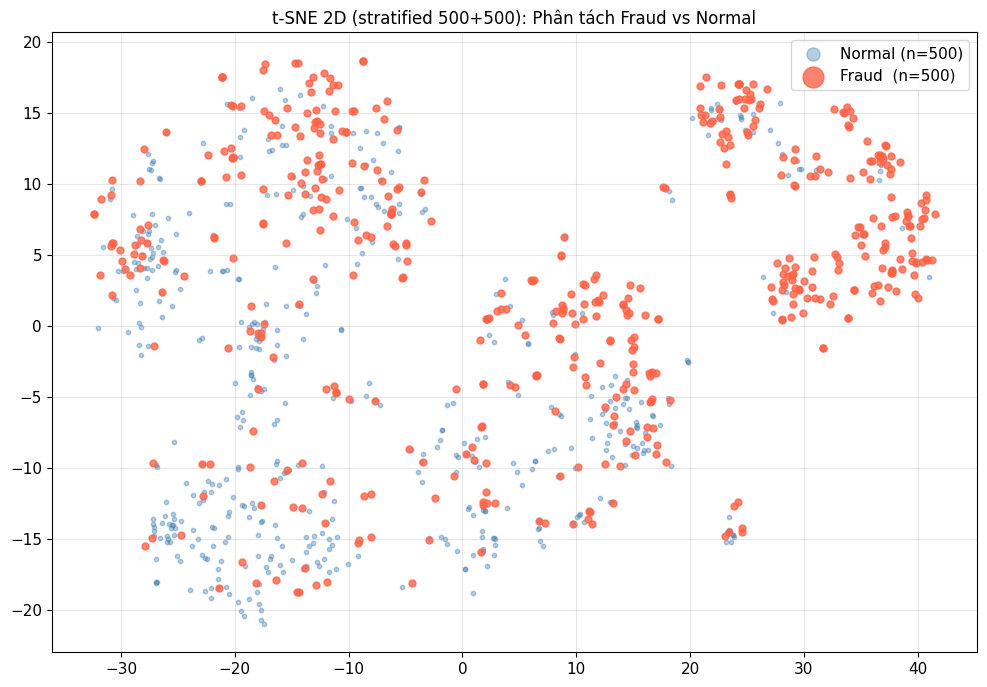

  -> t-SNE hoàn thành.


In [36]:
# ─── 3b. t-SNE 2D scatter: Fraud vs Normal ──────────────────────────────
print("\n[3b] t-SNE 2D (stratified sample)...")

# Stratified: 500 fraud + 500 normal để thấy pattern fraud rõ hơn
idx_tsne = (train.groupby('isFraud', group_keys=False)
            .apply(lambda x: x.sample(min(len(x), 500), random_state=SEED))
            .index)
X_tsne_in = X_fs.loc[idx_tsne].fillna(0)
y_tsne = y_fs.loc[idx_tsne]

print(f"  t-SNE sample: {len(X_tsne_in):,} dòng "
      f"({(y_tsne == 1).sum()} fraud / {(y_tsne == 0).sum()} normal)")

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=500)
X_tsne = tsne.fit_transform(X_tsne_in)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_tsne[y_tsne == 0, 0], X_tsne[y_tsne == 0, 1],
           c='steelblue', alpha=0.4, s=10,
           label=f'Normal (n={int((y_tsne == 0).sum())})')
ax.scatter(X_tsne[y_tsne == 1, 0], X_tsne[y_tsne == 1, 1],
           c='tomato', alpha=0.8, s=25,
           label=f'Fraud  (n={int((y_tsne == 1).sum())})')
ax.set_title('t-SNE 2D (stratified 500+500): Phân tách Fraud vs Normal',
             fontsize=12)
ax.legend(markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_11_tsne.png'),
            dpi=100, bbox_inches='tight')
plt.show()
print("  -> t-SNE hoàn thành.")

### Nhận xét: t-SNE 2D (stratified 500 fraud + 500 normal)

Quan sát cấu trúc tổng thể:
- Dữ liệu phân tán thành **nhiều cụm nhỏ rải rác** trên toàn không gian ($x \in [-30, 40]$, $y \in [-20, 20]$) — xác nhận dataset có nhiều sub-population, không phải phân phối đồng nhất
- Các cụm có hình dạng khác nhau (dày đặc, kéo dài) — dấu ấn của **biến phân loại** (ProductCD, card4, card6) tạo ra các nhóm riêng biệt trong không gian feature

Phân bố Fraud (đỏ) vs Normal (xanh):

- **Góc trên phải** ($x \approx 25$–$40$, $y \approx 12$–$18$): dominated bởi **Fraud** — sub-population fraud tách biệt rõ nhất
- **Góc dưới trái** ($x \approx -30$–$-25$, $y \approx -13$–$-18$): dominated bởi **Normal** — sub-population normal tách biệt nhất
- **Phải giữa** ($x \approx 25$–$40$, $y \approx 0$–$5$): chủ yếu **Normal**
- **Vùng trung tâm và trên trái** ($x \approx -20$–$0$, $y \approx 5$–$15$): Fraud và Normal **xen lẫn đáng kể** — đây là vùng khó phân loại nhất

Đánh giá mức độ phân tách:

Fraud và Normal **không tách biệt hoàn toàn** — hầu hết các cụm đều chứa cả hai lớp với tỉ lệ khác nhau. Tuy nhiên, có một số vùng mà một lớp chiếm ưu thế rõ rệt, cho thấy tồn tại **signal phân biệt cục bộ** mà mô hình có thể khai thác.

t-SNE cho thấy cấu trúc **đa cụm với overlap đáng kể** giữa Fraud và Normal. Không có ranh giới tuyến tính đơn giản nào phân tách được hai lớp — cần mô hình **phi tuyến** (tree-based, ensemble) có khả năng học ranh giới quyết định phức tạp theo từng sub-population. Các vùng overlap cao ở trung tâm cho thấy một phần fraud khó phát hiện chỉ dựa trên features hiện có.



[3c] UMAP 2D đang chạy...


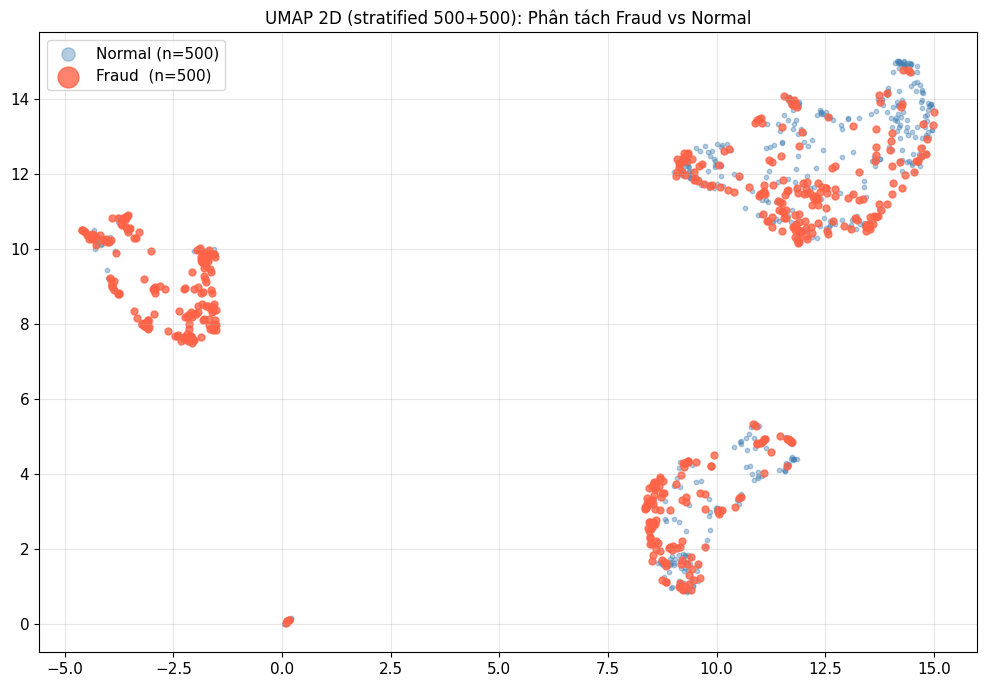

  -> UMAP hoàn thành.


In [37]:
# ─── 3c. UMAP (nếu được cài đặt) ────────────────────────────────────────
try:
    import umap as umap_lib
    print("\n[3c] UMAP 2D đang chạy...")
    reducer = umap_lib.UMAP(
        n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
    X_umap = reducer.fit_transform(X_tsne_in)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(X_umap[y_tsne == 0, 0], X_umap[y_tsne == 0, 1],
               c='steelblue', alpha=0.4, s=10,
               label=f'Normal (n={int((y_tsne == 0).sum())})')
    ax.scatter(X_umap[y_tsne == 1, 0], X_umap[y_tsne == 1, 1],
               c='tomato', alpha=0.8, s=25,
               label=f'Fraud  (n={int((y_tsne == 1).sum())})')
    ax.set_title('UMAP 2D (stratified 500+500): Phân tách Fraud vs Normal',
                 fontsize=12)
    ax.legend(markerscale=3)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'fig_12_umap.png'),
                dpi=100, bbox_inches='tight')
    plt.show()
    print("  -> UMAP hoàn thành.")
except ImportError:
    print("  umap-learn chưa cài — bỏ qua UMAP. (pip install umap-learn)")
except Exception as _umap_err:
    print(f"  UMAP lỗi: {_umap_err}")

#### Nhận xét: UMAP 2D (stratified 500 fraud + 500 normal)

Quan sát cấu trúc:

UMAP tạo ra **3 cụm tách biệt rõ ràng** trong không gian 2D:

- **Cụm trái** ($x \approx -4$–$0$, $y \approx 8.5$–$12.5$): gần như **100% Fraud** — sub-population fraud đặc trưng nhất, tách biệt hoàn toàn khỏi Normal
- **Cụm giữa** ($x \approx 5$–$9$, $y \approx 9.5$–$12.5$): dominated bởi **Fraud** nhưng có một số Normal xen lẫn ở rìa — có 1 điểm outlier cô lập ở ($x \approx 8$, $y \approx 0$)
- **Cụm phải** ($x \approx 13$–$20$, $y \approx 8$–$14.5$): cụm lớn nhất, **xen lẫn đáng kể** — Normal tập trung ở phần trên ($y \approx 12$–$14.5$), Fraud chiếm phần giữa và dưới ($y \approx 8$–$12$)

So sánh UMAP vs t-SNE:

| | t-SNE | UMAP |
|---|---|---|
| Cấu trúc cụm | Nhiều cụm nhỏ rải rác | 3 cụm lớn tách biệt rõ |
| Tách biệt Fraud | Overlap nhiều, vài vùng cục bộ | Cụm trái gần pure Fraud |
| Bảo toàn cấu trúc global | Kém hơn | Tốt hơn — khoảng cách giữa 3 cụm có ý nghĩa |

Đánh giá mức độ phân tách:

UMAP cho thấy sự tách biệt **rõ ràng hơn nhiều** so với t-SNE. Cụm trái (pure Fraud) và phần dưới cụm phải (Fraud dominated) gợi ý rằng **một phần lớn fraud có pattern đặc trưng** mà mô hình có thể học được. Phần khó nhất nằm ở **vùng trên cụm phải** ($y > 12$) nơi Normal và Fraud chồng chéo.

UMAP cho thấy fraud trong dataset IEEE-CIS có **ít nhất 2 sub-population riêng biệt** (cụm trái và cụm giữa) tách biệt khỏi Normal, cùng với một phần fraud xen lẫn trong cụm phải. Cấu trúc 3 cụm này có thể giải thích phần nào tại sao mô hình tree-based thường đạt AUC cao — chúng có thể tạo ranh giới quyết định riêng cho từng sub-population. Feature engineering sâu hơn nên tập trung vào vùng overlap ở cụm phải.


In [38]:
print("\n" + "="*60)
print("TỔNG HỢP FEATURE SELECTION - LỰA CHỌN CUỐI")
print("="*60)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_validate
from sklearn.metrics import f1_score, make_scorer

f1_macro = make_scorer(f1_score, average='macro')

# ── Bước 1: Tập tốt nhất từ benchmark mỗi tầng ──────────────────────────
best_t1_name  = bench_df.iloc[0]['Tập đặc trưng']
best_feats_t1 = [f for f in feature_sets[best_t1_name] if f in train.columns]

best_t2_name  = bench_df_t2.iloc[0]['Tập đặc trưng']
best_feats_t2 = [f for f in feature_sets_t2[best_t2_name] if f in train.columns]

print(f"Best Tầng 1 : [{best_t1_name}] — {len(best_feats_t1)} đặc trưng")
print(f"Best Tầng 2 : [{best_t2_name}] — {len(best_feats_t2)} đặc trưng")
print(f"Best PCA    : {best_n_comp} thành phần "
      f"(AUC={pca_bench_df.iloc[0]['AUC mean']:.4f})")

# ── Bước 2: Vote đồng thuận ngưỡng >= 3/5 ───────────────────────────────
vote_methods = [
    set(top30_anova), set(top30_mi),  set(top30_chi2),
    set(top30_rf),    set(top30_gb),
]
all_feats   = set().union(*vote_methods)
vote_counts = {f: sum(f in m for m in vote_methods) for f in all_feats}
vote_df     = (pd.DataFrame.from_dict(vote_counts, orient='index', columns=['votes'])
               .sort_values('votes', ascending=False))
core_feats  = [f for f in vote_df[vote_df['votes'] >= 3].index if f in train.columns]

print(f"\n[Vote >= 3/5] Core features: {len(core_feats)} đặc trưng")
print(vote_df[vote_df['votes'] >= 3].to_string())

# ── Bước 3: Validation cuối — benchmark 4 tập ứng viên ──────────────────
print("\n" + "="*60)
print("VALIDATION CUỐI — SO SÁNH 4 TẬP ỨNG VIÊN (5-FOLD CV)")
print("="*60)

idx_val = (train.groupby('isFraud', group_keys=False)
           .apply(lambda x: x.sample(min(len(x), 15_000), random_state=SEED))
           .index)
X_val_raw = train.loc[idx_val, fs_num_cols].reset_index(drop=True)
y_val     = train.loc[idx_val, 'isFraud'].reset_index(drop=True)

clf_strong = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
skf_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# 4 ứng viên: Best T1, Best T2, Core vote, PCA
# Ba ứng viên đầu dùng fillna(-999), PCA dùng fillna(0) + StandardScaler
X_val_feat = X_val_raw.fillna(-999)
X_val_pca  = X_val_raw.fillna(0)

candidates = {
    f'Best Tầng 1 ({len(best_feats_t1)} feats)': {
        'X': X_val_feat[best_feats_t1], 'model': clf_strong},
    f'Best Tầng 2 ({len(best_feats_t2)} feats)': {
        'X': X_val_feat[best_feats_t2], 'model': clf_strong},
    f'Core vote>=3 ({len(core_feats)} feats)': {
        'X': X_val_feat[core_feats],    'model': clf_strong},
    f'PCA-{best_n_comp} (95% var)': {
        'X': X_val_pca,
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('pca',    PCA(n_components=best_n_comp, random_state=SEED)),
            ('clf',    clf_strong),
        ])
    },
}

final_rows = []
for name, cfg in candidates.items():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cv_res = cross_validate(
            cfg['model'], cfg['X'], y_val,
            cv=skf_val,
            scoring={'auc': 'roc_auc', 'f1': f1_macro},
            n_jobs=-1
        )
    final_rows.append({
        'Tập':      name,
        'Số cột':   cfg['X'].shape[1],
        'AUC mean': round(cv_res['test_auc'].mean(), 4),
        'AUC std':  round(cv_res['test_auc'].std(),  4),
        'F1 mean':  round(cv_res['test_f1'].mean(),  4),
        'F1 std':   round(cv_res['test_f1'].std(),   4),
    })
    print(f"[{name}]")
    print(f"  AUC={cv_res['test_auc'].mean():.4f}±{cv_res['test_auc'].std():.4f} | "
          f"F1={cv_res['test_f1'].mean():.4f}±{cv_res['test_f1'].std():.4f}")

final_df = pd.DataFrame(final_rows).sort_values('AUC mean', ascending=False)
print("\nBẢNG SO SÁNH CUỐI:")
print(final_df.to_string(index=False))

# ── Chọn tập cuối — ưu tiên feature-based nếu PCA cách biệt < 0.01 ──────
pca_row      = final_df[final_df['Tập'].str.startswith('PCA')]
non_pca_best = final_df[~final_df['Tập'].str.startswith('PCA')].iloc[0]

if (not pca_row.empty and
        pca_row.iloc[0]['AUC mean'] - non_pca_best['AUC mean'] > 0.01):
    best_final_name = pca_row.iloc[0]['Tập']
    FINAL_FEATURES  = None   # PCA không có danh sách feature cụ thể
    print(f"\n-> Chọn PCA (cách biệt AUC > 0.01 so với feature-based)")
else:
    best_final_name = non_pca_best['Tập']
    FINAL_FEATURES  = [f for f in candidates[best_final_name]['X'].columns
                       if f in train.columns]
    print(f"\n-> Chọn feature-based: [{best_final_name}]")
    print(f"   {len(FINAL_FEATURES)} đặc trưng: {FINAL_FEATURES[:8]}...")

print(f"\nFINAL FEATURE SET: [{best_final_name}]")
print(f"  AUC={non_pca_best['AUC mean']:.4f} | F1={non_pca_best['F1 mean']:.4f}")


TỔNG HỢP FEATURE SELECTION - LỰA CHỌN CUỐI
Best Tầng 1 : [Union 3 phương pháp] — 62 đặc trưng
Best Tầng 2 : [GB Importance (top-30)] — 30 đặc trưng
Best PCA    : 70 thành phần (AUC=0.8429)

[Vote >= 3/5] Core features: 19 đặc trưng
                  votes
id_35_freq            5
id_31_te              5
DeviceInfo_te         4
ProductCD_freq        4
V94                   4
V84                   3
C14                   3
V79                   3
V74                   3
V92                   3
V283                  3
V81                   3
R_emaildomain_te      3
V51                   3
card6_freq            3
id_33_te              3
V70                   3
V42                   3
V91                   3

VALIDATION CUỐI — SO SÁNH 4 TẬP ỨNG VIÊN (5-FOLD CV)
[Best Tầng 1 (62 feats)]
  AUC=0.8511±0.0052 | F1=0.7706±0.0058
[Best Tầng 2 (30 feats)]
  AUC=0.8833±0.0048 | F1=0.8059±0.0035
[Core vote>=3 (19 feats)]
  AUC=0.8369±0.0062 | F1=0.7607±0.0046
[PCA-70 (95% var)]
  AUC=0.8640±0.0037 |

---
## 2.2.3f. Xử lý mất cân bằng lớp — SMOTE / ADASYN / Random Under-sampling

Dataset IEEE-CIS Fraud Detection có tỷ lệ fraud rất thấp (~3.5%), gây ra
class imbalance: mô hình có xu hướng dự đoán tất cả là Normal và đạt accuracy cao
nhưng F1(Fraud) thấp.

### Các phương pháp xử lý

| Phương pháp | Cơ chế | Sinh dữ liệu mới? |
|---|---|---|
| **Không xử lý (baseline)** | Train trực tiếp | Không |
| **SMOTE** | Tạo synthetic minority samples theo K-NN interpolation | Có |
| **ADASYN** | Như SMOTE nhưng tập trung vào vùng khó học | Có |
| **Random Under-sampling (RUS)** | Giảm majority class ngẫu nhiên | Không |

### Nguyên lý SMOTE:
$$x_{new} = x_i + \lambda \cdot (x_{knn} - x_i), \quad \lambda \sim \text{Uniform}(0, 1)$$

### Quy tắc an toàn: Resampling chỉ áp dụng trên TRAIN

Chỉ áp dụng resampling sau khi đã chia train/test. Test set phải phản ánh phân phối thực (imbalanced).

#### Tại sao không resampling trước khi chia?

Kịch bản sai -- resampling trước rồi mới chia:

```
Dữ liệu gốc (imbalanced)
       |
  SMOTE / oversample   <- SAI: làm ở đây
       |
  train / test split
```

Hai vấn đề nghiêm trọng xảy ra:

1. Data leakage qua synthetic samples

SMOTE tạo điểm dữ liệu mới bằng cách nội suy giữa các điểm minority class thực. Nếu oversample trước khi chia, một điểm gốc có thể nằm trong `train` trong khi các synthetic neighbor của nó lại nằm trong `test`. Khi đó model đã "nhìn thấy" thông tin test gián tiếp, khiến AUC/F1 trên test bị thổi phồng giả tạo.

2. Test set không còn phản ánh thực tế triển khai

Trong production, model nhận dữ liệu với tỷ lệ fraud tự nhiên (khoảng $3$--$5\%$). Nếu test set đã được oversample lên tỷ lệ $50/50$, thì:
- Precision/Recall được đo trên phân phối giả, không dự báo được performance thực.
- Threshold tối ưu tìm trên test giả sẽ sai khi deploy thực.

Quy trình đúng:

```
Dữ liệu gốc (imbalanced)
       |
  train / test split   <- chia trước
       |           |
  SMOTE(train)    test giữ nguyên imbalanced
  (chỉ ở đây)    (phản ánh thực tế)
```

Đánh giá: Precision, Recall, $F_1$-macro, AUC-ROC trên val set không resampled -- đây mới là ước lượng không chệch của performance thực tế.


In [39]:

# Sử dụng FINAL_FEATURES để đảm bảo đủ đặc trưng và không có NaN
fs_cols_clean = [
    c for c in FINAL_FEATURES if c in train.columns and train[c].dtype != object]
X_imb = train[fs_cols_clean].fillna(0).values
y_imb = train['isFraud'].values

fraud_count = int(y_imb.sum())
normal_count = int((y_imb == 0).sum())
imbalance_ratio = normal_count / fraud_count

print(f"Phân phối lớp trong tập train:")
print(
    f"  isFraud=0 (Normal): {normal_count:,}  ({normal_count/(normal_count+fraud_count):.2%})")
print(
    f"  isFraud=1 (Fraud):  {fraud_count:,}  ({fraud_count/(normal_count+fraud_count):.2%})")
print(f"  Imbalance ratio: {imbalance_ratio:.1f}x  (Normal / Fraud)")
print(f"  Số đặc trưng: {X_imb.shape[1]}")

# Phân chia train/val theo tỉ lệ 80/20 (stratified để giữ tỷ lệ fraud)
# chỉ resampling trên X_tr, y_tr – KHÔNG trên X_val, y_val
X_tr, X_val, y_tr, y_val = train_test_split(
    X_imb, y_imb, test_size=0.20, random_state=SEED, stratify=y_imb
)
print(f"\nSplit: train_sub={len(X_tr):,}  |  val={len(X_val):,}")
print(f"Tỷ lệ Fraud trong val (không resampled): {y_val.mean():.4f}")

Phân phối lớp trong tập train:
  isFraud=0 (Normal): 569,877  (96.50%)
  isFraud=1 (Fraud):  20,663  (3.50%)
  Imbalance ratio: 27.6x  (Normal / Fraud)
  Số đặc trưng: 30

Split: train_sub=472,432  |  val=118,108
Tỷ lệ Fraud trong val (không resampled): 0.0350


In [40]:
# So sánh 4 chiến lược trên LR baseline
resampling_configs = {
    'No Resampling (baseline)': (X_tr, y_tr),
}

# SMOTE
try:
    sm = SMOTE(random_state=SEED, k_neighbors=min(5, fraud_count - 1))
    X_sm, y_sm = sm.fit_resample(X_tr, y_tr)
    resampling_configs['SMOTE'] = (X_sm, y_sm)
    print(
        f"SMOTE:  {int((y_sm == 1).sum()):,} Fraud / {int((y_sm == 0).sum()):,} Normal")
except Exception as e:
    print(f"SMOTE lỗi: {e}")

# ADASYN
try:
    ada = ADASYN(random_state=SEED, n_neighbors=min(5, fraud_count - 1))
    X_ada, y_ada = ada.fit_resample(X_tr, y_tr)
    resampling_configs['ADASYN'] = (X_ada, y_ada)
    print(
        f"ADASYN: {int((y_ada == 1).sum()):,} Fraud / {int((y_ada == 0).sum()):,} Normal")
except Exception as e:
    print(f"ADASYN lỗi: {e}")

# Random Under-sampling
rus = RandomUnderSampler(random_state=SEED)
X_rus, y_rus = rus.fit_resample(X_tr, y_tr)
resampling_configs['Random Under-sampling'] = (X_rus, y_rus)
print(
    f"RUS:    {int((y_rus == 1).sum()):,} Fraud / {int((y_rus == 0).sum()):,} Normal")

SMOTE:  455,902 Fraud / 455,902 Normal
ADASYN: 455,161 Fraud / 455,902 Normal
RUS:    16,530 Fraud / 16,530 Normal


In [41]:
# Train LR và đánh giá trên val (imbalanced)
resampling_results = {}
clf_lr = LogisticRegression(max_iter=300, solver='saga', C=0.1,
                            class_weight=None, random_state=SEED)

print("\n" + "=" * 70)
print(f"{'Phương pháp':<30} {'Precision':>10} {'Recall':>8} {'F1-macro':>10} {'AUC-ROC':>9}")
print("-" * 70)

for name, (X_r, y_r) in resampling_configs.items():
    clf_lr.fit(X_r, y_r)
    y_pred = clf_lr.predict(X_val)
    y_prob = clf_lr.predict_proba(X_val)[:, 1]
    p = round(precision_score(y_val, y_pred, zero_division=0), 4)
    r = round(recall_score(y_val, y_pred, zero_division=0), 4)
    f1 = round(f1_score(y_val, y_pred, average='macro', zero_division=0), 4)
    auc = round(roc_auc_score(y_val, y_prob), 4)
    resampling_results[name] = {'Precision': p,
                                'Recall': r, 'F1-macro': f1, 'AUC-ROC': auc}
    print(f"{name:<30} {p:>10.4f} {r:>8.4f} {f1:>10.4f} {auc:>9.4f}")

print("=" * 70)

resamp_df = pd.DataFrame(resampling_results).T
best_resamp = resamp_df['F1-macro'].idxmax()
print(f"\n-> Phương pháp tốt nhất (F1-macro): {best_resamp}")


Phương pháp                     Precision   Recall   F1-macro   AUC-ROC
----------------------------------------------------------------------
No Resampling (baseline)           0.7876   0.2342     0.6731    0.8513
SMOTE                              0.1252   0.7450     0.5528    0.8560
ADASYN                             0.1035   0.7820     0.5194    0.8447
Random Under-sampling              0.1269   0.7467     0.5549    0.8545

-> Phương pháp tốt nhất (F1-macro): No Resampling (baseline)


#### Nhận xét: So sánh chiến lược Resampling – Logistic Regression

| Phương pháp | Precision | Recall | F1-macro | AUC-ROC |
|---|---|---|---|---|
| **No Resampling** | **0.7876** | 0.2342 | **0.6731** | 0.8513 |
| SMOTE | 0.1252 | 0.7450 | 0.5528 | **0.8560** |
| ADASYN | 0.1035 | **0.7820** | 0.5194 | 0.8447 |
| Random Under-sampling | 0.1269 | 0.7467 | 0.5549 | 0.8545 |

No Resampling đạt F1-macro tốt nhất (0.6731): model thận trọng, dự đoán Fraud đúng ~79% lần
(Precision cao) nhưng bỏ sót ~77% fraud thực tế (Recall = 0.23). F1-macro dẫn đầu nhờ
Precision rất cao bù được Recall thấp.

Ba phương pháp resampling đẩy Recall lên 0.74--0.78, nhưng Precision sụt từ 0.79 xuống
còn 0.10--0.13, tức cứ ~8 cảnh báo fraud thì chỉ 1 là đúng. Trade-off cực đoan, không
phù hợp khi false alarm cost cao. AUC-ROC gần như không đổi (0.84--0.856): resampling
chỉ dịch chuyển operating point trên đường ROC, không cải thiện bản chất model.
ADASYN thậm chí giảm AUC xuống 0.8447 do aggressive oversampling tạo nhiễu vùng biên.

SMOTE và Under-sampling gần như tương đương (F1 = 0.5528 vs 0.5549, AUC = 0.8560 vs 0.8545).

No Resampling cho F1-macro tốt nhất (0.6731). Trong fraud detection, bỏ sót fraud (FN)
thường tốn kém hơn cảnh báo nhầm (FP) -- quyết định cuối cùng phụ thuộc yêu cầu nghiệp vụ:
ưu tiên ít false alarm thì dùng No Resampling; ưu tiên phát hiện nhiều fraud thì dùng SMOTE
hoặc Under-sampling. Với pipeline tree-based (XGBoost, LightGBM), `class_weight` và
`scale_pos_weight` có thể xử lý imbalance tốt hơn -- resampling có thể không cần thiết.


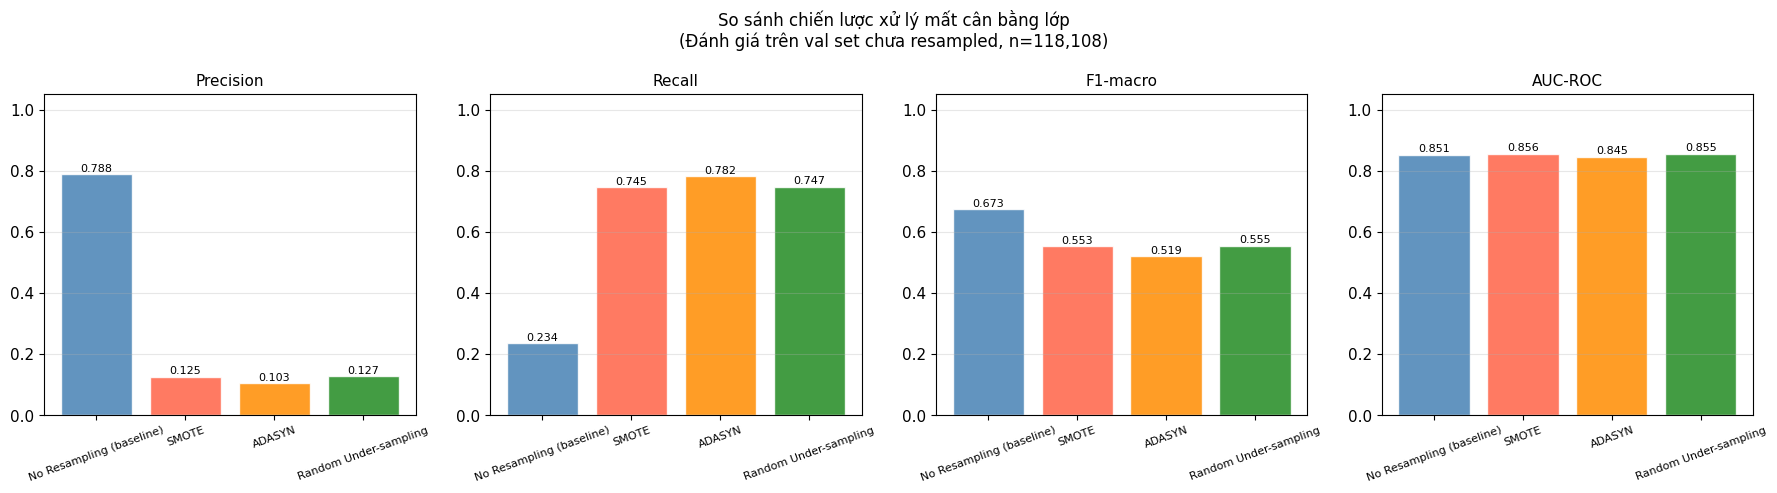

In [42]:
# Biểu đồ so sánh
metrics_plot = ['Precision', 'Recall', 'F1-macro', 'AUC-ROC']
fig, axes = plt.subplots(1, len(metrics_plot), figsize=(18, 5))
colors_rs = ['steelblue', 'tomato', 'darkorange', 'forestgreen']

for ax, metric in zip(axes, metrics_plot):
    vals = [resampling_results[m][metric] for m in resampling_results]
    bars = ax.bar(list(resampling_results.keys()), vals,
                  color=colors_rs[:len(resampling_results)], edgecolor='white', alpha=0.85)
    ax.set_title(metric, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.3f}',
                ha='center', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('So sánh chiến lược xử lý mất cân bằng lớp\n'
             f'(Đánh giá trên val set chưa resampled, n={len(X_val):,})', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_14_imbalance_comparison.png'),
            dpi=100, bbox_inches='tight')
plt.show()

---
## 2.2.3g. Lưu kết quả xử lý (Pipeline Output)

Lưu lại:
- `X_train_processed.npy` / `y_train.npy` — đặc trưng đã xử lý (FINAL_FEATURES)
- `X_test_processed.npy` — tập test xử lý tương ứng
- `feature_names.npy` — tên các đặc trưng đã chọn
- `pipeline_choices.json` — các quyết định của toàn bộ pipeline

In [43]:
PROCESSED_DIR = OUTPUT_DIR  # alias – OUTPUT_DIR defined at top of notebook

# Feature matrix cuối (chỉ FINAL_FEATURES tồn tại trong cả train & test)
# Xử lý trường hợp PCA thắng (FINAL_FEATURES = None)
if FINAL_FEATURES is None:
    raise ValueError("PCA được chọn — không có danh sách feature cụ thể để lưu. "
                     "Cần thêm bước lưu PCA pipeline riêng.")

final_cols = [c for c in FINAL_FEATURES
              if c in train.columns and c in test.columns]
X_train_final = train[final_cols].fillna(0).values.astype(np.float32)
y_train_final = train['isFraud'].values.astype(np.int8)
X_test_final  = test[final_cols].fillna(0).values.astype(np.float32)

np.save(os.path.join(PROCESSED_DIR, 'X_train_processed.npy'), X_train_final)
np.save(os.path.join(PROCESSED_DIR, 'y_train.npy'),           y_train_final)
np.save(os.path.join(PROCESSED_DIR, 'X_test_processed.npy'),  X_test_final)
np.save(os.path.join(PROCESSED_DIR, 'feature_names.npy'),     np.array(final_cols))

# Candidate pool = union 5 phương pháp (tính lại để log)
_candidate_pool = list(set(top30_anova) | set(top30_mi) | set(top30_chi2)
                       | set(top30_rf)  | set(top30_gb))
_candidate_pool = [f for f in _candidate_pool if f in train.columns]

pipeline_choices = {
    'imputation': {
        'benchmark_best':    str(best_strategy),
        'production_choice': 'Mean',
        'reason':            'Scalable O(n·d); AUC không thua kNN/MICE có ý nghĩa thống kê (Wilcoxon ns)'
    },
    'outlier': {
        'ks_best_method':    str(best_ks),
        'production_choice': 'IQR_clipping',
        'reason':            'Bảo toàn số dòng; KS stat thấp nhất trong nhóm có phát hiện; O(n·d) scalable'
    },
    'scaling': {
        'auc_tie_methods':   ['Min-Max', 'Z-score', 'Robust'],
        'production_choice': 'RobustScaler',
        'reason':            'Levene stat thấp nhất (1527); robust với outlier; phù hợp 399/400 cột phi chuẩn'
    },
    'encoding': {
        'low_card':  'Frequency Encoding (cardinality <= 20)',
        'high_card': 'Target Encoding 5-fold CV (cardinality > 20)',
        'dropped':   'OHE (VIF~10^12), Binary (VIF max=123), Ordinal'
    },
    'feature_selection': {
        'strategy':         'Vote >= 3/5 (ANOVA, MI, Chi2, RF, GB) -> benchmark validation',
        'candidate_pool':   len(_candidate_pool),
        'core_vote_feats':  len(core_feats),
        'final_set':        best_final_name,
        'n_features_final': len(final_cols),
        'final_auc':        float(final_df.iloc[0]['AUC mean']),
        'final_f1':         float(final_df.iloc[0]['F1 mean']),
    },
    'imbalance': {
        'imbalance_ratio': round(float(imbalance_ratio), 2),
        'best_method':     str(best_resamp),
        'eval_metric':     'F1-macro on unsampled val set'
    }
}

with open(os.path.join(PROCESSED_DIR, 'pipeline_choices.json'), 'w',
          encoding='utf-8') as f:
    json.dump(pipeline_choices, f, ensure_ascii=False, indent=2)

print(f"Đã lưu dữ liệu xử lý vào: {PROCESSED_DIR}")
print(f"  X_train_processed.npy : shape={X_train_final.shape}, dtype={X_train_final.dtype}")
print(f"  y_train.npy           : shape={y_train_final.shape}, fraud_rate={y_train_final.mean():.4f}")
print(f"  X_test_processed.npy  : shape={X_test_final.shape}")
print(f"  feature_names.npy     : {len(final_cols)} đặc trưng")
print(f"  pipeline_choices.json : {list(pipeline_choices.keys())}")
print(f"\n=== HOÀN THÀNH TOÀN BỘ PIPELINE TIỀN XỬ LÝ TABULAR ===")

Đã lưu dữ liệu xử lý vào: d:\DataMining\DataPreprocessing\Source\data\processed\tabular
  X_train_processed.npy : shape=(590540, 30), dtype=float32
  y_train.npy           : shape=(590540,), fraud_rate=0.0350
  X_test_processed.npy  : shape=(506691, 30)
  feature_names.npy     : 30 đặc trưng
  pipeline_choices.json : ['imputation', 'outlier', 'scaling', 'encoding', 'feature_selection', 'imbalance']

=== HOÀN THÀNH TOÀN BỘ PIPELINE TIỀN XỬ LÝ TABULAR ===
